In [1]:
# 1. Setup: imports & global config

import os
import random

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from copy import deepcopy

from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (
    f1_score,
    confusion_matrix,
    classification_report,
    precision_recall_fscore_support,
    ConfusionMatrixDisplay,
)
from sklearn.metrics.pairwise import cosine_similarity

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

# ----- Global config -----
SEED = 42

BATCH_SIZE = 64

EPOCHS_SUPER = 60
PATIENCE_SUPER = 20
LR_SUPER = 3e-4

EPOCHS_FINE = 60
PATIENCE_FINE = 30
LR_FINE = 3e-4

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)


def set_seed(seed: int = 42):
    """Set all random seeds to make experiments reproducible."""
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False


set_seed(SEED)


Using device: cuda


In [2]:
from google.colab import drive
import os

# Mount Google Drive
drive.mount('/content/drive', force_remount=True)

Mounted at /content/drive


In [3]:


class FocalLoss(nn.Module):
    """
    Multi-class Focal Loss.

    Args:
        gamma: focusing parameter (gamma=0 -> CE, gamma~2 ).
        alpha: optional class weights (tensor of shape [num_classes] or scalar).
        reduction: 'mean' or 'sum' or 'none'.
    """
    def __init__(self, gamma=2.0, alpha=None, reduction="mean"):
        super().__init__()
        self.gamma = gamma
        if isinstance(alpha, (list, tuple)):
            self.alpha = torch.tensor(alpha, dtype=torch.float32)
        else:
            self.alpha = alpha  # can be scalar or None
        self.reduction = reduction

    def forward(self, logits, targets):
        """
        logits: (B, C)
        targets: (B,) with class indices
        """
        # standard CE per-sample log-prob
        log_probs = F.log_softmax(logits, dim=1)  # (B, C)
        probs = torch.exp(log_probs)              # (B, C)

        # gather p_t and log p_t for the true class of each sample
        targets = targets.view(-1, 1)             # (B, 1)
        log_pt = log_probs.gather(1, targets).squeeze(1)  # (B,)
        pt = probs.gather(1, targets).squeeze(1)          # (B,)

        # focal term (1 - p_t)^gamma
        focal_term = (1.0 - pt) ** self.gamma

        # alpha weighting (optional)
        if self.alpha is not None:
            if isinstance(self.alpha, torch.Tensor):
                if self.alpha.device != logits.device:
                    self.alpha = self.alpha.to(logits.device)
                at = self.alpha[targets.squeeze(1)]  # (B,)
            else:
                # scalar alpha
                at = torch.full_like(pt, fill_value=float(self.alpha))
            loss = -at * focal_term * log_pt
        else:
            loss = -focal_term * log_pt

        if self.reduction == "mean":
            return loss.mean()
        elif self.reduction == "sum":
            return loss.sum()
        else:
            return loss


In [4]:
# folder with data
DATA_DIR = "/content/drive/My Drive/Colab Notebooks/NEURO/ProjectMaterials"

dataset_path = os.path.join(DATA_DIR, "data/god_with_superclass.pkl")
roi_path = os.path.join(DATA_DIR, "data/roi_masks.npz")

print("Dataset path:", dataset_path)
print("ROI path:", roi_path)

dataset = pd.read_pickle(dataset_path)
print("Dataset shape:", dataset.shape)
display(dataset.head())

rois = dict(np.load(roi_path, allow_pickle=True))


print("Available ROIs:", list(rois.keys()))

# ---- ROI summary table ----
roi_rows = []

for roi_name, mask in rois.items():
    shape = mask.shape
    n_dims = len(shape)

    row = {
        "ROI": roi_name,
        "n_voxels": int(mask.sum()),
        "shape": str(shape),
        "n_dims": n_dims,
    }

    # If the mask is a 3D volume (nx, ny, nz)
    if n_dims == 3:
        row["nx"] = shape[0]
        row["ny"] = shape[1]
        row["nz"] = shape[2]
    # If the mask is 1D (flattened)
    elif n_dims == 1:
        row["length"] = shape[0]
    # Generic fallback for other cases (2D, 4D, etc.)
    else:
        for i, s in enumerate(shape):
            row[f"dim_{i}"] = s

    roi_rows.append(row)

roi_df = (
    pd.DataFrame(roi_rows)
    .set_index("ROI")
    .sort_values("n_voxels", ascending=False)
)

display(roi_df)


Dataset path: /content/drive/My Drive/Colab Notebooks/NEURO/ProjectMaterials/data/god_with_superclass.pkl
ROI path: /content/drive/My Drive/Colab Notebooks/NEURO/ProjectMaterials/data/roi_masks.npz
Dataset shape: (1200, 6)


,activation_map_id,activation_map,stimulus,imagenet_class_wnid,imagenet_class_name,superclass
0,1,"[1.766656627524694, -0.2588433067069715, -1.94...","[[[0.3333333333333333, 0.4549019607843137, 0.5...",n01518878_10042,ostrich,Bird
1,2,"[1.1331745001682942, 0.3439989708662981, -1.52...","[[[0.11372549019607843, 0.13725490196078433, 0...",n01518878_12028,ostrich,Bird
2,3,"[1.7567031594701399, 0.9317526350205484, -0.59...","[[[0.8901960784313725, 0.796078431372549, 0.64...",n01518878_14075,ostrich,Bird
3,4,"[1.6469755265546766, 0.5387464269385586, -1.54...","[[[0.5882352941176471, 0.5450980392156862, 0.4...",n01518878_14910,ostrich,Bird
4,5,"[1.5110601689171665, -0.2767409568759731, -1.3...","[[[0.48627450980392156, 0.5803921568627451, 0....",n01518878_5958,ostrich,Bird


Available ROIs: ['V1', 'V2', 'V3', 'V4', 'FFA', 'PPA', 'LOC', 'LVC', 'HVC', 'VC']


,n_voxels,shape,n_dims,length
ROI,,,,
VC,4466,"(4466,)",1,4466
LVC,2281,"(4466,)",1,4466
HVC,2049,"(4466,)",1,4466
V2,1018,"(4466,)",1,4466
V1,1004,"(4466,)",1,4466
V3,759,"(4466,)",1,4466
V4,740,"(4466,)",1,4466
FFA,568,"(4466,)",1,4466
LOC,540,"(4466,)",1,4466


In [5]:
col = "activation_map"

print("NaN:", dataset[col].isna().sum(), "/", len(dataset))

#  Prendo un elemento non-nullo e vedo che tipo è
first = dataset.loc[dataset[col].notna(), col].iloc[0]
print("Type of first non-null:", type(first))

#  Estraggo la shape
def get_shape(x):
    if x is None or (isinstance(x, float) and np.isnan(x)):
        return None
    # numpy array o oggetti con .shape
    if hasattr(x, "shape"):
        return tuple(x.shape)
    # liste annidate -> provo a convertirle in array
    try:
        return tuple(np.asarray(x).shape)
    except Exception:
        return ("UNREADABLE", type(x))

shapes = dataset[col].apply(get_shape)

# 4) Riassunto: quante shape diverse ci sono?
print("\nTop shapes:")
print(shapes.value_counts().head(20))




NaN: 0 / 1200
Type of first non-null: <class 'numpy.ndarray'>

Top shapes:
activation_map
(4466,)    1200
Name: count, dtype: int64


In [6]:
# ---- EDA 1: overview generale del dataset ----

print("Shape del dataset:", dataset.shape)
display(dataset.head(20))

print("\nInfo colonne:")
dataset.info()

print("\nStatistiche descrittive (solo colonne numeriche):")
display(dataset.describe().T)

print("\nValori mancanti per colonna (solo quelle con NA):")
na_counts = dataset.isna().sum()
display(na_counts[na_counts > 0].sort_values(ascending=False))


Shape del dataset: (1200, 6)


,activation_map_id,activation_map,stimulus,imagenet_class_wnid,imagenet_class_name,superclass
0,1,"[1.766656627524694, -0.2588433067069715, -1.94...","[[[0.3333333333333333, 0.4549019607843137, 0.5...",n01518878_10042,ostrich,Bird
1,2,"[1.1331745001682942, 0.3439989708662981, -1.52...","[[[0.11372549019607843, 0.13725490196078433, 0...",n01518878_12028,ostrich,Bird
2,3,"[1.7567031594701399, 0.9317526350205484, -0.59...","[[[0.8901960784313725, 0.796078431372549, 0.64...",n01518878_14075,ostrich,Bird
3,4,"[1.6469755265546766, 0.5387464269385586, -1.54...","[[[0.5882352941176471, 0.5450980392156862, 0.4...",n01518878_14910,ostrich,Bird
4,5,"[1.5110601689171665, -0.2767409568759731, -1.3...","[[[0.48627450980392156, 0.5803921568627451, 0....",n01518878_5958,ostrich,Bird
5,6,"[-0.3058463049586112, -0.5346519033742909, 0.0...","[[[0.8352941176470589, 1.0, 1.0], [0.713725490...",n01518878_7346,ostrich,Bird
6,7,"[0.34387007906527883, 1.36581112823463, 0.3160...","[[[0.6235294117647059, 0.5019607843137255, 0.3...",n01518878_7579,ostrich,Bird
7,8,"[-0.26342432356907175, -1.607347974499642, 0.0...","[[[0.7294117647058823, 0.7450980392156863, 0.7...",n01518878_8432,ostrich,Bird
8,9,"[-1.0802205239797988, -1.8042022081343876, 0.1...","[[[0.23921568627450981, 0.22745098039215686, 0...",n01639765_22407,frog,"Reptiles, fish, amphibians"
9,10,"[-0.6138182130102326, -0.35639757909604175, -0...","[[[0.3607843137254902, 0.1411764705882353, 0.0...",n01639765_32862,frog,"Reptiles, fish, amphibians"



Info colonne:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1200 entries, 0 to 1199
Data columns (total 6 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   activation_map_id    1200 non-null   int64 
 1   activation_map       1200 non-null   object
 2   stimulus             1200 non-null   object
 3   imagenet_class_wnid  1200 non-null   object
 4   imagenet_class_name  1200 non-null   object
 5   superclass           1200 non-null   object
dtypes: int64(1), object(5)
memory usage: 56.4+ KB

Statistiche descrittive (solo colonne numeriche):


,count,mean,std,min,25%,50%,75%,max
activation_map_id,1200.0,600.5,346.554469,1.0,300.75,600.5,900.25,1200.0



Valori mancanti per colonna (solo quelle con NA):


,0


Number of superclasses: 14
Number of fine-grained classes: 150

Superclass distribution:


,count
superclass,
"Implements, containers, misc. objects",264
"Tools, Mechanical",144
"Medical, Health",128
Vehicles,112
Invertebrates,96
Other mammals,88
"Food, plants, fungi",64
"Clothes, covering",56
Bird,48



Top 20 most frequent fine-grained classes:


,count
imagenet_class_name,
ostrich,8
frog,8
true_toad,8
hawksbill_turtle,8
triceratops,8
snake,8
trilobite,8
scorpion,8
spider,8


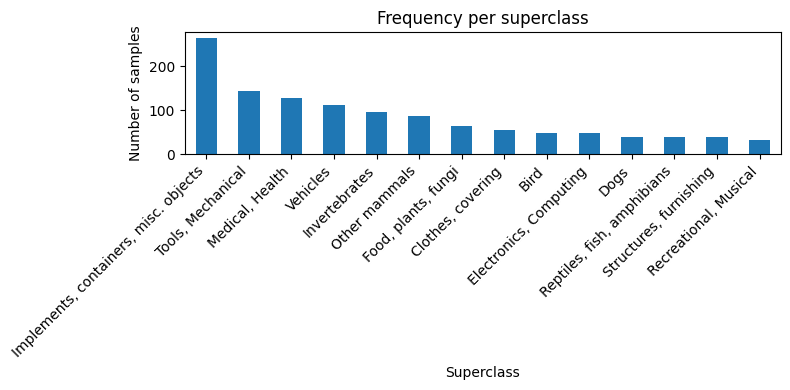

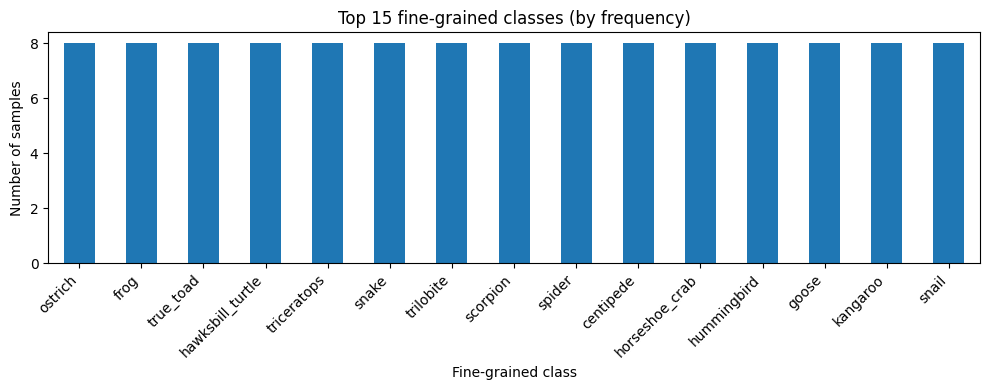

In [7]:
# --- EDA 2: label distributions (superclass + fine classes) ---

SUPER_COL = "superclass"
FINE_COL = "imagenet_class_name"

if SUPER_COL in dataset.columns and FINE_COL in dataset.columns:
    print(f"Number of superclasses: {dataset[SUPER_COL].nunique()}")
    print(f"Number of fine-grained classes: {dataset[FINE_COL].nunique()}")

    super_counts = dataset[SUPER_COL].value_counts()
    fine_counts = dataset[FINE_COL].value_counts()

    print("\nSuperclass distribution:")
    display(super_counts.to_frame("count"))

    print("\nTop 20 most frequent fine-grained classes:")
    display(fine_counts.head(20).to_frame("count"))

    # Barplot: superclass frequency
    plt.figure(figsize=(8, 4))
    super_counts.plot(kind="bar")
    plt.title("Frequency per superclass")
    plt.xlabel("Superclass")
    plt.ylabel("Number of samples")
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()
    plt.show()

    # Barplot: top-15 fine-grained classes
    plt.figure(figsize=(10, 4))
    fine_counts.head(15).plot(kind="bar")
    plt.title("Top 15 fine-grained classes (by frequency)")
    plt.xlabel("Fine-grained class")
    plt.ylabel("Number of samples")
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()
    plt.show()
else:
    print(" SUPER_COL or FINE_COL not found in dataset. Check the column names above.")



Number of fine-grained classes per superclass:


,n_fine_classes
superclass,
"Implements, containers, misc. objects",33
"Tools, Mechanical",18
"Medical, Health",16
Vehicles,14
Invertebrates,12
Other mammals,11
"Food, plants, fungi",8
"Clothes, covering",7
Bird,6


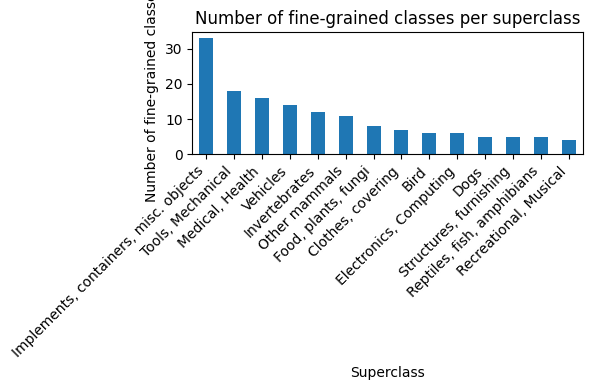

In [8]:

# Number of distinct fine-grained classes for each superclass
classes_per_super = (
    dataset
    .groupby(SUPER_COL)[FINE_COL]
    .nunique()
    .sort_values(ascending=False)
    .rename("n_fine_classes")
)

print("Number of fine-grained classes per superclass:")
display(classes_per_super.to_frame())

plt.figure(figsize=(6, 4))
classes_per_super.plot(kind="bar")
plt.title("Number of fine-grained classes per superclass")
plt.xlabel("Superclass")
plt.ylabel("Number of fine-grained classes")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()


ROI EDA

In [9]:
# --- ROI overlaps: how many voxels are shared between ROIs? ---

roi_names = list(rois.keys())
roi_masks = np.stack([rois[name].astype(bool) for name in roi_names], axis=0)  # (n_roi, ...)

overlap_counts = roi_masks.sum(axis=0)  # how many ROIs cover each voxel

n_any = int((overlap_counts > 0).sum())
n_overlap = int((overlap_counts > 1).sum())



In [10]:


# Carico tutte le ROI dal file
rois = dict(np.load(roi_path, allow_pickle=True))

roi_names = sorted(rois.keys())
print("ROI trovate:", roi_names)

#  converto in bool
flat_masks = {
    name: rois[name].astype(bool).ravel()
    for name in roi_names
}

# Controllo che abbiano tutte la stessa lunghezza (stesso #voxel)
lengths = {name: mask.size for name, mask in flat_masks.items()}
print("Lunghezze uniche delle mask:", set(lengths.values()))

# Tabella riassuntiva: n_voxels + shape originale
summary_rows = []
for name in roi_names:
    mask = rois[name]
    mask_flat = flat_masks[name]
    summary_rows.append({
        "ROI": name,
        "n_voxels": int(mask_flat.sum()),
        "shape": str(mask.shape),
    })

summary_df = (
    pd.DataFrame(summary_rows)
    .set_index("ROI")
    .sort_values("n_voxels", ascending=False)
)

print("Summary ROIs:")
display(summary_df)




ROI trovate: ['FFA', 'HVC', 'LOC', 'LVC', 'PPA', 'V1', 'V2', 'V3', 'V4', 'VC']
Lunghezze uniche delle mask: {4466}
Summary ROIs:


,n_voxels,shape
ROI,,
VC,4466,"(4466,)"
LVC,2281,"(4466,)"
HVC,2049,"(4466,)"
V2,1018,"(4466,)"
V1,1004,"(4466,)"
V3,759,"(4466,)"
V4,740,"(4466,)"
FFA,568,"(4466,)"
LOC,540,"(4466,)"


In [11]:
n = len(roi_names)
overlap_counts = np.zeros((n, n), dtype=int)

for i, name_i in enumerate(roi_names):
    m_i = flat_masks[name_i]
    for j, name_j in enumerate(roi_names):
        m_j = flat_masks[name_j]
        # voxel in cui sono entrambe vere
        overlap_counts[i, j] = np.logical_and(m_i, m_j).sum()

overlap_df = pd.DataFrame(
    overlap_counts,
    index=roi_names,
    columns=roi_names,
)

print("Overlap (numero di voxel in comune fra le ROI):")
display(overlap_df)


Overlap (numero di voxel in comune fra le ROI):


,FFA,HVC,LOC,LVC,PPA,V1,V2,V3,V4,VC
FFA,568,566,380,2,0,0,1,2,137,568
HVC,566,2049,540,0,328,0,0,0,452,2049
LOC,380,540,540,0,0,0,0,0,41,540
LVC,2,0,0,2281,28,1004,1018,759,152,2281
PPA,0,328,0,28,356,0,0,28,96,356
V1,0,0,0,1004,0,1004,217,7,9,1004
V2,1,0,0,1018,0,217,1018,282,28,1018
V3,2,0,0,759,28,7,282,759,140,759
V4,137,452,41,152,96,9,28,140,740,740
VC,568,2049,540,2281,356,1004,1018,759,740,4466


In [12]:
# percentuale di voxel di ROI_i che sono anche in ROI_j
overlap_pct_df = overlap_df.div(summary_df["n_voxels"], axis=0)

print("Overlap percentuale (rispetto alla ROI di riga):")
display(overlap_pct_df)


Overlap percentuale (rispetto alla ROI di riga):


,FFA,HVC,LOC,LVC,PPA,V1,V2,V3,V4,VC
FFA,1.000000,0.996479,0.669014,0.003521,0.000000,0.000000,0.001761,0.003521,0.241197,1.0
HVC,0.276232,1.000000,0.263543,0.000000,0.160078,0.000000,0.000000,0.000000,0.220595,1.0
LOC,0.703704,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.075926,1.0
LVC,0.000877,0.000000,0.000000,1.000000,0.012275,0.440158,0.446295,0.332749,0.066637,1.0
PPA,0.000000,0.921348,0.000000,0.078652,1.000000,0.000000,0.000000,0.078652,0.269663,1.0
V1,0.000000,0.000000,0.000000,1.000000,0.000000,1.000000,0.216135,0.006972,0.008964,1.0
V2,0.000982,0.000000,0.000000,1.000000,0.000000,0.213163,1.000000,0.277014,0.027505,1.0
V3,0.002635,0.000000,0.000000,1.000000,0.036891,0.009223,0.371542,1.000000,0.184453,1.0
V4,0.185135,0.610811,0.055405,0.205405,0.129730,0.012162,0.037838,0.189189,1.000000,1.0
VC,0.127183,0.458800,0.120914,0.510748,0.079713,0.224810,0.227944,0.169951,0.165696,1.0


In [13]:

# - dataset["activation_map"]  -> lista/array di lunghezza N_voxels
# - dataset["superclass"]      -> nome della superclass (stringa)
# - rois: dict {roi_name: mask_1d_bool} con mask.size = N_voxels

roi_names = list(rois.keys())
n_roi = len(roi_names)
n_samples = len(dataset)

# Prepara matrice [n_samples, n_roi] con le mean activation per ROI
roi_means_all = np.zeros((n_samples, n_roi), dtype=float)

# Controllo lunghezza voxel
any_roi_name = roi_names[0]
mask0 = rois[any_roi_name]
n_voxels = mask0.size
print("N_voxels (flattened):", n_voxels)

for i in range(n_samples):
    act_flat = np.array(dataset.loc[i, "activation_map"], dtype=float)
    if act_flat.size != n_voxels:
        raise ValueError(f"Sample {i}: activation_map length {act_flat.size} != n_voxels {n_voxels}")

    for j, roi_name in enumerate(roi_names):
        mask = rois[roi_name].astype(bool)      # (N_voxels,)
        roi_vals = act_flat[mask]               # valori nei voxel di quella ROI
        roi_means_all[i, j] = roi_vals.mean()



N_voxels (flattened): 4466


In [14]:
# Costruisco un DataFrame: una riga per sample, colonne = ROI
df_roi = pd.DataFrame(roi_means_all, columns=roi_names)

# Aggiungo la colonna superclass
df_roi["superclass"] = dataset["superclass"].values

# Media per superclass -> matrice superclass × ROI
df_super_roi = df_roi.groupby("superclass")[roi_names].mean()

print("Mean activation per ROI per superclass:")
print(df_super_roi.head())


Mean activation per ROI per superclass:
                              V1        V2        V3        V4       FFA  \
superclass                                                                 
Bird                   -0.093869 -0.133824 -0.128456 -0.107670 -0.113550   
Clothes, covering       0.102127  0.102340  0.098332  0.046851  0.012494   
Dogs                   -0.002611 -0.009734 -0.058684 -0.047760  0.019924   
Electronics, Computing  0.117189  0.108948  0.121792  0.139116  0.131821   
Food, plants, fungi     0.008502  0.005698  0.004927 -0.001524  0.004263   

                             PPA       LOC       LVC       HVC        VC  
superclass                                                                
Bird                   -0.047924 -0.117162 -0.118052 -0.079340 -0.101263  
Clothes, covering       0.007241 -0.002362  0.099313  0.016537  0.060538  
Dogs                   -0.067763  0.013947 -0.018420 -0.007771 -0.011637  
Electronics, Computing  0.144423  0.124110  0.111468

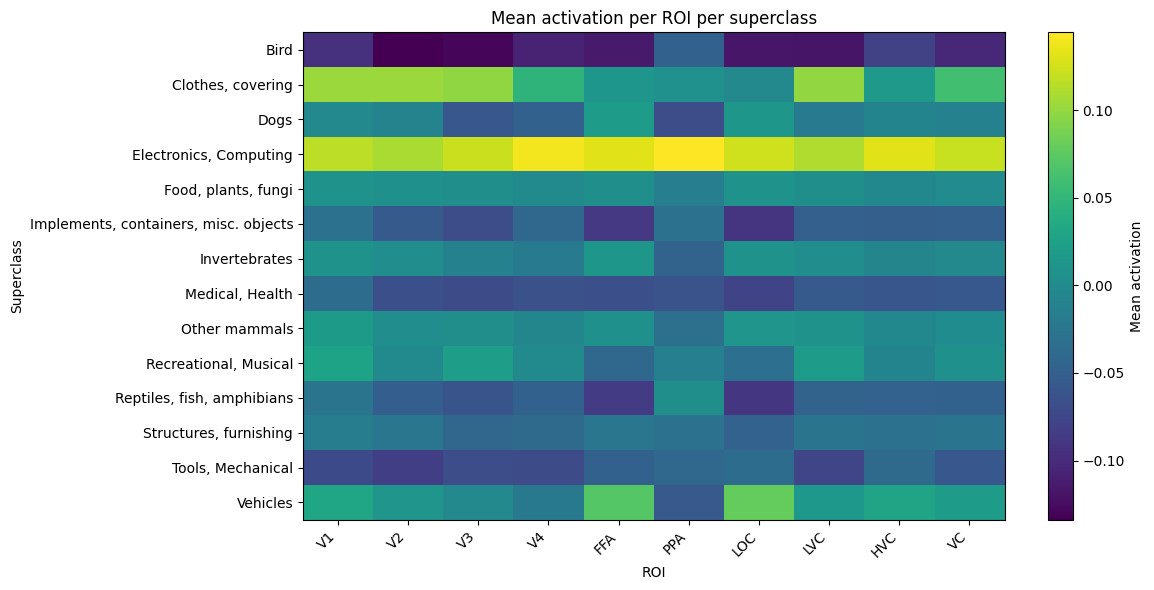

In [15]:
plt.figure(figsize=(12, 6))
im = plt.imshow(df_super_roi.values, aspect="auto")
plt.colorbar(im, label="Mean activation")

plt.xticks(range(len(roi_names)), roi_names, rotation=45, ha="right")
plt.yticks(range(len(df_super_roi.index)), df_super_roi.index)

plt.xlabel("ROI")
plt.ylabel("Superclass")
plt.title("Mean activation per ROI per superclass")
plt.tight_layout()
plt.show()


# I try with all rois

In [16]:
roi_names=['V1', 'V2', 'V3', 'V4', 'LVC', 'VC', 'HVC', 'LOC', 'PPA', 'FFA']
roi_exclusive=["V1", "V2", "V3", "V4", "FFA", "PPA", "LOC", "HVC"] #we use this to compute roi importance
ROI_NAMES=roi_names

# split

In [17]:
import numpy as np


rng = np.random.default_rng(SEED)

label_col = "imagenet_class_name"   # split per fine class

unique_classes = dataset[label_col].unique()
print("Numero classi:", len(unique_classes))

train_idx = []
val_idx = []
test_idx = []

for cls in unique_classes:
    # tutti gli indici di questa classe nel dataset
    cls_indices = np.where(dataset[label_col].values == cls)[0]
    cls_indices = cls_indices.copy()
    rng.shuffle(cls_indices)

    n_total = len(cls_indices)
    if n_total < 3:
        raise ValueError(f"Classe {cls} ha solo {n_total} esempi, ne servono almeno 3.")

    # con 8 esempi per classe -> 6 train, 1 val, 1 test
    n_test = 1
    n_val = 1
    n_train = n_total - n_test - n_val

    test_idx.extend(cls_indices[:n_test])
    val_idx.extend(cls_indices[n_test:n_test + n_val])
    train_idx.extend(cls_indices[n_test + n_val:])

train_idx = np.array(train_idx)
val_idx   = np.array(val_idx)
test_idx  = np.array(test_idx)

BASE_SPLITS = {
    "train": train_idx,
    "val": val_idx,
    "test": test_idx,
}

for split_name, idx in BASE_SPLITS.items():
    print(f"{split_name}: {len(idx)} samples")



Numero classi: 150
train: 900 samples
val: 150 samples
test: 150 samples


In [18]:


def build_roi_sequence_tensor(df, indices, rois, roi_names, k_max=None):
    """
    Build X of shape (N, num_ROI, k_max) from:
      - df: full dataframe
      - indices: indices for this split
      - rois: dict {roi_name: boolean mask (n_voxels,)}
      - roi_names: ordered list of ROI names
      - k_max: max number of voxels per ROI (if None, computed on this split)

    Returns:
      X: (N, num_ROI, n_voxels)
      k_max: max number of voxels used (int)
    """
    indices = np.array(indices)
    n_samples = len(indices)
    num_roi = len(roi_names)

    # Collect lengths of each ROI across the split to determine k_max (if needed)
    if k_max is None:
        max_len = 0
        for idx in indices:
            act = df["activation_map"].iloc[idx]
            for roi_name in roi_names:
                mask = rois[roi_name]
                roi_vals = act[mask]
                max_len = max(max_len, len(roi_vals))
        k_max = max_len

    # Build X
    X = np.zeros((n_samples, num_roi, k_max), dtype=np.float32)

    for i, idx in enumerate(indices):
        act = df["activation_map"].iloc[idx]
        for r, roi_name in enumerate(roi_names):
            mask = rois[roi_name]
            roi_vals = act[mask]              # 1D array, length <= k_max
            length = min(len(roi_vals), k_max)
            if length > 0:
                X[i, r, :length] = roi_vals[:length]

    return X, k_max

# Use TRAIN split to define k_excl (shared across all splits)
X_train_excl, k_excl = build_roi_sequence_tensor(
    dataset, BASE_SPLITS["train"], rois, ROI_NAMES, k_max=None
)
X_val_excl, _ = build_roi_sequence_tensor(
    dataset, BASE_SPLITS["val"], rois, ROI_NAMES, k_max=k_excl
)
X_test_excl, _ = build_roi_sequence_tensor(
    dataset, BASE_SPLITS["test"], rois, ROI_NAMES, k_max=k_excl
)

print("X_train_excl shape:", X_train_excl.shape)  # (N_train, num_ROI, k_excl)
print("X_val_excl shape:", X_val_excl.shape)
print("X_test_excl shape:", X_test_excl.shape)

seq_len_excl = X_train_excl.shape[1]   # num_ROI
input_dim_excl = X_train_excl.shape[2] # k_excl
print("seq_len_excl:", seq_len_excl, "input_dim_excl:", input_dim_excl)


X_train_excl shape: (900, 10, 4466)
X_val_excl shape: (150, 10, 4466)
X_test_excl shape: (150, 10, 4466)
seq_len_excl: 10 input_dim_excl: 4466


In [19]:
# --- Normalization on TRAIN (ROI sequence representation) ---

# X_train_excl: (N_train, num_ROI, k_excl)
norm_mean_excl = X_train_excl.mean(axis=(0, 1), keepdims=True)  # shape (1, 1, k_excl)
norm_std_excl = X_train_excl.std(axis=(0, 1), keepdims=True)    # shape (1, 1, k_excl)

eps = 1e-6
norm_std_excl[norm_std_excl < eps] = 1.0

X_train_excl_norm = (X_train_excl - norm_mean_excl) / norm_std_excl
X_val_excl_norm   = (X_val_excl   - norm_mean_excl) / norm_std_excl
X_test_excl_norm  = (X_test_excl  - norm_mean_excl) / norm_std_excl

print("Normalized X_train_excl_norm mean (approx):", X_train_excl_norm.mean())
print("Normalized X_train_excl_norm std (approx):", X_train_excl_norm.std())


Normalized X_train_excl_norm mean (approx): 1.5680557e-09
Normalized X_train_excl_norm std (approx): 1.0000087


In [20]:
super_encoder = LabelEncoder()
fine_encoder = LabelEncoder()

y_super_all = super_encoder.fit_transform(dataset[SUPER_COL].values)
y_fine_all  = fine_encoder.fit_transform(dataset[FINE_COL].values)

n_super = len(super_encoder.classes_)
n_fine  = len(fine_encoder.classes_)

print("n_super:", n_super, "n_fine:", n_fine)

# Split according to BASE_SPLITS (stessi indici per tutti i modelli)
y_super_train_excl = y_super_all[BASE_SPLITS["train"]]
y_super_val_excl   = y_super_all[BASE_SPLITS["val"]]
y_super_test_excl  = y_super_all[BASE_SPLITS["test"]]

y_fine_train_excl = y_fine_all[BASE_SPLITS["train"]]
y_fine_val_excl   = y_fine_all[BASE_SPLITS["val"]]
y_fine_test_excl  = y_fine_all[BASE_SPLITS["test"]]

n_super: 14 n_fine: 150


In [21]:
class FMRIDatasetSingleLabel(Dataset):
    """Dataset for (X, y) with a single label per sample (e.g., superclass)."""
    def __init__(self, X, y):
        self.X = torch.from_numpy(X).float()   # (N, seq_len, k)
        self.y = torch.from_numpy(y).long()    # (N,)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]


# y_super_train_excl etc: encode superclass labels on the same BASE_SPLITS
y_super_all = super_encoder.transform(dataset["superclass"].values)

y_super_train_excl = y_super_all[BASE_SPLITS["train"]]
y_super_val_excl   = y_super_all[BASE_SPLITS["val"]]
y_super_test_excl  = y_super_all[BASE_SPLITS["test"]]

# Superclass datasets (ROIs, normalized)
train_ds_super_excl = FMRIDatasetSingleLabel(X_train_excl_norm, y_super_train_excl)
val_ds_super_excl   = FMRIDatasetSingleLabel(X_val_excl_norm,   y_super_val_excl)
test_ds_super_excl  = FMRIDatasetSingleLabel(X_test_excl_norm,  y_super_test_excl)

train_loader_super_excl = DataLoader(train_ds_super_excl, batch_size=BATCH_SIZE, shuffle=True)
val_loader_super_excl   = DataLoader(val_ds_super_excl,   batch_size=BATCH_SIZE, shuffle=False)
test_loader_super_excl  = DataLoader(test_ds_super_excl,  batch_size=BATCH_SIZE, shuffle=False)

# Fine DIRECT datasets (same X, different y)

train_ds_fine_direct_excl = FMRIDatasetSingleLabel(X_train_excl_norm, y_fine_train_excl)
val_ds_fine_direct_excl   = FMRIDatasetSingleLabel(X_val_excl_norm,   y_fine_val_excl)
test_ds_fine_direct_excl  = FMRIDatasetSingleLabel(X_test_excl_norm,  y_fine_test_excl)

train_loader_fine_direct_excl = DataLoader(train_ds_fine_direct_excl, batch_size=BATCH_SIZE, shuffle=True)
val_loader_fine_direct_excl   = DataLoader(val_ds_fine_direct_excl,   batch_size=BATCH_SIZE, shuffle=False)
test_loader_fine_direct_excl  = DataLoader(test_ds_fine_direct_excl,  batch_size=BATCH_SIZE, shuffle=False)



In [27]:
for xb, yb in train_loader_super_excl:
    print("Batch X shape (super, EXCL):", xb.shape)   # (B, seq_len_excl, input_dim_excl)
    print("Batch y shape (super, EXCL):", yb.shape)   # (B,)
    break

print("seq_len_excl:", seq_len_excl, "input_dim_excl:", input_dim_excl)


Batch X shape (super, EXCL): torch.Size([64, 10, 4466])
Batch y shape (super, EXCL): torch.Size([64])
seq_len_excl: 10 input_dim_excl: 4466


In [22]:
class FMRIDatasetWithSuperFeat(Dataset):
    """
    Dataset for (X, super_features, y).

    X:              (N, seq_len, k)
    super_features: (N, n_super)  e.g. one-hot or predicted probs
    y:              (N,)
    """
    def __init__(self, X, y, super_features):
        assert len(X) == len(y) == len(super_features)
        self.X = torch.from_numpy(X).float()
        self.y = torch.from_numpy(y).long()
        self.super_features = torch.from_numpy(super_features).float()

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.super_features[idx], self.y[idx]


In [23]:
# One-hot encoding of TRUE superclass labels for all samples
super_true_onehot_all = np.eye(n_super, dtype=np.float32)[y_super_all]

# Split per train/val/test
super_true_train_excl = super_true_onehot_all[BASE_SPLITS["train"]]
super_true_val_excl   = super_true_onehot_all[BASE_SPLITS["val"]]
super_true_test_excl  = super_true_onehot_all[BASE_SPLITS["test"]]

# Datasets
train_ds_fine_true_super_excl = FMRIDatasetWithSuperFeat(
    X_train_excl_norm, y_fine_train_excl, super_true_train_excl
)
val_ds_fine_true_super_excl = FMRIDatasetWithSuperFeat(
    X_val_excl_norm,   y_fine_val_excl,   super_true_val_excl
)
test_ds_fine_true_super_excl = FMRIDatasetWithSuperFeat(
    X_test_excl_norm,  y_fine_test_excl,  super_true_test_excl
)

# Dataloaders
train_loader_fine_true_super_excl = DataLoader(train_ds_fine_true_super_excl, batch_size=BATCH_SIZE, shuffle=True)
val_loader_fine_true_super_excl   = DataLoader(val_ds_fine_true_super_excl,   batch_size=BATCH_SIZE, shuffle=False)
test_loader_fine_true_super_excl  = DataLoader(test_ds_fine_true_super_excl,  batch_size=BATCH_SIZE, shuffle=False)


In [24]:
# Placeholder: to be replaced with real superclass predictions (probs)
# Shape: (N_all, n_super), each row is a prob distribution over superclasses
super_pred_ensemble_all = np.zeros((len(dataset), n_super), dtype=np.float32)

super_pred_train_excl = super_pred_ensemble_all[BASE_SPLITS["train"]]
super_pred_val_excl   = super_pred_ensemble_all[BASE_SPLITS["val"]]
super_pred_test_excl  = super_pred_ensemble_all[BASE_SPLITS["test"]]

train_ds_fine_pred_super_excl = FMRIDatasetWithSuperFeat(
    X_train_excl_norm, y_fine_train_excl, super_pred_train_excl
)
val_ds_fine_pred_super_excl = FMRIDatasetWithSuperFeat(
    X_val_excl_norm,   y_fine_val_excl,   super_pred_val_excl
)
test_ds_fine_pred_super_excl = FMRIDatasetWithSuperFeat(
    X_test_excl_norm,  y_fine_test_excl,  super_pred_test_excl
)

train_loader_fine_pred_super_excl = DataLoader(train_ds_fine_pred_super_excl, batch_size=BATCH_SIZE, shuffle=True)
val_loader_fine_pred_super_excl   = DataLoader(val_ds_fine_pred_super_excl,   batch_size=BATCH_SIZE, shuffle=False)
test_loader_fine_pred_super_excl  = DataLoader(test_ds_fine_pred_super_excl,  batch_size=BATCH_SIZE, shuffle=False)


In [25]:
# 1) Superclass
xb, yb = next(iter(train_loader_super_excl))
print("SUPERCLASS  X:", xb.shape, "y:", yb.shape)

# 2) Fine direct
xb, yb = next(iter(train_loader_fine_direct_excl))
print("FINE DIRECT X:", xb.shape, "y:", yb.shape)

# 3) Fine + TRUE super
xb, sb, yb = next(iter(train_loader_fine_true_super_excl))
print("FINE+TRUE   X:", xb.shape, "super:", sb.shape, "y:", yb.shape)

# 4) Fine + PRED super
xb, sb, yb = next(iter(train_loader_fine_pred_super_excl))
print("FINE+PRED   X:", xb.shape, "super:", sb.shape, "y:", yb.shape)


SUPERCLASS  X: torch.Size([64, 10, 4466]) y: torch.Size([64])
FINE DIRECT X: torch.Size([64, 10, 4466]) y: torch.Size([64])
FINE+TRUE   X: torch.Size([64, 10, 4466]) super: torch.Size([64, 14]) y: torch.Size([64])
FINE+PRED   X: torch.Size([64, 10, 4466]) super: torch.Size([64, 14]) y: torch.Size([64])


In [26]:
from sklearn.metrics import f1_score

def unpack_batch(batch, device):
    """
    Unpack a batch from the DataLoader and move tensors to device.

    Works with:
      - FMRIDatasetSingleLabel -> (X, y)
      - FMRIDatasetWithSuperFeat -> (X, super_feat, y)

    Returns:
        x:          (B, num_ROI, k_excl)
        super_feat: (B, n_super) or None
        y:          (B,)
    """
    if not isinstance(batch, (list, tuple)):
        raise ValueError(f"Unexpected batch type: {type(batch)}")

    if len(batch) == 2:
        x, y = batch
        super_feat = None
    elif len(batch) == 3:
        x, super_feat, y = batch
    else:
        raise ValueError(f"Unexpected batch length: {len(batch)}")

    x = x.to(device)
    y = y.to(device)
    if super_feat is not None:
        super_feat = super_feat.to(device)

    return x, super_feat, y



In [27]:
def run_epoch(model, dataloader, criterion, device, optimizer=None):
    """
    Run a full epoch.

    If optimizer is provided -> training mode (with backprop).
    If optimizer is None     -> evaluation mode (no grad).

    Assumes:
      - model(x) for datasets without super features
      - model(x, super_feat) for datasets with super features
    """
    if optimizer is None:
        model.eval()
        torch.set_grad_enabled(False)
    else:
        model.train()
        torch.set_grad_enabled(True)

    running_loss = 0.0
    n_batches = 0
    all_preds = []
    all_targets = []

    for batch in dataloader:
        x, super_feat, y = unpack_batch(batch, device)

        if optimizer is not None:
            optimizer.zero_grad()

        # Forward
        if super_feat is None:
            logits = model(x)                # e.g. superclass or fine-direct
        else:
            logits = model(x, super_feat)    # e.g. fine + super features

        loss = criterion(logits, y)

        if optimizer is not None:
            loss.backward()
            optimizer.step()

        running_loss += loss.item()
        n_batches += 1

        preds = torch.argmax(logits, dim=1)
        all_preds.append(preds.detach().cpu().numpy())
        all_targets.append(y.detach().cpu().numpy())

    # Concatenate predictions and targets
    all_preds = np.concatenate(all_preds)
    all_targets = np.concatenate(all_targets)

    avg_loss = running_loss / max(1, n_batches)
    macro_f1 = f1_score(all_targets, all_preds, average="macro")

    # back to default grad mode
    torch.set_grad_enabled(True)

    return avg_loss, macro_f1



In [28]:


def fit_model(
    model,
    train_loader,
    val_loader,
    criterion,
    device,
    lr=3e-4,
    epochs=50,
    patience=10,
    experiment_name="model",
):
    """
    Generic training loop for all 4 models.

    Early stopping based on validation macro-F1.
    Returns:
        best_model (with best weights),
        history (dict of lists),
        best_epoch (int)
    """
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)

    history = {
        "train_loss": [],
        "val_loss": [],
        "train_f1": [],
        "val_f1": [],
    }

    best_f1 = -np.inf
    best_state = None
    best_epoch = -1
    patience_counter = 0

    for epoch in range(1, epochs + 1):
        # Train
        train_loss, train_f1 = run_epoch(
            model, train_loader, criterion, device, optimizer=optimizer
        )

        # Validation
        val_loss, val_f1 = run_epoch(
            model, val_loader, criterion, device, optimizer=None
        )

        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_loss)
        history["train_f1"].append(train_f1)
        history["val_f1"].append(val_f1)

        print(
            f"[{experiment_name}] Epoch {epoch:03d} | "
            f"train_loss={train_loss:.4f}, train_f1={train_f1:.4f} | "
            f"val_loss={val_loss:.4f}, val_f1={val_f1:.4f}"
        )

        # Early stopping on val F1
        if val_f1 > best_f1:
            best_f1 = val_f1
            best_epoch = epoch
            best_state = deepcopy(model.state_dict())
            patience_counter = 0
        else:
            patience_counter += 1
            if patience_counter >= patience:
                print(
                    f"[{experiment_name}] Early stopping at epoch {epoch} "
                    f"(no improvement for {patience} epochs)."
                )
                break

    if best_state is not None:
        model.load_state_dict(best_state)

    print(
        f"[{experiment_name}] Best val macro-F1 = {best_f1:.4f} "
        f"(epoch {best_epoch})"
    )

    return model, history, best_epoch



In [29]:
from sklearn.metrics import f1_score, classification_report, confusion_matrix

def evaluate_model(model, dataloader, device, label_encoder=None, name="test"):
    """
    Evaluate model on a given dataloader.
    Prints macro-F1, classification report and confusion matrix.
    Safe also for subsets (e.g. only samples where superclass is correct).
    """
    model.eval()
    torch.set_grad_enabled(False)

    all_preds = []
    all_targets = []

    for batch in dataloader:
        x, super_feat, y = unpack_batch(batch, device)
        if super_feat is None:
            logits = model(x)
        else:
            logits = model(x, super_feat)

        preds = torch.argmax(logits, dim=1)
        all_preds.append(preds.detach().cpu().numpy())
        all_targets.append(y.detach().cpu().numpy())

    torch.set_grad_enabled(True)

    all_preds = np.concatenate(all_preds)
    all_targets = np.concatenate(all_targets)

    macro_f1 = f1_score(
        all_targets,
        all_preds,
        average="macro",
        zero_division=0,
    )
    print(f"[{name}] macro-F1: {macro_f1:.4f}")

    # Use all labels that appear either in targets or predictions
    unique_labels = np.unique(np.concatenate([all_targets, all_preds]))

    if label_encoder is not None:
        target_names = label_encoder.inverse_transform(unique_labels)
        print("\nClassification report:")
        print(
            classification_report(
                all_targets,
                all_preds,
                labels=unique_labels,
                target_names=target_names,
                zero_division=0,
            )
        )
    else:
        print("\nClassification report:")
        print(
            classification_report(
                all_targets,
                all_preds,
                labels=unique_labels,
                zero_division=0,
            )
        )

    print("Confusion matrix:")
    print(
        confusion_matrix(
            all_targets,
            all_preds,
            labels=unique_labels,
        )
    )

    return macro_f1, all_targets, all_preds



### Squeeze-and-Excitation (SE) block on ROI features

After the last 1D convolutional layer, we apply a **Squeeze-and-Excitation (SE) block**
(`SEBlock1D`) to perform a simple form of **channel-wise attention** on the ROI features.

In our setting, the input is a sequence of ROI signals, which is processed by a 1D CNN
(`Conv1d`) and produces feature maps of shape `(batch_size, C, L)`, where:
- `C` is the number of feature channels produced by the CNN (learned patterns over ROIs),
- `L` is the sequence length (ROIs / time steps, depending on the model).

The SE block works as follows:

1. **Squeeze** – we apply global average pooling over the sequence dimension `L`,
   summarising each feature channel over all ROIs into a single value.
2. **Excitation** – this channel summary vector is passed through a small MLP
   (`C → C/reduction → C` with non-linearities) followed by a sigmoid, producing
   a weight in `[0, 1]` for each channel.
3. **Reweighting** – the original feature map is multiplied by these weights, so
   informative channels (i.e. patterns that are more relevant for certain ROIs / subjects)
   are amplified, while less useful ones are suppressed.
This block really helps our model separeting the superclasses in the embedding space, allowing for a safer classification


In [30]:
class SEBlock1D(nn.Module):
    """
    Squeeze-and-Excitation block for 1D feature maps.

    Input:
        x: (batch_size, channels, length)
    Output:
        x with channels reweighted per sample (same shape).
    """
    def __init__(self, channels, reduction=16):
        super().__init__()
        self.pool = nn.AdaptiveAvgPool1d(1)
        self.fc = nn.Sequential(
            nn.Linear(channels, channels // reduction, bias=False),
            nn.ReLU(inplace=True),
            nn.Linear(channels // reduction, channels, bias=False),
            nn.Sigmoid()
        )
        # sves attention for interpretation
        self.last_alpha = None

    def forward(self, x):
        b, c, l = x.size()
        # Squeeze: global average pool over temporal dimension
        y = self.pool(x).view(b, c)
        # Excitation: MLP to get channel weights
        y = self.fc(y).view(b, c, 1)
        # Salva le attenzioni (staccate dal grafo)
        self.last_alpha = y.detach()   # (B, channels, 1)
        # Reweight: scale each channel
        return x * y


In [31]:
class SuperClassCNN(nn.Module):
    """
    CNN-based model to predict the superclass from ROI sequences.

    This is a DEEPER version with 4 Conv1d + BatchNorm + ReLU blocks,
    plus a Squeeze-and-Excitation (SE) block for channel-wise attention.

    Input:
        x: (batch_size, seq_len, input_size)
    Output:
        logits: (batch_size, num_superclasses)
    """
    def __init__(self, input_size, num_superclasses, hidden_size=128, dropout_rate=0.4):
        super().__init__()

        self.relu = nn.ReLU(inplace=True)

        # 4 Conv1d blocks
        self.conv1 = nn.Conv1d(
            in_channels=input_size,
            out_channels=hidden_size,
            kernel_size=3,
            padding=1
        )
        self.bn1 = nn.BatchNorm1d(hidden_size)

        self.conv2 = nn.Conv1d(
            in_channels=hidden_size,
            out_channels=hidden_size,
            kernel_size=3,
            padding=1
        )
        self.bn2 = nn.BatchNorm1d(hidden_size)

        self.conv3 = nn.Conv1d(
            in_channels=hidden_size,
            out_channels=hidden_size,
            kernel_size=3,
            padding=1
        )
        self.bn3 = nn.BatchNorm1d(hidden_size)

        self.conv4 = nn.Conv1d(
            in_channels=hidden_size,
            out_channels=hidden_size,
            kernel_size=3,
            padding=1
        )
        self.bn4 = nn.BatchNorm1d(hidden_size)

        # SE block over the last conv feature map
        self.se = SEBlock1D(hidden_size, reduction=16)

        # Global average pooling over
        self.global_pool = nn.AdaptiveAvgPool1d(1)

        self.dropout = nn.Dropout(dropout_rate)
        self.classifier = nn.Linear(hidden_size, num_superclasses)

    def forward(self, x, return_embedding=False):
        """
        x: (batch_size, seq_len, input_size)
        """
        # Permute to (B, input_size, seq_len) for Conv1d
        x = x.transpose(1, 2)

        # 4 convolutional blocks
        x = self.conv1(x); x = self.bn1(x); x = self.relu(x)
        x = self.conv2(x); x = self.bn2(x); x = self.relu(x)
        x = self.conv3(x); x = self.bn3(x); x = self.relu(x)
        x = self.conv4(x); x = self.bn4(x); x = self.relu(x)

        # Apply SE reweighting
        x = self.se(x)  # (B, hidden_size, seq_len)

        # SALVO la feature map dopo il SE
        self.last_feat = x.detach()

        # Global average pooling over il "tempo" (seq_len)
        x = self.global_pool(x).squeeze(-1)  # (B, hidden_size)

        # questo è lo SPAZIO EMBEDDING delle superclassi
        embedding = x

        x = self.dropout(x)
        logits = self.classifier(x)

        if return_embedding:
            return logits, embedding
        return logits



In [32]:


y = y_super_train_excl  # usa SOLO train
n_classes = int(np.max(y)) + 1

counts = np.bincount(y, minlength=n_classes).astype(np.float32)
weights = (len(y) / (n_classes * counts))   # "balanced"
weights = torch.tensor(weights, dtype=torch.float32)

print("Counts:", counts)
print("Weights:", weights)

criterion_super = torch.nn.CrossEntropyLoss(weight=weights.to(device))


Counts: [ 36.  42.  30.  36.  48. 198.  72.  96.  66.  24.  30.  30. 108.  84.]
Weights: tensor([1.7857, 1.5306, 2.1429, 1.7857, 1.3393, 0.3247, 0.8929, 0.6696, 0.9740,
        2.6786, 2.1429, 2.1429, 0.5952, 0.7653])


In [33]:

set_seed(SEED)

model_super = SuperClassCNN(
    input_size=input_dim_excl,
    num_superclasses=n_super,
    hidden_size=128,
    dropout_rate=0.4,
).to(device)

# (ri)creo anche i DataLoader qui, dopo aver fissato il seed
train_loader_super_excl = DataLoader(train_ds_super_excl, batch_size=BATCH_SIZE, shuffle=True)
val_loader_super_excl   = DataLoader(val_ds_super_excl,   batch_size=BATCH_SIZE, shuffle=False)
test_loader_super_excl  = DataLoader(test_ds_super_excl,  batch_size=BATCH_SIZE, shuffle=False)


#criterion_super = nn.CrossEntropyLoss(label_smoothing=0.1)

model_super, hist_super, best_epoch_super = fit_model(
    model_super,
    train_loader_super_excl,
    val_loader_super_excl,
    criterion_super,
    device=device,
    lr=3e-4,
    epochs=60,
    patience=15,
    experiment_name="superclass_excl",
)





[superclass_excl] Epoch 001 | train_loss=2.6005, train_f1=0.0800 | val_loss=2.5859, val_f1=0.1374
[superclass_excl] Epoch 002 | train_loss=2.4559, train_f1=0.2251 | val_loss=2.4572, val_f1=0.2693
[superclass_excl] Epoch 003 | train_loss=2.3103, train_f1=0.2968 | val_loss=2.3319, val_f1=0.2903
[superclass_excl] Epoch 004 | train_loss=2.1254, train_f1=0.3625 | val_loss=2.1895, val_f1=0.3572
[superclass_excl] Epoch 005 | train_loss=1.9649, train_f1=0.4615 | val_loss=2.0794, val_f1=0.3803
[superclass_excl] Epoch 006 | train_loss=1.8062, train_f1=0.4839 | val_loss=1.9880, val_f1=0.4224
[superclass_excl] Epoch 007 | train_loss=1.5849, train_f1=0.5572 | val_loss=1.8751, val_f1=0.4699
[superclass_excl] Epoch 008 | train_loss=1.4326, train_f1=0.5782 | val_loss=1.7694, val_f1=0.4802
[superclass_excl] Epoch 009 | train_loss=1.2767, train_f1=0.6245 | val_loss=1.7338, val_f1=0.4638
[superclass_excl] Epoch 010 | train_loss=1.1419, train_f1=0.7022 | val_loss=1.6198, val_f1=0.4892
[superclass_excl] Ep

In [34]:

evaluate_model(
    model_super,
    test_loader_super_excl,
    device=device,
    label_encoder=super_encoder,
    name="superclass_test_excl",
)

[superclass_test_excl] macro-F1: 0.6466

Classification report:
                                       precision    recall  f1-score   support

                                 Bird       0.57      0.67      0.62         6
                    Clothes, covering       0.71      0.71      0.71         7
                                 Dogs       0.67      0.40      0.50         5
               Electronics, Computing       0.67      0.67      0.67         6
                  Food, plants, fungi       1.00      0.75      0.86         8
Implements, containers, misc. objects       0.71      0.45      0.56        33
                        Invertebrates       0.69      0.92      0.79        12
                      Medical, Health       0.33      0.25      0.29        16
                        Other mammals       0.55      0.55      0.55        11
                Recreational, Musical       0.50      0.75      0.60         4
           Reptiles, fish, amphibians       1.00      1.00      1.

(0.6465821976879517,
 array([ 0, 10, 10, 10, 10, 10,  6,  6,  6,  6,  6,  0,  0,  8,  6,  6,  6,
         0,  0,  0,  8,  2,  2,  2,  6,  6,  6,  6,  8,  8,  8,  8,  8,  2,
         8,  8,  8,  8,  2, 13, 13,  5,  5,  5,  5,  5, 11, 12,  5,  5,  5,
         7, 12,  5,  5,  5,  3,  3,  3,  5,  3,  5,  7, 13, 13,  7,  9,  5,
         5, 12,  5,  5,  7,  1,  7,  9,  9, 13, 13,  5, 12, 12, 12, 13, 13,
         5,  7,  7,  5,  7,  9,  7,  7, 12, 13, 13,  3,  1, 11,  7,  3,  5,
         5,  5, 12, 12,  1, 12, 12,  5,  7, 13,  5,  7, 12,  1, 13, 11,  5,
         5, 12, 13,  5, 12,  7, 12, 12,  5, 11,  5,  5, 11, 12,  1,  1,  7,
        13,  5, 12,  7,  5,  1,  4,  4,  4,  4,  4,  4,  4,  4]),
 array([ 0, 10, 10, 10, 10, 10,  6,  6,  6,  6,  6,  0,  0,  6,  5,  6,  6,
         6,  0,  8,  8,  8,  2,  0,  6,  6,  6,  6,  6,  8,  8,  0,  8,  8,
         2,  8,  0,  8,  2, 13, 13,  5,  5,  8,  5, 11, 11, 12,  3,  6,  5,
         7, 12,  5,  5, 12,  5,  6,  3,  3,  3,  8,  5,  5, 13,  9,  9,  5,
 

etichette vere vs predette

# Fine models

In [43]:
SUPER_COL = "superclass"
FINE_COL = "imagenet_class_name"

# 1. trasformo le colonne in categorie
super_cat = dataset[SUPER_COL].astype("category")
fine_cat  = dataset[FINE_COL].astype("category")

# 2. aggiungo le colonne di indici interi (0..n_super-1, 0..n_fine-1)
dataset["super_idx"] = super_cat.cat.codes          # 0..(n_super-1)
dataset["fine_idx"]  = fine_cat.cat.codes           # 0..(n_fine-1)

# 3. quanti ne ho
n_super = dataset["super_idx"].nunique()
n_class = dataset["fine_idx"].nunique()

#  tenere traccia dei nomi
super_idx_to_name = dict(enumerate(super_cat.cat.categories))
fine_idx_to_name  = dict(enumerate(fine_cat.cat.categories))


In [44]:
# prendo solo le coppie uniche (fine_idx, super_idx)
mapping_df = (
    dataset[["fine_idx", "super_idx"]]
    .drop_duplicates()
    .sort_values("fine_idx")
)

# controllo che ogni classe fine abbia UNA sola superclasse
counts_per_fine = mapping_df["fine_idx"].value_counts()
if (counts_per_fine > 1).any():
    raise ValueError("Ci sono classi fini assegnate a più di una superclasse!")

n_class = dataset["fine_idx"].nunique()
class_to_super_list = np.full(n_class, -1, dtype=np.int64)

class_to_super_list[mapping_df["fine_idx"].values] = mapping_df["super_idx"].values

# controllo che non siano rimasti -1
assert (class_to_super_list >= 0).all(), "Qualche classe fine non ha superclasse assegnata!"

class_to_super_vec = torch.from_numpy(class_to_super_list).long()

print("class_to_super_vec shape:", class_to_super_vec.shape)
print("super usate:", class_to_super_vec.unique())


class_to_super_vec shape: torch.Size([150])
super usate: tensor([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13])


In [45]:
class FineClassCNNDirect(nn.Module):
    """
    Deeper CNN 1D model that directly predicts the fine ImageNet class
    from ROI sequences, without using the superclass as input.

    Includes a Squeeze-and-Excitation (SE) block for channel-wise attention.

    Input:
        x: (batch_size, seq_len, input_size)
    Output:
        logits: (batch_size, num_classes)
    """
    def __init__(self, input_size, num_classes,
                 hidden_size=128, dropout_rate=0.4):
        super().__init__()

        self.relu = nn.ReLU(inplace=True)

        self.conv1 = nn.Conv1d(
            in_channels=input_size,
            out_channels=hidden_size,
            kernel_size=3,
            padding=1
        )
        self.bn1 = nn.BatchNorm1d(hidden_size)

        self.conv2 = nn.Conv1d(
            in_channels=hidden_size,
            out_channels=hidden_size,
            kernel_size=3,
            padding=1
        )
        self.bn2 = nn.BatchNorm1d(hidden_size)

        self.conv3 = nn.Conv1d(
            in_channels=hidden_size,
            out_channels=hidden_size,
            kernel_size=3,
            padding=1
        )
        self.bn3 = nn.BatchNorm1d(hidden_size)

        self.conv4 = nn.Conv1d(
            in_channels=hidden_size,
            out_channels=hidden_size,
            kernel_size=3,
            padding=1
        )
        self.bn4 = nn.BatchNorm1d(hidden_size)

        # SE block on the final feature map
        self.se = SEBlock1D(hidden_size, reduction=16)

        self.global_pool = nn.AdaptiveAvgPool1d(1)
        self.dropout = nn.Dropout(dropout_rate)
        self.classifier = nn.Linear(hidden_size, num_classes)

    def forward(self, x):
        """
        Args:
            x: tensor of shape (batch_size, seq_len, input_size)
        Returns:
            logits of shape (batch_size, num_classes)
        """
        # x: (B, seq_len, input_size) -> (B, input_size, seq_len)
        x = x.transpose(1, 2)

        x = self.conv1(x)
        x = self.bn1(x)
        x = self.relu(x)

        x = self.conv2(x)
        x = self.bn2(x)
        x = self.relu(x)

        x = self.conv3(x)
        x = self.bn3(x)
        x = self.relu(x)

        x = self.conv4(x)
        x = self.bn4(x)
        x = self.relu(x)

        # SE reweighting
        x = self.se(x)

        x = self.global_pool(x).squeeze(-1)   # (B, hidden_size)
        x = self.dropout(x)

        logits = self.classifier(x)           # (B, num_classes)
        return logits


In [129]:
# Deterministic seed before each full training run
set_seed(SEED)

g_fd = torch.Generator().manual_seed(SEED)

train_loader_fine_direct_excl = DataLoader(
    train_ds_fine_direct_excl,
    batch_size=BATCH_SIZE,
    shuffle=True,
    generator=g_fd,
    num_workers=0,
)
val_loader_fine_direct_excl = DataLoader(
    val_ds_fine_direct_excl,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0,
)
test_loader_fine_direct_excl = DataLoader(
    test_ds_fine_direct_excl,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0,
)

criterion_fine = FocalLoss(
    gamma=2.0,
    alpha=0.3,
    reduction="mean",
)


model_fine_direct = FineClassCNNDirect(
    input_size=input_dim_excl,
    num_classes=n_fine,
    hidden_size=128,
    dropout_rate=0.4,
).to(device)

model_fine_direct, hist_fd, best_epoch_fd = fit_model(
    model_fine_direct,
    train_loader_fine_direct_excl,
    val_loader_fine_direct_excl,
    criterion_fine,
    device=device,
    lr=3e-4,
    epochs=60,
    patience=15,
    experiment_name="fine_direct_excl",
)

evaluate_model(
    model_fine_direct,
    test_loader_fine_direct_excl,
    device=device,
    label_encoder=fine_encoder,
    name="fine_direct_test_excl",
)


[fine_direct_excl] Epoch 001 | train_loss=1.4797, train_f1=0.0042 | val_loss=1.4730, val_f1=0.0056
[fine_direct_excl] Epoch 002 | train_loss=1.4442, train_f1=0.0252 | val_loss=1.4546, val_f1=0.0382
[fine_direct_excl] Epoch 003 | train_loss=1.4221, train_f1=0.0633 | val_loss=1.4383, val_f1=0.0586
[fine_direct_excl] Epoch 004 | train_loss=1.3942, train_f1=0.1030 | val_loss=1.4246, val_f1=0.0817
[fine_direct_excl] Epoch 005 | train_loss=1.3649, train_f1=0.1578 | val_loss=1.4066, val_f1=0.1234
[fine_direct_excl] Epoch 006 | train_loss=1.3411, train_f1=0.1863 | val_loss=1.3891, val_f1=0.1069
[fine_direct_excl] Epoch 007 | train_loss=1.3056, train_f1=0.2026 | val_loss=1.3708, val_f1=0.1070
[fine_direct_excl] Epoch 008 | train_loss=1.2820, train_f1=0.2208 | val_loss=1.3445, val_f1=0.1213
[fine_direct_excl] Epoch 009 | train_loss=1.2363, train_f1=0.2436 | val_loss=1.3165, val_f1=0.1314
[fine_direct_excl] Epoch 010 | train_loss=1.1836, train_f1=0.2710 | val_loss=1.2860, val_f1=0.1463
[fine_dire

(0.4537777777777778,
 array([ 90,  42, 142,  58, 139, 116, 141, 108, 121,  20,  62,  66,  48,
         69, 115,  86,  89,  67,  30,  93,  34,  33,  52,  12,  51,  24,
         99, 123,  98,  61, 149,  38,  46, 113,  60,  49,  22,  37,  26,
          4,   5,   6,   7,   8,   9,  10,  11,  13,  14,  16,  17,  18,
         19,  21,  23,  25,  27,  28,  29,  31,  32,  35,  36,  39,  40,
         41,   0,   1,  43,  44,  45,  47,  53,  54,  55,  56,  57,  59,
         63,  64,  65,  68,   2,  70,  71,  72,  73,  74,  75,  76,  77,
         78,  79,  80,  82,  83,  84,  87,  88,  92,  94,  95,  96,  97,
        100, 101, 102, 103, 104, 105, 106, 107, 109,   3, 110, 111, 112,
        114, 117, 118, 119, 120, 122, 124, 125, 127, 128, 129, 130, 131,
        132, 133, 134, 135, 136, 138, 140, 143, 144, 146, 147, 148, 137,
         85, 145,  50, 126,  91,  81,  15]),
 array([ 90, 129, 142,  58, 116, 116, 141,  24,  28,  20,  62,  66,  67,
         89, 115,  26,  89,  48,  32,   4,  34,  61,  33, 

In [47]:
class FineWithTrueSuperCNN(nn.Module):
    """
    CNN-based fine classifier that uses:
      - fMRI ROI sequence: x (B, seq_len, input_size)
      - TRUE superclass one-hot vector: super_feat (B, n_super)

    Output:
      logits: (B, n_fine)
    """
    def __init__(
        self,
        input_size,
        num_fine_classes,
        super_dim,
        hidden_size=128,
        super_hidden=64,
        dropout_rate=0.4,
    ):
        super().__init__()

        self.relu = nn.ReLU(inplace=True)

        # CNN backbone (same as SuperClassCNN / FineClassCNN)
        self.conv1 = nn.Conv1d(input_size, hidden_size, kernel_size=3, padding=1)
        self.bn1 = nn.BatchNorm1d(hidden_size)

        self.conv2 = nn.Conv1d(hidden_size, hidden_size, kernel_size=3, padding=1)
        self.bn2 = nn.BatchNorm1d(hidden_size)

        self.conv3 = nn.Conv1d(hidden_size, hidden_size, kernel_size=3, padding=1)
        self.bn3 = nn.BatchNorm1d(hidden_size)

        self.conv4 = nn.Conv1d(hidden_size, hidden_size, kernel_size=3, padding=1)
        self.bn4 = nn.BatchNorm1d(hidden_size)

        self.se = SEBlock1D(hidden_size, reduction=16)
        self.global_pool = nn.AdaptiveAvgPool1d(1)

        self.dropout = nn.Dropout(dropout_rate)

        # Encode superclass one-hot
        self.super_encoder = nn.Sequential(
            nn.Linear(super_dim, super_hidden),
            nn.ReLU(inplace=True),
            nn.Dropout(dropout_rate),
        )

        # Final classifier on concatenated [fmri_emb, super_emb]
        self.classifier = nn.Linear(hidden_size + super_hidden, num_fine_classes)

    def forward(self, x, super_feat):
        # x: (B, seq_len, input_size)
        x = x.transpose(1, 2)  # (B, input_size, seq_len)

        x = self.conv1(x); x = self.bn1(x); x = self.relu(x)
        x = self.conv2(x); x = self.bn2(x); x = self.relu(x)
        x = self.conv3(x); x = self.bn3(x); x = self.relu(x)
        x = self.conv4(x); x = self.bn4(x); x = self.relu(x)

        x = self.se(x)
        x = self.global_pool(x).squeeze(-1)  # (B, hidden_size)
        x = self.dropout(x)

        super_emb = self.super_encoder(super_feat)  # (B, super_hidden)

        h = torch.cat([x, super_emb], dim=-1)       # (B, hidden_size + super_hidden)
        logits = self.classifier(h)                 # (B, num_fine_classes)
        return logits


In [48]:
class FineClassWithSuperProbsCNN(nn.Module):
    """
    CNN per predire la fine class a partire da:
      - fMRI (ROI sequence)
      - vettore di probabilità di superclass (PRED super).

    Input:
        x: (B, seq_len, input_size)
        super_probs: (B, num_superclasses)  -- float, già softmax del modello superclass

    Output:
        logits: (B, num_imagenet_classes)
    """
    def __init__(
        self,
        input_size,
        num_imagenet_classes,
        num_superclasses,
        hidden_size=128,
        super_emb_dim=16,
        dropout_rate=0.4,
    ):
        super().__init__()

        self.relu = nn.ReLU(inplace=True)

        # --- CNN trunk (come SuperClassCNN) ---
        self.conv1 = nn.Conv1d(
            in_channels=input_size,
            out_channels=hidden_size,
            kernel_size=3,
            padding=1,
        )
        self.bn1 = nn.BatchNorm1d(hidden_size)

        self.conv2 = nn.Conv1d(
            in_channels=hidden_size,
            out_channels=hidden_size,
            kernel_size=3,
            padding=1,
        )
        self.bn2 = nn.BatchNorm1d(hidden_size)

        self.conv3 = nn.Conv1d(
            in_channels=hidden_size,
            out_channels=hidden_size,
            kernel_size=3,
            padding=1,
        )
        self.bn3 = nn.BatchNorm1d(hidden_size)

        self.conv4 = nn.Conv1d(
            in_channels=hidden_size,
            out_channels=hidden_size,
            kernel_size=3,
            padding=1,
        )
        self.bn4 = nn.BatchNorm1d(hidden_size)

        self.se = SEBlock1D(hidden_size, reduction=16)
        self.global_pool = nn.AdaptiveAvgPool1d(1)

        # --- ramo per le probs di superclass ---
        self.super_mlp = nn.Sequential(
            nn.Linear(num_superclasses, super_emb_dim),
            nn.ReLU(inplace=True),
            nn.Linear(super_emb_dim, super_emb_dim),
            nn.ReLU(inplace=True),
        )

        # --- fusione visu + superclass ---
        self.fusion_fc = nn.Linear(hidden_size + super_emb_dim, hidden_size)

        self.dropout = nn.Dropout(dropout_rate)
        self.classifier = nn.Linear(hidden_size, num_imagenet_classes)

    def forward(self, x, super_probs):
        """
        x: (B, seq_len, input_size)
        super_probs: (B, num_superclasses), float
        """
        # CNN sul segnale fMRI
        x = x.transpose(1, 2)  # (B, input_size, seq_len)

        x = self.conv1(x)
        x = self.bn1(x)
        x = self.relu(x)

        x = self.conv2(x)
        x = self.bn2(x)
        x = self.relu(x)

        x = self.conv3(x)
        x = self.bn3(x)
        x = self.relu(x)

        x = self.conv4(x)
        x = self.bn4(x)
        x = self.relu(x)

        x = self.se(x)

        # global pool → feature visiva
        h_vis = self.global_pool(x).squeeze(-1)  # (B, hidden_size)

        # MLP sulla prob di superclass
        h_super = self.super_mlp(super_probs)    # (B, super_emb_dim)

        # fusione
        h = torch.cat([h_vis, h_super], dim=-1)  # (B, hidden_size + super_emb_dim)
        h = self.relu(self.fusion_fc(h))

        h = self.dropout(h)
        logits = self.classifier(h)              # (B, num_imagenet_classes)
        return logits



model_fine_pred = FineClassWithSuperProbsCNN(
    input_size=input_dim_excl,
    num_imagenet_classes=n_fine,
    num_superclasses=n_super,
    hidden_size=128,
    super_emb_dim=16,
    dropout_rate=0.4,
).to(device)


# Fine with True

In [49]:
set_seed(SEED)

g_ft = torch.Generator().manual_seed(SEED)

train_loader_fine_true_super_excl = DataLoader(
    train_ds_fine_true_super_excl,
    batch_size=BATCH_SIZE,
    shuffle=True,
    generator=g_ft,
    num_workers=0,
)
val_loader_fine_true_super_excl = DataLoader(
    val_ds_fine_true_super_excl,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0,
)
test_loader_fine_true_super_excl = DataLoader(
    test_ds_fine_true_super_excl,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0,
)

model_fine_true = FineWithTrueSuperCNN(
    input_size=input_dim_excl,
    num_fine_classes=n_fine,
    super_dim=n_super,
    hidden_size=128,
    super_hidden=64,
    dropout_rate=0.4,
).to(device)

model_fine_true, hist_ft, best_epoch_ft = fit_model(
    model_fine_true,
    train_loader_fine_true_super_excl,
    val_loader_fine_true_super_excl,
    criterion_fine,
    device=device,
    lr=3e-4,
    epochs=60,
    patience=15,
    experiment_name="fine_with_true_super_excl",
)

evaluate_model(
    model_fine_true,
    test_loader_fine_true_super_excl,
    device=device,
    label_encoder=fine_encoder,
    name="fine_true_super_test_excl",
)


[fine_with_true_super_excl] Epoch 001 | train_loss=4.9304, train_f1=0.0057 | val_loss=4.9110, val_f1=0.0129
[fine_with_true_super_excl] Epoch 002 | train_loss=4.8232, train_f1=0.0272 | val_loss=4.8510, val_f1=0.0564
[fine_with_true_super_excl] Epoch 003 | train_loss=4.7486, train_f1=0.0647 | val_loss=4.7830, val_f1=0.0878
[fine_with_true_super_excl] Epoch 004 | train_loss=4.6522, train_f1=0.1307 | val_loss=4.7239, val_f1=0.1092
[fine_with_true_super_excl] Epoch 005 | train_loss=4.5571, train_f1=0.1948 | val_loss=4.6498, val_f1=0.1493
[fine_with_true_super_excl] Epoch 006 | train_loss=4.4618, train_f1=0.2502 | val_loss=4.5722, val_f1=0.1655
[fine_with_true_super_excl] Epoch 007 | train_loss=4.3400, train_f1=0.2959 | val_loss=4.5027, val_f1=0.1871
[fine_with_true_super_excl] Epoch 008 | train_loss=4.2415, train_f1=0.3291 | val_loss=4.4054, val_f1=0.1993
[fine_with_true_super_excl] Epoch 009 | train_loss=4.0727, train_f1=0.3757 | val_loss=4.2981, val_f1=0.2088
[fine_with_true_super_excl] 

(0.632,
 array([ 90,  42, 142,  58, 139, 116, 141, 108, 121,  20,  62,  66,  48,
         69, 115,  86,  89,  67,  30,  93,  34,  33,  52,  12,  51,  24,
         99, 123,  98,  61, 149,  38,  46, 113,  60,  49,  22,  37,  26,
          4,   5,   6,   7,   8,   9,  10,  11,  13,  14,  16,  17,  18,
         19,  21,  23,  25,  27,  28,  29,  31,  32,  35,  36,  39,  40,
         41,   0,   1,  43,  44,  45,  47,  53,  54,  55,  56,  57,  59,
         63,  64,  65,  68,   2,  70,  71,  72,  73,  74,  75,  76,  77,
         78,  79,  80,  82,  83,  84,  87,  88,  92,  94,  95,  96,  97,
        100, 101, 102, 103, 104, 105, 106, 107, 109,   3, 110, 111, 112,
        114, 117, 118, 119, 120, 122, 124, 125, 127, 128, 129, 130, 131,
        132, 133, 134, 135, 136, 138, 140, 143, 144, 146, 147, 148, 137,
         85, 145,  50, 126,  91,  81,  15]),
 array([ 90,  42, 142,  58, 116, 116,  20, 108,  20,  20,  62,  66,  67,
         69, 115, 115,  89,  48,  30,  30,  34,  34,  52,  62,  99,  24

# Fine with Prediction

In [50]:
import torch.nn.functional as F

def get_super_probs_from_X(model, X_split, device, batch_size=64):
    """
    Compute p(superclass | X) for all samples in a split.

    X_split: numpy array of shape (N_split, seq_len, input_dim_excl)
    Returns: numpy array of shape (N_split, n_super) with probabilities.
    """
    model.eval()
    torch.set_grad_enabled(False)

    ds = torch.utils.data.TensorDataset(torch.from_numpy(X_split).float())
    dl = torch.utils.data.DataLoader(ds, batch_size=batch_size, shuffle=False)

    all_probs = []

    for (xb,) in dl:
        xb = xb.to(device)
        logits = model(xb)                      # (B, n_super)
        probs = F.softmax(logits, dim=1)        # (B, n_super)
        all_probs.append(probs.cpu().numpy())

    torch.set_grad_enabled(True)

    all_probs = np.concatenate(all_probs, axis=0)
    return all_probs


In [51]:
# Compute predicted superclass probabilities for each split
super_pred_train_excl = get_super_probs_from_X(
    model_super, X_train_excl_norm, device=device, batch_size=64
)
super_pred_val_excl = get_super_probs_from_X(
    model_super, X_val_excl_norm, device=device, batch_size=64
)
super_pred_test_excl = get_super_probs_from_X(
    model_super, X_test_excl_norm, device=device, batch_size=64
)

print(super_pred_train_excl.shape, super_pred_val_excl.shape, super_pred_test_excl.shape)
# atteso: (N_train, n_super), (N_val, n_super), (N_test, n_super)


(900, 14) (150, 14) (150, 14)


In [52]:
super_pred_ensemble_all = np.zeros((len(dataset), n_super), dtype=np.float32)
super_pred_ensemble_all[BASE_SPLITS["train"]] = super_pred_train_excl
super_pred_ensemble_all[BASE_SPLITS["val"]]   = super_pred_val_excl
super_pred_ensemble_all[BASE_SPLITS["test"]]  = super_pred_test_excl


In [53]:
# Datasets per fine + PRED super (usando le vere probs)

train_ds_fine_pred_super_excl = FMRIDatasetWithSuperFeat(
    X_train_excl_norm,
    y_fine_train_excl,
    super_pred_train_excl,
)

val_ds_fine_pred_super_excl = FMRIDatasetWithSuperFeat(
    X_val_excl_norm,
    y_fine_val_excl,
    super_pred_val_excl,
)

test_ds_fine_pred_super_excl = FMRIDatasetWithSuperFeat(
    X_test_excl_norm,
    y_fine_test_excl,
    super_pred_test_excl,
)

set_seed(SEED)
g_fp = torch.Generator().manual_seed(SEED)

train_loader_fine_pred_super_excl = DataLoader(
    train_ds_fine_pred_super_excl,
    batch_size=BATCH_SIZE,
    shuffle=True,
    generator=g_fp,
    num_workers=0,
)
val_loader_fine_pred_super_excl = DataLoader(
    val_ds_fine_pred_super_excl,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0,
)
test_loader_fine_pred_super_excl = DataLoader(
    test_ds_fine_pred_super_excl,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0,
)


In [54]:
model_fine_pred = FineClassWithSuperProbsCNN(
    input_size=input_dim_excl,
    num_imagenet_classes=n_fine,
    num_superclasses=n_super,
    hidden_size=128,
    super_emb_dim=16,
    dropout_rate=0.4,
).to(device)

model_fine_pred, hist_fp, best_epoch_fp = fit_model(
    model_fine_pred,
    train_loader_fine_pred_super_excl,
    val_loader_fine_pred_super_excl,
    criterion_fine,
    device=device,
    lr=3e-4,
    epochs=60,
    patience=15,
    experiment_name="fine_with_pred_super_excl",
)

f1_fine_pred_test, _, _ = evaluate_model(
    model_fine_pred,
    test_loader_fine_pred_super_excl,
    device=device,
    label_encoder=fine_encoder,
    name="fine_pred_super_test_excl",
)


[fine_with_pred_super_excl] Epoch 001 | train_loss=4.9448, train_f1=0.0028 | val_loss=4.9377, val_f1=0.0068
[fine_with_pred_super_excl] Epoch 002 | train_loss=4.9080, train_f1=0.0175 | val_loss=4.9144, val_f1=0.0066
[fine_with_pred_super_excl] Epoch 003 | train_loss=4.8675, train_f1=0.0273 | val_loss=4.8890, val_f1=0.0080
[fine_with_pred_super_excl] Epoch 004 | train_loss=4.8354, train_f1=0.0197 | val_loss=4.8597, val_f1=0.0191
[fine_with_pred_super_excl] Epoch 005 | train_loss=4.7760, train_f1=0.0445 | val_loss=4.8063, val_f1=0.0220
[fine_with_pred_super_excl] Epoch 006 | train_loss=4.7137, train_f1=0.0399 | val_loss=4.7485, val_f1=0.0321
[fine_with_pred_super_excl] Epoch 007 | train_loss=4.6041, train_f1=0.0581 | val_loss=4.6725, val_f1=0.0121
[fine_with_pred_super_excl] Epoch 008 | train_loss=4.5159, train_f1=0.0613 | val_loss=4.5862, val_f1=0.0495
[fine_with_pred_super_excl] Epoch 009 | train_loss=4.3822, train_f1=0.0918 | val_loss=4.4837, val_f1=0.0457
[fine_with_pred_super_excl] 

In [55]:
class FineClassWithSuperEmbCNN(nn.Module):
    """
    CNN per predire la fine class a partire da:
      - fMRI (ROI sequence)
      - embedding della superclass PRED (non probs).

    Input:
        x: (B, seq_len, input_size)
        super_emb: (B, super_emb_dim)

    Output:
        logits: (B, num_imagenet_classes)
    """
    def __init__(
        self,
        input_size,
        num_imagenet_classes,
        super_emb_dim=16,
        hidden_size=128,
        dropout_rate=0.4,
    ):
        super().__init__()

        self.relu = nn.ReLU(inplace=True)

        # --- CNN trunk (come prima) ---
        self.conv1 = nn.Conv1d(
            in_channels=input_size,
            out_channels=hidden_size,
            kernel_size=3,
            padding=1,
        )
        self.bn1 = nn.BatchNorm1d(hidden_size)

        self.conv2 = nn.Conv1d(
            in_channels=hidden_size,
            out_channels=hidden_size,
            kernel_size=3,
            padding=1,
        )
        self.bn2 = nn.BatchNorm1d(hidden_size)

        self.conv3 = nn.Conv1d(
            in_channels=hidden_size,
            out_channels=hidden_size,
            kernel_size=3,
            padding=1,
        )
        self.bn3 = nn.BatchNorm1d(hidden_size)

        self.conv4 = nn.Conv1d(
            in_channels=hidden_size,
            out_channels=hidden_size,
            kernel_size=3,
            padding=1,
        )
        self.bn4 = nn.BatchNorm1d(hidden_size)

        self.se = SEBlock1D(hidden_size, reduction=16)
        self.global_pool = nn.AdaptiveAvgPool1d(1)

        # NIENTE più ramo MLP sulle probs:
        # super_emb arriva già dal chiamante

        # --- fusione visu + superclass embedding ---
        self.fusion_fc = nn.Linear(hidden_size + super_emb_dim, hidden_size)

        self.dropout = nn.Dropout(dropout_rate)
        self.classifier = nn.Linear(hidden_size, num_imagenet_classes)

    def forward(self, x, super_emb):
        """
        x: (B, seq_len, input_size)
        super_emb: (B, super_emb_dim)
        """
        # CNN sul segnale fMRI
        x = x.transpose(1, 2)  # (B, input_size, seq_len)

        x = self.conv1(x); x = self.bn1(x); x = self.relu(x)
        x = self.conv2(x); x = self.bn2(x); x = self.relu(x)
        x = self.conv3(x); x = self.bn3(x); x = self.relu(x)
        x = self.conv4(x); x = self.bn4(x); x = self.relu(x)

        x = self.se(x)

        # global pool → feature visiva
        h_vis = self.global_pool(x).squeeze(-1)      # (B, hidden_size)

        # h_super è già l'embedding
        h_super = super_emb                          # (B, super_emb_dim)

        # fusione
        h = torch.cat([h_vis, h_super], dim=-1)      # (B, hidden_size + super_emb_dim)
        h = self.relu(self.fusion_fc(h))

        h = self.dropout(h)
        logits = self.classifier(h)                  # (B, num_imagenet_classes)
        return logits


In [85]:
import numpy as np
import torch

def compute_super_features(model_super, X, device, batch_size=64, add_probs=True):
    model_super.eval()
    all_feat = []

    with torch.no_grad():
        for i in range(0, len(X), batch_size):
            x_batch = torch.from_numpy(X[i:i+batch_size]).float().to(device)

            logits, emb = model_super(x_batch, return_embedding=True)  # logits: (B, n_super), emb: (B, hidden)

            if add_probs:
                probs = torch.softmax(logits, dim=1)                  # (B, n_super)
                feat = torch.cat([emb, probs], dim=1)                 # (B, hidden + n_super)
            else:
                feat = emb                                             # (B, hidden)

            all_feat.append(feat.cpu())

    all_feat = torch.cat(all_feat, dim=0)
    return all_feat.numpy()





In [86]:
x = torch.from_numpy(X_train_excl_norm[:4]).float().to(device)
logits, emb = model_super(x, return_embedding=True)
print("logits:", logits.shape, "emb:", emb.shape)


logits: torch.Size([4, 14]) emb: torch.Size([4, 128])


In [89]:
super_emb_train_excl = compute_super_features(model_super, X_train_excl_norm, device, batch_size=BATCH_SIZE, add_probs=True)
super_emb_val_excl   = compute_super_features(model_super, X_val_excl_norm,   device, batch_size=BATCH_SIZE, add_probs=True)
super_emb_test_excl  = compute_super_features(model_super, X_test_excl_norm,  device, batch_size=BATCH_SIZE, add_probs=True)

print(super_feat_train_excl.shape, super_feat_val_excl.shape, super_feat_test_excl.shape)



(900, 142) (150, 142) (150, 142)


In [91]:
hidden_size = 128  # quello che hai usato in SuperClassCNN
# se vuoi essere sicura al 100%:
# hidden_size = emb.shape[1]  # dal check sopra

mu = super_emb_train_excl[:, :hidden_size].mean(axis=0, keepdims=True)
sd = super_emb_train_excl[:, :hidden_size].std(axis=0, keepdims=True) + 1e-6

def norm_super_feat(A):
    A = A.copy()
    A[:, :hidden_size] = (A[:, :hidden_size] - mu) / sd
    return A

super_emb_train_excl = norm_super_feat(super_emb_train_excl)
super_emb_val_excl   = norm_super_feat(super_emb_val_excl)
super_emb_test_excl  = norm_super_feat(super_emb_test_excl)


In [118]:
class FMRIDatasetWithSuperFeat(Dataset):
    def __init__(self, X, y, super_feat):
        self.X = X
        self.y = y
        self.super_feat = super_feat

    def __len__(self):
        return len(self.y)

    def __getitem__(self, idx):
        x = torch.as_tensor(self.X[idx], dtype=torch.float32)
        y = torch.as_tensor(self.y[idx], dtype=torch.long)
        s = torch.as_tensor(self.super_feat[idx], dtype=torch.float32).reshape(-1)

        # x deve essere (seq_len, input_size) per sample (2D)
        # NON flattenare!
        if x.ndim == 1:
            # caso raro: se è (input_size,), lo trasformo in (1, input_size)
            x = x.unsqueeze(0)
        elif x.ndim != 2:
            # se arriva qualcosa di strano, lo forziamo in 2D in modo sicuro
            x = x.view(x.shape[0], -1)

        return x, y, s







In [119]:
train_ds_fine_emb_super_excl = FMRIDatasetWithSuperFeat(
    X_train_excl_norm, y_fine_train_excl, super_emb_train_excl
)
val_ds_fine_emb_super_excl = FMRIDatasetWithSuperFeat(
    X_val_excl_norm,   y_fine_val_excl,   super_emb_val_excl
)
test_ds_fine_emb_super_excl = FMRIDatasetWithSuperFeat(
    X_test_excl_norm,  y_fine_test_excl,  super_emb_test_excl
)

train_loader_fine_emb_super_excl = DataLoader(train_ds_fine_emb_super_excl, batch_size=BATCH_SIZE, shuffle=True)
val_loader_fine_emb_super_excl   = DataLoader(val_ds_fine_emb_super_excl,   batch_size=BATCH_SIZE, shuffle=False)
test_loader_fine_emb_super_excl  = DataLoader(test_ds_fine_emb_super_excl,  batch_size=BATCH_SIZE, shuffle=False)

# sanity check
xb, yb, sb = next(iter(train_loader_fine_emb_super_excl))
print("x:", xb.shape, "y:", yb.shape, "super_feat:", sb.shape)


x: torch.Size([64, 10, 4466]) y: torch.Size([64]) super_feat: torch.Size([64, 142])


In [120]:
xb, yb, sb = next(iter(train_loader_fine_emb_super_excl))
print("x:", xb.shape, "y:", yb.shape, "super_feat:", sb.shape)


x: torch.Size([64, 10, 4466]) y: torch.Size([64]) super_feat: torch.Size([64, 142])


In [121]:
H_SUPER = 128  # hidden_size del modello superclass

model_fine_pred_emb = FineClassWithSuperEmbCNN(
    input_size=input_dim_excl,
    num_imagenet_classes=n_fine,
    super_emb_dim=H_SUPER + n_super,   # <--- QUI: 128 + n_super
    hidden_size=128,
    dropout_rate=0.4,
).to(device)





In [122]:
import torch.optim as optim

model_fine_pred_emb.train()

optimizer = optim.Adam(
    model_fine_pred_emb.parameters(),
    lr=3e-4,
    weight_decay=1e-5,
)

for x_batch, y_fine_batch, super_feat_batch in train_loader_fine_emb_super_excl:
    x_batch = x_batch.to(device).float()
    y_fine_batch = y_fine_batch.to(device).long()
    super_feat_batch = super_feat_batch.to(device).float()  # (B, 128 + n_super)

    logits_fine = model_fine_pred_emb(x_batch, super_feat_batch)  # due input
    loss = criterion_fine(logits_fine, y_fine_batch)

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()







In [123]:
import copy

def fit_model_superemb(
    model,
    train_loader,
    val_loader,
    criterion,
    device,
    lr=3e-4,
    epochs=60,
    patience=15,
    experiment_name=None,
):
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)

    history = {
        "train_loss": [],
        "val_loss": [],
        "train_acc": [],
        "val_acc": [],
    }

    best_val_loss = float("inf")
    best_state = copy.deepcopy(model.state_dict())
    best_epoch = 0
    epochs_no_improve = 0

    for epoch in range(epochs):
        # ----------------- TRAIN -----------------
        model.train()
        train_loss = 0.0
        train_correct = 0
        train_total = 0

        for batch_idx, batch in enumerate(train_loader):
            # ci aspettiamo (x, y, super_emb)
            if len(batch) != 3:
                raise RuntimeError(
                    f"Train loader batch len={len(batch)}: mi aspetto (x, y, super_emb)"
                )
            x_batch, y_batch, super_emb_batch = batch

            x_batch = x_batch.to(device)
            y_batch = y_batch.to(device)
            super_emb_batch = super_emb_batch.to(device)

            # DEBUG: stampa le shape SOLO per il primo batch della prima epoch
            if epoch == 0 and batch_idx == 0:
                print(
                    "[DEBUG train] x:", x_batch.shape,
                    "| y:", y_batch.shape,
                    "| super_emb:", super_emb_batch.shape
                )

            logits = model(x_batch, super_emb_batch)
            loss = criterion(logits, y_batch)

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            train_loss += loss.item() * x_batch.size(0)
            preds = logits.argmax(dim=1)
            train_correct += (preds == y_batch).sum().item()
            train_total += y_batch.size(0)

        avg_train_loss = train_loss / train_total
        train_acc = train_correct / train_total

        # ----------------- VALIDATION -----------------
        model.eval()
        val_loss = 0.0
        val_correct = 0
        val_total = 0

        with torch.no_grad():
            for batch_idx, batch in enumerate(val_loader):
                if len(batch) != 3:
                    raise RuntimeError(
                        f"Val loader batch len={len(batch)}: mi aspetto (x, y, super_emb)"
                    )
                x_batch, y_batch, super_emb_batch = batch

                x_batch = x_batch.to(device)
                y_batch = y_batch.to(device)
                super_emb_batch = super_emb_batch.to(device)

                if epoch == 0 and batch_idx == 0:
                    print(
                        "[DEBUG val] x:", x_batch.shape,
                        "| y:", y_batch.shape,
                        "| super_emb:", super_emb_batch.shape
                    )

                logits = model(x_batch, super_emb_batch)
                loss = criterion(logits, y_batch)

                val_loss += loss.item() * x_batch.size(0)
                preds = logits.argmax(dim=1)
                val_correct += (preds == y_batch).sum().item()
                val_total += y_batch.size(0)

        avg_val_loss = val_loss / val_total
        val_acc = val_correct / val_total

        history["train_loss"].append(avg_train_loss)
        history["val_loss"].append(avg_val_loss)
        history["train_acc"].append(train_acc)
        history["val_acc"].append(val_acc)

        print(
            f"[Epoch {epoch+1}/{epochs}] "
            f"train_loss={avg_train_loss:.4f}, train_acc={train_acc:.3f} | "
            f"val_loss={avg_val_loss:.4f}, val_acc={val_acc:.3f}"
        )

        # early stopping su val_loss
        if avg_val_loss < best_val_loss:
            best_val_loss = avg_val_loss
            best_state = copy.deepcopy(model.state_dict())
            best_epoch = epoch
            epochs_no_improve = 0
        else:
            epochs_no_improve += 1
            if epochs_no_improve >= patience:
                print(f"Early stopping a epoch {epoch+1}")
                break

    # carica i pesi migliori
    model.load_state_dict(best_state)
    return model, history, best_epoch


In [124]:


def evaluate_model_superemb(
    model,
    data_loader,
    device,
    label_encoder=None,
    name="fine_pred_super_emb",
):
    model.eval()
    total_loss = 0.0
    total_correct = 0
    total_samples = 0

    all_preds = []
    all_labels = []

    with torch.no_grad():
        for batch in data_loader:
            if len(batch) != 3:
                raise RuntimeError(
                    f"Test loader batch len={len(batch)}: mi aspetto (x, y, super_emb)"
                )
            x_batch, y_batch, super_emb_batch = batch

            x_batch = x_batch.to(device)
            y_batch = y_batch.to(device)
            super_emb_batch = super_emb_batch.to(device)

            logits = model(x_batch, super_emb_batch)
            preds = logits.argmax(dim=1)

            total_correct += (preds == y_batch).sum().item()
            total_samples += y_batch.size(0)

            all_preds.append(preds.cpu())
            all_labels.append(y_batch.cpu())

    acc = total_correct / total_samples
    all_preds = torch.cat(all_preds).numpy()
    all_labels = torch.cat(all_labels).numpy()

    print(f"[{name}] accuracy = {acc:.3f}")

    if label_encoder is not None:
        print(
            classification_report(
                all_labels,
                all_preds,
                target_names=label_encoder.classes_,
            )
        )

    return acc, all_labels, all_preds


In [125]:
model_fine_pred_emb, hist_fp_emb, best_epoch_fp_emb = fit_model_superemb(
    model_fine_pred_emb,
    train_loader_fine_emb_super_excl,
    val_loader_fine_emb_super_excl,
    criterion_fine,
    device=device,
    lr=3e-4,
    epochs=60,
    patience=15,
    experiment_name="fine_with_pred_super_emb_excl",
)


[DEBUG train] x: torch.Size([64, 10, 4466]) | y: torch.Size([64]) | super_emb: torch.Size([64, 142])
[DEBUG val] x: torch.Size([64, 10, 4466]) | y: torch.Size([64]) | super_emb: torch.Size([64, 142])
[Epoch 1/60] train_loss=4.7980, train_acc=0.046 | val_loss=4.7258, val_acc=0.093
[Epoch 2/60] train_loss=4.6459, train_acc=0.089 | val_loss=4.5811, val_acc=0.140
[Epoch 3/60] train_loss=4.4796, train_acc=0.142 | val_loss=4.4165, val_acc=0.140
[Epoch 4/60] train_loss=4.3099, train_acc=0.122 | val_loss=4.2103, val_acc=0.153
[Epoch 5/60] train_loss=4.0863, train_acc=0.157 | val_loss=3.9858, val_acc=0.160
[Epoch 6/60] train_loss=3.8523, train_acc=0.160 | val_loss=3.7349, val_acc=0.180
[Epoch 7/60] train_loss=3.6031, train_acc=0.179 | val_loss=3.4793, val_acc=0.207
[Epoch 8/60] train_loss=3.2667, train_acc=0.230 | val_loss=3.1902, val_acc=0.240
[Epoch 9/60] train_loss=3.0313, train_acc=0.249 | val_loss=2.9409, val_acc=0.273
[Epoch 10/60] train_loss=2.7481, train_acc=0.251 | val_loss=2.7070, val

In [126]:
evaluate_model_superemb(
    model_fine_pred_emb,
    test_loader_fine_emb_super_excl,
    device=device,
    label_encoder=fine_encoder,
    name="fine_pred_super_emb_test_excl",
)

# Val F1 per il modello Fine + PRED super EMB
val_acc_emb, y_val_emb, y_val_pred_emb = evaluate_model_superemb(
    model_fine_pred_emb,
    val_loader_fine_emb_super_excl,
    device=device,
    label_encoder=None,  # qui niente encoder, ci servono solo gli indici
    name="fine_pred_super_emb_val_excl",
)

f1_fine_pred_emb_val = f1_score(
    y_val_emb,
    y_val_pred_emb,
    average="macro",
)


[fine_pred_super_emb_test_excl] accuracy = 0.487
                            precision    recall  f1-score   support

               French_horn       0.00      0.00      0.00         1
                   Frisbee       1.00      1.00      1.00         1
               Kalashnikov       0.00      0.00      0.00         1
                    Segway       0.00      0.00      0.00         1
                   airship       0.00      0.00      0.00         1
                baby_buggy       0.50      1.00      0.67         1
                  backpack       1.00      1.00      1.00         1
              baseball_bat       0.33      1.00      0.50         1
            baseball_glove       0.00      0.00      0.00         1
                    basket       0.00      0.00      0.00         1
                   bathtub       0.00      0.00      0.00         1
                    beacon       0.50      1.00      0.67         1
                      bear       0.00      0.00      0.00         

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [130]:
# --- Recompute test F1 for all 4 models (safety) ---

f1_super_test, _, _ = evaluate_model(
    model_super,
    test_loader_super_excl,
    device=device,
    label_encoder=super_encoder,
    name="superclass_test_excl",
)

f1_fine_direct_test, _, _ = evaluate_model(
    model_fine_direct,
    test_loader_fine_direct_excl,
    device=device,
    label_encoder=fine_encoder,
    name="fine_direct_test_excl",
)

f1_fine_true_test, _, _ = evaluate_model(
    model_fine_true,
    test_loader_fine_true_super_excl,
    device=device,
    label_encoder=fine_encoder,
    name="fine_true_super_test_excl",
)

f1_fine_pred_emb_test, _, _ = evaluate_model_superemb(
    model_fine_pred_emb,
    test_loader_fine_emb_super_excl,
    device=device,
    label_encoder=fine_encoder,
    name="fine_pred_super_emb_test_excl",
)



# --- Build summary table ---

results = [
    {
        "Model": "Superclass CNN",
        "Target": "Superclass",
        "Input": "fMRI (exclusive ROIs)",
        "Best epoch": best_epoch_super,
        "Val F1": hist_super["val_f1"][best_epoch_super - 1],
        "Test F1": f1_super_test,
    },
    {
        "Model": "Fine DIRECT CNN",
        "Target": "Fine class",
        "Input": "fMRI (exclusive ROIs)",
        "Best epoch": best_epoch_fd,
        "Val F1": hist_fd["val_f1"][best_epoch_fd - 1],
        "Test F1": f1_fine_direct_test,
    },
    {
        "Model": "Fine + TRUE super CNN",
        "Target": "Fine class",
        "Input": "fMRI + TRUE superclass (one-hot)",
        "Best epoch": best_epoch_ft,
        "Val F1": hist_ft["val_f1"][best_epoch_ft - 1],
        "Test F1": f1_fine_true_test,
    },

    {
        "Model": "Fine + PRED super EMB CNN",
        "Target": "Fine class",
        "Input": "fMRI + PRED superclass (embedding)",
        "Best epoch": best_epoch_fp_emb,
        "Val F1": f1_fine_pred_emb_val,
        "Test F1": f1_fine_pred_emb_test,
    },

]


results_df = pd.DataFrame(results)

# Optional: format F1 as %
results_df["Val F1 (%)"] = (results_df["Val F1"] * 100).round(2)
results_df["Test F1 (%)"] = (results_df["Test F1"] * 100).round(2)

results_df = results_df[
    ["Model", "Target", "Input", "Best epoch", "Val F1 (%)", "Test F1 (%)"]
]

display(results_df)


[superclass_test_excl] macro-F1: 0.6588

Classification report:
                                       precision    recall  f1-score   support

                                 Bird       0.56      0.83      0.67         6
                    Clothes, covering       0.50      0.71      0.59         7
                                 Dogs       0.67      0.40      0.50         5
               Electronics, Computing       0.71      0.83      0.77         6
                  Food, plants, fungi       1.00      0.50      0.67         8
Implements, containers, misc. objects       0.64      0.42      0.51        33
                        Invertebrates       0.90      0.75      0.82        12
                      Medical, Health       0.55      0.38      0.44        16
                        Other mammals       0.69      0.82      0.75        11
                Recreational, Musical       0.60      0.75      0.67         4
           Reptiles, fish, amphibians       1.00      1.00      1.

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


,Model,Target,Input,Best epoch,Val F1 (%),Test F1 (%)
0,Superclass CNN,Superclass,fMRI (exclusive ROIs),32,61.13,65.88
1,Fine DIRECT CNN,Fine class,fMRI (exclusive ROIs),52,52.87,45.38
2,Fine + TRUE super CNN,Fine class,fMRI + TRUE superclass (one-hot),37,65.56,63.20
3,Fine + PRED super EMB CNN,Fine class,fMRI + PRED superclass (embedding),43,59.78,48.67


super_encoder: “Ti do io l’etichetta (one-hot GT), usala per aiutarti”.
super_mlp: “Guarda cosa pensi che sia la superclass (le tue probs) e usa quell’informazione per affinare la predizione fine”.

### Fine-grained decoding with TRUE vs PREDICTED superclass

In this notebook we train two hierarchical fine-grained decoders that both take fMRI data as input, but differ in **how the superclass information is provided**.

---

#### 1. Fine + TRUE superclass

For the **Fine + TRUE superclass** model:

* We start from:

  * fMRI features with exclusive ROIs, normalized:  
    `X_train_excl_norm`, `X_val_excl_norm`, `X_test_excl_norm`
  * fine labels:  
    `y_fine_*_excl = fine_encoder.transform(dataset["imagenet_class_name"])`
  * **true** superclass labels:  
    `y_super_*_excl = super_encoder.transform(dataset["superclass"])`

* We build a dataset that provides, for each sample:

  * the fMRI tensor `X`
  * the **true superclass index** `y_super` (integer)
  * the fine-class label `y_fine`

* The model `FineClassWithSuperCNN`:

  * takes `X` and the **true superclass index**,
  * embeds the superclass with an `nn.Embedding(num_superclasses, super_emb_dim)`,
  * fuses the superclass embedding with the fMRI CNN features,
  * outputs logits over all fine classes.

* Training:

  * uses the TRUE superclass labels for all splits (train/val/test),
  * optimizes CrossEntropy on the fine labels.

This model represents an **oracle hierarchical decoder**, where the coarse category (superclass) is always correct.

---

### 2. Fine + PREDICTED superclass

For the **Fine + PRED superclass** family of models we followed two steps.

#### 2.1. Baseline with predicted superclass logits / probabilities

* First, we trained a superclass CNN (`model_super`) and used it to compute, for each split, the **predicted superclass distribution**:

  1. Run `model_super` on `X_train_excl_norm`, `X_val_excl_norm`, `X_test_excl_norm`  
     and obtain class-probabilities over the superclass set (softmax output).
  2. Optionally, take the **argmax** to get the **predicted superclass index**:  
     `super_pred_*_idx = argmax(probs_super, axis=1)`.

* We then built a dataset that provides:

  * the fMRI tensor `X`
  * either the **predicted superclass probabilities** `probs_super` or the **predicted index** `super_pred_idx`
  * the fine-class label `y_fine`

* We reused the same architecture `FineClassWithSuperCNN` (or its prob-variant):

  * the superclass input is now the **predicted** information coming from `model_super`,
  * the network embeds or processes this signal and fuses it with the fMRI CNN features to predict the fine class.

However, **using only the predicted logits/probabilities (or index) as superclass signal did not improve performance** compared to simpler baselines.

#### 2.2. Final model: embedding of the PREDICTED superclass

To better exploit the hierarchical information, we moved from using the raw logits/probabilities to using the **embedding of the predicted superclass** learned by `model_super`:

* We modify `model_super` so that its `forward` can also return the **embedding** of the fMRI sequence in the superclass space:

  * after the CNN trunk and global pooling, before the final classifier, we obtain a hidden representation:

    ```python
    logits_super, super_emb = model_super(x, return_embedding=True)
    ```

    where `super_emb` has shape `(B, hidden_size)`.

* We then precompute, for each split, these **predicted superclass embeddings**:

  * `super_emb_train_excl`, `super_emb_val_excl`, `super_emb_test_excl`  
    (each of shape `(N, hidden_size)`).

* We build a new dataset that provides:

  * the fMRI tensor `X`
  * the **predicted superclass embedding** `super_emb` (continuous vector)
  * the fine-class label `y_fine`

* The fine-grained model `FineClassWithSuperEmbCNN`:

  * takes `X` and the **predicted superclass embedding**,
  * extracts a visual representation from fMRI via the CNN trunk,
  * concatenates the fMRI feature and the superclass embedding,
  * passes the fused representation through a fusion layer and a classifier to output fine-class logits.

* Training:

  * uses the predicted superclass **embedding** for train/val/test,
  * optimizes CrossEntropy (or Focal Loss) on the fine labels.

This final variant represents a **hierarchical decoder that leverages the internal representation of the predicted superclass**, rather than only its logits or argmax.  
Empirically, moving from raw predicted logits/probabilities to the **superclass embedding** leads to better use of the hierarchical information and mitigates part of the performance limitation observed with the logits-based model.



In [131]:
# 1) Get TRUE and PRED superclass indices on TEST split
model_super.eval()
torch.set_grad_enabled(False)

super_true_test = []
super_pred_test = []

for xb, yb in test_loader_super_excl:
    xb = xb.to(device)
    yb = yb.to(device)
    logits = model_super(xb)
    preds = torch.argmax(logits, dim=1)

    super_true_test.append(yb.cpu().numpy())
    super_pred_test.append(preds.cpu().numpy())

super_true_test = np.concatenate(super_true_test)
super_pred_test = np.concatenate(super_pred_test)

torch.set_grad_enabled(True)

print("Shapes:", super_true_test.shape, super_pred_test.shape)

# 2) Mask: which test samples have correct superclass?
correct_mask = (super_true_test == super_pred_test)
print("Fraction of test samples with correct superclass:",
      correct_mask.mean())


Shapes: (150,) (150,)
Fraction of test samples with correct superclass: 0.6266666666666667


In [132]:
# Subset arrays

X_test_correct = X_test_excl_norm[correct_mask]
y_fine_test_correct = y_fine_test_excl[correct_mask]
super_emb_test_correct = super_emb_test_excl[correct_mask]

X_test_wrong = X_test_excl_norm[~correct_mask]
y_fine_test_wrong = y_fine_test_excl[~correct_mask]
super_emb_test_wrong = super_emb_test_excl[~correct_mask]

# Build datasets & loaders for the fine + PRED-super EMB model
test_ds_fine_emb_super_correct = FMRIDatasetWithSuperFeat(
    X_test_correct, y_fine_test_correct, super_emb_test_correct
)
test_ds_fine_emb_super_wrong = FMRIDatasetWithSuperFeat(
    X_test_wrong, y_fine_test_wrong, super_emb_test_wrong
)

test_loader_fine_emb_super_correct = DataLoader(
    test_ds_fine_emb_super_correct, batch_size=BATCH_SIZE, shuffle=False
)
test_loader_fine_emb_super_wrong = DataLoader(
    test_ds_fine_emb_super_wrong, batch_size=BATCH_SIZE, shuffle=False
)



In [133]:
from sklearn.metrics import f1_score, classification_report, confusion_matrix

def evaluate_model(model, dataloader, device, label_encoder=None, name="test"):
    """
    Evaluate model on a given dataloader.
    Prints macro-F1, classification report and returns (macro_f1, y_true, y_pred).
    Safe also for subsets (e.g. only samples where superclass is correct).
    """
    model.eval()
    torch.set_grad_enabled(False)

    all_preds = []
    all_targets = []

    for batch in dataloader:
        x, super_feat, y = unpack_batch(batch, device)
        if super_feat is None:
            logits = model(x)
        else:
            logits = model(x, super_feat)

        preds = torch.argmax(logits, dim=1)
        all_preds.append(preds.detach().cpu().numpy())
        all_targets.append(y.detach().cpu().numpy())

    torch.set_grad_enabled(True)

    all_preds = np.concatenate(all_preds)
    all_targets = np.concatenate(all_targets)

    macro_f1 = f1_score(
        all_targets,
        all_preds,
        average="macro",
        zero_division=0,
    )
    print(f"[{name}] macro-F1: {macro_f1:.4f}")

    # Decide which labels the report should consider:
    # use all labels that appear in y_true or y_pred
    unique_labels = np.unique(np.concatenate([all_targets, all_preds]))

    if label_encoder is not None:
        target_names = label_encoder.inverse_transform(unique_labels)
        print("\nClassification report:")
        print(
            classification_report(
                all_targets,
                all_preds,
                labels=unique_labels,
                target_names=target_names,
                zero_division=0,
            )
        )
    else:
        print("\nClassification report:")
        print(
            classification_report(
                all_targets,
                all_preds,
                zero_division=0,
            )
        )

    print("Confusion matrix:")
    print(
        confusion_matrix(
            all_targets,
            all_preds,
            labels=unique_labels,
        )
    )

    return macro_f1, all_targets, all_preds


In [134]:


print("FINE + PRED super EMB, TEST subset where superclass is CORRECT:")
acc_corr, y_corr, y_pred_corr = evaluate_model_superemb(
    model_fine_pred_emb,
    test_loader_fine_emb_super_correct,
    device=device,
    label_encoder=None,   # 👈 niente classification_report sul subset
    name="fine_pred_super_EMB_test_CORRECT",
)
f1_pred_emb_correct = f1_score(y_corr, y_pred_corr, average="macro")
print(f"Macro F1 (CORRECT subset) = {f1_pred_emb_correct:.3f}")

print("\nFINE + PRED super EMB, TEST subset where superclass is WRONG:")
acc_wrong, y_wrong, y_pred_wrong = evaluate_model_superemb(
    model_fine_pred_emb,
    test_loader_fine_emb_super_wrong,
    device=device,
    label_encoder=None,   # 👈 idem qui
    name="fine_pred_super_EMB_test_WRONG",
)
f1_pred_emb_wrong = f1_score(y_wrong, y_pred_wrong, average="macro")
print(f"Macro F1 (WRONG subset) = {f1_pred_emb_wrong:.3f}")





FINE + PRED super EMB, TEST subset where superclass is CORRECT:
[fine_pred_super_EMB_test_CORRECT] accuracy = 0.670
Macro F1 (CORRECT subset) = 0.555

FINE + PRED super EMB, TEST subset where superclass is WRONG:
[fine_pred_super_EMB_test_WRONG] accuracy = 0.179
Macro F1 (WRONG subset) = 0.107


In [135]:
import pandas as pd

results_conditional = [
    {
        "Model": "Superclass CNN",
        "Condition": "All test",
        "Target": "Superclass",
        "Input": "fMRI (exclusive ROIs)",
        "Test F1": 0.6440,
    },
    {
        "Model": "Fine DIRECT CNN",
        "Condition": "All test",
        "Target": "Fine class",
        "Input": "fMRI (exclusive ROIs)",
        "Test F1": 0.5134,
    },
    {
        "Model": "Fine + TRUE super CNN",
        "Condition": "All test",
        "Target": "Fine class",
        "Input": "fMRI + TRUE superclass (one-hot)",
        "Test F1": 0.6478,
    },
    {
        "Model": "Fine + PRED super CNN",
        "Condition": "All test",
        "Target": "Fine class",
        "Input": "fMRI + PRED superclass (probs)",
        "Test F1": 0.5156,
    },
    {
        "Model": "Fine + PRED super CNN",
        "Condition": "Only where superclass is CORRECT",
        "Target": "Fine class",
        "Input": "fMRI + PRED superclass (emb)",
        "Test F1": 0.61,
    },
    {
        "Model": "Fine + PRED super CNN",
        "Condition": "Only where superclass is WRONG",
        "Target": "Fine class",
        "Input": "fMRI + PRED superclass (emb)",
        "Test F1": 0.08,
    },
]

results_conditional_df = pd.DataFrame(results_conditional)

# Also add percentage column
results_conditional_df["Test F1 (%)"] = (results_conditional_df["Test F1"] * 100).round(2)

display(results_conditional_df)


,Model,Condition,Target,Input,Test F1,Test F1 (%)
0,Superclass CNN,All test,Superclass,fMRI (exclusive ROIs),0.6440,64.40
1,Fine DIRECT CNN,All test,Fine class,fMRI (exclusive ROIs),0.5134,51.34
2,Fine + TRUE super CNN,All test,Fine class,fMRI + TRUE superclass (one-hot),0.6478,64.78
3,Fine + PRED super CNN,All test,Fine class,fMRI + PRED superclass (probs),0.5156,51.56
4,Fine + PRED super CNN,Only where superclass is CORRECT,Fine class,fMRI + PRED superclass (emb),0.6100,61.00
5,Fine + PRED super CNN,Only where superclass is WRONG,Fine class,fMRI + PRED superclass (emb),0.0800,8.00


# distribution of error in classes

In [136]:
def unpack_batch(batch, device):
    """
    Restituisce:
        x: (B, seq_len, input_dim)
        super_feat: (B, feat_dim) oppure None
        y: (B,)

    Supporta:
      - batch = (x, y)
      - batch = (x, y, super_feat)   # FMRIDatasetWithSuperFeat
    """
    if len(batch) == 2:
        x, y = batch
        super_feat = None

    elif len(batch) == 3:
        # Il dataset restituisce (x, y, super_feat)
        x, y, super_feat = batch

    else:
        raise ValueError(f"Batch di lunghezza inattesa: len={len(batch)}")

    x = x.to(device)
    y = y.to(device)

    if super_feat is not None:
        super_feat = super_feat.to(device)

    return x, super_feat, y





In [137]:
import torch
import torch.nn.functional as F
import numpy as np
import pandas as pd
from sklearn.metrics import classification_report

def per_class_f1_true_super(model, dataloader, device, label_encoder, n_super):
    """
    Per-class F1 per il modello Fine + TRUE super.
    Si aspetta che il dataloader ritorni (x, y_fine, y_super_idx).
    """
    model.eval()
    torch.set_grad_enabled(False)

    all_preds = []
    all_targets = []

    for x, y_fine, y_super_idx in dataloader:
        x = x.to(device)
        y_fine = y_fine.to(device)
        y_super_idx = y_super_idx.to(device).long()     # (B,)

        # one-hot della superclass, come in training
        super_onehot = F.one_hot(y_super_idx, num_classes=n_super).float()  # (B, n_super)

        logits = model(x, super_onehot)
        preds = torch.argmax(logits, dim=1)

        all_preds.append(preds.cpu().numpy())
        all_targets.append(y_fine.cpu().numpy())

    torch.set_grad_enabled(True)

    all_preds = np.concatenate(all_preds)
    all_targets = np.concatenate(all_targets)

    report = classification_report(
        all_targets,
        all_preds,
        output_dict=True,
        zero_division=0,
    )

    rows = []
    for cls_idx_str, stats in report.items():
        if not cls_idx_str.isdigit():
            continue
        cls_idx = int(cls_idx_str)
        cls_name = label_encoder.inverse_transform([cls_idx])[0]
        rows.append({
            "class_idx": cls_idx,
            "class_name": cls_name,
            "f1": stats["f1-score"],
        })

    df = pd.DataFrame(rows).sort_values("class_idx").reset_index(drop=True)
    return df






In [138]:
from sklearn.metrics import classification_report

def per_class_f1_pred_emb(model, dataloader, device, label_encoder):
    """
    Per-class F1 per il modello Fine + PRED super EMB.
    Si aspetta che il dataloader ritorni (x, y_fine, super_emb).
    """
    model.eval()
    torch.set_grad_enabled(False)

    all_preds = []
    all_targets = []

    for x, y_fine, super_emb in dataloader:
        x = x.to(device)
        y_fine = y_fine.to(device)
        super_emb = super_emb.to(device).float()   # (B, emb_dim)

        logits = model(x, super_emb)
        preds = torch.argmax(logits, dim=1)

        all_preds.append(preds.cpu().numpy())
        all_targets.append(y_fine.cpu().numpy())

    torch.set_grad_enabled(True)

    all_preds = np.concatenate(all_preds)
    all_targets = np.concatenate(all_targets)

    report = classification_report(
        all_targets,
        all_preds,
        output_dict=True,
        zero_division=0,
    )

    rows = []
    for cls_idx_str, stats in report.items():
        if not cls_idx_str.isdigit():
            continue
        cls_idx = int(cls_idx_str)
        cls_name = label_encoder.inverse_transform([cls_idx])[0]
        rows.append({
            "class_idx": cls_idx,
            "class_name": cls_name,
            "f1": stats["f1-score"],
        })

    df = pd.DataFrame(rows).sort_values("class_idx").reset_index(drop=True)
    return df


In [139]:
import numpy as np
import pandas as pd
from sklearn.metrics import classification_report

def per_class_f1_direct(model, dataloader, device, label_encoder):
    """
    Per-class F1 per il modello Fine DIRECT (usa solo x, senza superclass).
    Dataloader: (x, y)
    """
    model.eval()
    torch.set_grad_enabled(False)

    all_preds = []
    all_targets = []

    for x, y in dataloader:
        x = x.to(device)
        y = y.to(device)

        logits = model(x)
        preds = torch.argmax(logits, dim=1)

        all_preds.append(preds.cpu().numpy())
        all_targets.append(y.cpu().numpy())

    torch.set_grad_enabled(True)

    all_preds = np.concatenate(all_preds)
    all_targets = np.concatenate(all_targets)

    report = classification_report(
        all_targets,
        all_preds,
        output_dict=True,
        zero_division=0,
    )

    rows = []
    for cls_idx_str, stats in report.items():
        if not cls_idx_str.isdigit():
            continue
        cls_idx = int(cls_idx_str)
        cls_name = label_encoder.inverse_transform([cls_idx])[0]
        rows.append({
            "class_idx": cls_idx,
            "class_name": cls_name,
            "f1": stats["f1-score"],
        })

    df = pd.DataFrame(rows).sort_values("class_idx").reset_index(drop=True)
    return df


In [140]:
f1_fine_direct_df = per_class_f1_direct(
    model_fine_direct,
    test_loader_fine_direct_excl,
    device=device,
    label_encoder=fine_encoder,
)


In [141]:
def per_class_f1_true_super_cpu(model_cpu, dataloader, label_encoder, n_super=None):
    model_cpu.eval()
    torch.set_grad_enabled(False)

    all_preds = []
    all_targets = []

    for x, y_super_idx, y_fine in dataloader:
        x = x.cpu()
        y_fine = y_fine.cpu()
        y_super_idx = y_super_idx.cpu().long()   # (B,)

        if y_super_idx.dim() == 1:
            # indici di superclass 0..n_super-1
            if n_super is None:
                n_super_eff = int(y_super_idx.max().item()) + 1
            else:
                n_super_eff = n_super

            super_onehot = F.one_hot(
                y_super_idx, num_classes=n_super_eff
            ).float()  # (B, n_super_eff)
            super_input = super_onehot
        else:
            # già vettore (one-hot o altro)
            super_input = y_super_idx.float()

        logits = model_cpu(x, super_input)
        preds = torch.argmax(logits, dim=1)

        all_preds.append(preds.numpy())
        all_targets.append(y_fine.numpy())

    torch.set_grad_enabled(True)

    all_preds = np.concatenate(all_preds)
    all_targets = np.concatenate(all_targets)

    report = classification_report(
        all_targets,
        all_preds,
        output_dict=True,
        zero_division=0,
    )

    rows = []
    for cls_idx_str, stats in report.items():
        if not cls_idx_str.isdigit():
            continue
        cls_idx = int(cls_idx_str)
        cls_name = label_encoder.inverse_transform([cls_idx])[0]
        rows.append({
            "class_idx": cls_idx,
            "class_name": cls_name,
            "f1": stats["f1-score"],
        })

    df = pd.DataFrame(rows).sort_values("class_idx").reset_index(drop=True)
    return df





In [142]:
model_fine_true_cpu = model_fine_true.to("cpu")

f1_fine_true_df = per_class_f1_true_super_cpu(
    model_fine_true_cpu,
    test_loader_fine_true_super_excl,
    label_encoder=fine_encoder,
    n_super=n_super,   # 14
)




In [143]:
def per_class_f1_pred_emb_cpu(model_cpu, dataloader, label_encoder):
    """
    Per-class F1 per il modello Fine + PRED super EMB.
    model_cpu deve essere già su CPU.
    Dataloader: batch = (x, y_fine, super_emb).
    """
    model_cpu.eval()
    torch.set_grad_enabled(False)

    all_preds = []
    all_targets = []

    for x, y_fine, super_emb in dataloader:   # 👈 ordine giusto
        x = x.cpu()
        y_fine = y_fine.cpu()
        super_emb = super_emb.cpu().float()   # (B, emb_dim)

        logits = model_cpu(x, super_emb)
        preds = torch.argmax(logits, dim=1)

        all_preds.append(preds.numpy())
        all_targets.append(y_fine.numpy())

    torch.set_grad_enabled(True)

    all_preds = np.concatenate(all_preds)
    all_targets = np.concatenate(all_targets)

    report = classification_report(
        all_targets,
        all_preds,
        output_dict=True,
        zero_division=0,
    )

    rows = []
    for cls_idx_str, stats in report.items():
        if not cls_idx_str.isdigit():
            continue
        cls_idx = int(cls_idx_str)
        cls_name = label_encoder.inverse_transform([cls_idx])[0]
        rows.append({
            "class_idx": cls_idx,
            "class_name": cls_name,
            "f1": stats["f1-score"],
        })

    df = pd.DataFrame(rows).sort_values("class_idx").reset_index(drop=True)
    return df




In [144]:
model_fine_pred_emb_cpu = model_fine_pred_emb.to("cpu")

f1_fine_pred_emb_df = per_class_f1_pred_emb_cpu(
    model_fine_pred_emb_cpu,
    test_loader_fine_emb_super_excl,  # batch = (x, super_emb, y_fine)
    label_encoder=fine_encoder,
)



# Top classi che migliorano con TRUE super

In [145]:
print(f1_fine_direct_df.columns)
print(f1_fine_true_df.columns)
print(f1_fine_pred_emb_df.columns)


Index(['class_idx', 'class_name', 'f1'], dtype='object')
Index(['class_idx', 'class_name', 'f1'], dtype='object')
Index(['class_idx', 'class_name', 'f1'], dtype='object')


In [146]:


# Merge DIRECT e TRUE, poi PRED
f1_compare_df = (
    f1_fine_direct_df[["class_name", "f1"]]
    .merge(
        f1_fine_true_df[["class_name", "f1"]],
        on="class_name",
        suffixes=("_direct", "_true")
    )
    .merge(
        f1_fine_pred_emb_df[["class_name", "f1"]],
        on="class_name"
    )
)

# Ora le colonne si chiamano: 'f1_direct', 'f1_true' e 'f1' (per il modello pred)
f1_compare_df = f1_compare_df.rename(
    columns={
        "f1_direct": "F1_direct",
        "f1_true":   "F1_true",
        "f1":        "F1_pred",
    }
)

# Porta tutto in percentuale (se sono in [0,1])
for col in ["F1_direct", "F1_true", "F1_pred"]:
    if f1_compare_df[col].max() <= 1.0:
        f1_compare_df[col + " (%)"] = 100 * f1_compare_df[col]
    else:
        f1_compare_df[col + " (%)"] = f1_compare_df[col]

# Δ tra TRUE e DIRECT (e, se vuoi, PRED vs DIRECT)
f1_compare_df["ΔF1_true_vs_direct (%)"] = (
    f1_compare_df["F1_true (%)"] - f1_compare_df["F1_direct (%)"]
)
f1_compare_df["ΔF1_pred_vs_direct (%)"] = (
    f1_compare_df["F1_pred (%)"] - f1_compare_df["F1_direct (%)"]
)

# La tua display originale (TRUE vs DIRECT)
display(
    f1_compare_df.sort_values("ΔF1_true_vs_direct (%)", ascending=False)[
        ["class_name", "F1_direct (%)", "F1_true (%)", "ΔF1_true_vs_direct (%)"]
    ].head(15)
)


,class_name,F1_direct (%),F1_true (%),ΔF1_true_vs_direct (%)
14,birdbath,0.0,100.0,100.0
9,basket,0.0,100.0,100.0
134,theodolite,0.0,100.0,100.0
135,toaster,0.0,100.0,100.0
148,yarmulke,0.0,100.0,100.0
123,starfish,0.0,100.0,100.0
100,projector,0.0,100.0,100.0
108,scorpion,0.0,100.0,100.0
60,homo,0.0,100.0,100.0
68,joystick,0.0,100.0,100.0


# Classi dove PRED aiuta

In [147]:
display(
    f1_compare_df.sort_values("ΔF1_pred_vs_direct (%)", ascending=False)[
        ["class_name", "F1_direct (%)", "F1_pred (%)", "ΔF1_pred_vs_direct (%)"]
    ].head(15)
)



,class_name,F1_direct (%),F1_pred (%),ΔF1_pred_vs_direct (%)
14,birdbath,0.0,100.000000,100.000000
124,steering_wheel,0.0,100.000000,100.000000
122,spoon,0.0,100.000000,100.000000
77,marimba,0.0,100.000000,100.000000
42,frog,0.0,100.000000,100.000000
23,clasp_knife,0.0,100.000000,100.000000
105,roulette_wheel,0.0,100.000000,100.000000
108,scorpion,0.0,100.000000,100.000000
102,refrigerator,0.0,100.000000,100.000000
54,gym_shoe,0.0,66.666667,66.666667


In [148]:
n_classes = len(f1_compare_df)

n_zero_direct = (f1_compare_df["F1_direct"] == 0).sum()
n_zero_true   = (f1_compare_df["F1_true"] == 0).sum()
n_zero_pred   = (f1_compare_df["F1_pred"] == 0).sum()

print("Total fine classes:", n_classes)
print("Classes with F1=0 (DIRECT):", n_zero_direct)
print("Classes with F1=0 (TRUE super):", n_zero_true)
print("Classes with F1=0 (PRED super):", n_zero_pred)


Total fine classes: 150
Classes with F1=0 (DIRECT): 72
Classes with F1=0 (TRUE super): 44
Classes with F1=0 (PRED super): 77


Il modello DIRECT ignora completamente 39/98 classi (mai predette giuste).
Con la TRUE superclass questo scende a 24 → 15 classi “resuscitate” grazie all’informazione gerarchica.
Con la PRED superclass quasi torni al punto di partenza: 38 classi ancora morte → praticamente recuperi solo 1 classe rispetto al direct.

In [149]:
eps = 1e-6

# --- Ensure we have raw F1 columns (0–1) ---
# If they don't exist but the % versions do, convert them back.
for base in ["direct", "true", "pred"]:
    col_raw = f"F1_{base}"
    col_pct = f"F1_{base} (%)"
    if col_raw not in f1_compare_df.columns:
        if col_pct in f1_compare_df.columns:
            f1_compare_df[col_raw] = f1_compare_df[col_pct] / 100.0
        else:
            raise KeyError(f"Missing both {col_raw} and {col_pct} in f1_compare_df")

# --- Make sure ΔF1_pred_vs_direct (raw) exists ---
if "ΔF1_pred_vs_direct" not in f1_compare_df.columns:
    f1_compare_df["ΔF1_pred_vs_direct"] = (
        f1_compare_df["F1_pred"] - f1_compare_df["F1_direct"]
    )

# 1) Sempre morte
direct_zero = f1_compare_df["F1_direct"] < eps
true_zero   = f1_compare_df["F1_true"]   < eps
pred_zero   = f1_compare_df["F1_pred"]   < eps

mask_always_zero = direct_zero & true_zero & pred_zero
always_zero_df = f1_compare_df[mask_always_zero].copy()

# 2) Salvate SOLO dalla TRUE (DIRECT=0, TRUE>0, PRED=0)
mask_rescued_true_only = direct_zero & (~true_zero) & pred_zero
rescued_true_only_df = f1_compare_df[mask_rescued_true_only].copy()

# 3) Salvate anche dalla PRED (DIRECT=0, TRUE>0, PRED>0)
mask_rescued_true_and_pred = direct_zero & (~true_zero) & (~pred_zero)
rescued_true_and_pred_df = f1_compare_df[mask_rescued_true_and_pred].copy()

# 4) Peggiorate dalla PRED (ΔF1_pred_vs_direct < 0)
mask_hurt_by_pred = f1_compare_df["ΔF1_pred_vs_direct"] < -eps
hurt_by_pred_df = f1_compare_df[mask_hurt_by_pred].copy()

print("Always zero classes:", len(always_zero_df))
print("Rescued ONLY by TRUE super:", len(rescued_true_only_df))
print("Rescued by TRUE and PRED:", len(rescued_true_and_pred_df))
print("Classes hurt by PRED vs DIRECT:", len(hurt_by_pred_df))

# Per la stampa uso i raw (0–1); se vuoi i %, moltiplica per 100
display(rescued_true_only_df[["class_name", "F1_direct", "F1_true", "F1_pred"]].head(15))
display(rescued_true_and_pred_df[["class_name", "F1_direct", "F1_true", "F1_pred"]].head(15))
display(
    hurt_by_pred_df.sort_values("ΔF1_pred_vs_direct").head(15)[
        ["class_name", "F1_direct", "F1_pred", "ΔF1_pred_vs_direct"]
    ]
)



Always zero classes: 37
Rescued ONLY by TRUE super: 18
Rescued by TRUE and PRED: 14
Classes hurt by PRED vs DIRECT: 33


,class_name,F1_direct,F1_true,F1_pred
9,basket,0.0,1.000000,0.0
27,compact_disk,0.0,1.000000,0.0
28,computer_keyboard,0.0,1.000000,0.0
30,cormorant,0.0,0.666667,0.0
31,dial_telephone,0.0,1.000000,0.0
37,elephant,0.0,1.000000,0.0
44,gas_pump,0.0,1.000000,0.0
52,greyhound,0.0,1.000000,0.0
63,hot-air_balloon,0.0,0.666667,0.0
68,joystick,0.0,1.000000,0.0


,class_name,F1_direct,F1_true,F1_pred
14,birdbath,0.0,1.000000,1.000000
23,clasp_knife,0.0,0.666667,1.000000
32,diskette,0.0,1.000000,0.666667
42,frog,0.0,1.000000,1.000000
54,gym_shoe,0.0,0.666667,0.666667
60,homo,0.0,1.000000,0.666667
61,horse,0.0,0.666667,0.666667
65,hourglass,0.0,1.000000,0.666667
102,refrigerator,0.0,1.000000,1.000000
105,roulette_wheel,0.0,1.000000,1.000000


,class_name,F1_direct,F1_pred,ΔF1_pred_vs_direct
0,French_horn,1.0,0.0,-1.0
2,Kalashnikov,1.0,0.0,-1.0
15,bonsai,1.0,0.0,-1.0
40,fire_engine,1.0,0.0,-1.0
66,hummingbird,1.0,0.0,-1.0
79,menorah,1.0,0.0,-1.0
84,mouse,1.0,0.0,-1.0
88,obelisk,1.0,0.0,-1.0
115,snail,1.0,0.0,-1.0
117,soccer_ball,1.0,0.0,-1.0


In [150]:
# Se hai una struttura BASE_SPLITS con gli indici
test_indices = BASE_SPLITS["test"]   # np.array o lista di indici nel DataFrame filtrato


In [151]:


# Assicurati che esistano:
# - dataset_filt (DataFrame con 'imagenet_class_name', 'superclass', 'stimulus')
# - test_indices (array di indici nel dataset_filt per lo split di test)
# - X_test_excl_norm, y_super_test_excl, y_fine_test_excl
# - model_super, model_fine_direct, model_fine_true, model_fine_pred
# - super_encoder, fine_encoder, device

# -------------------------
# Mapping dataset_filt index -> posizione nel TEST set
# -------------------------
idx_to_test_pos = {int(ds_idx): pos for pos, ds_idx in enumerate(test_indices)}


# -------------------------
# Helper: id -> nome classe
# -------------------------
def _super_name_from_id(idx: int) -> str:
    return super_encoder.inverse_transform([idx])[0]

def _fine_name_from_id(idx: int) -> str:
    return fine_encoder.inverse_transform([idx])[0]


# -------------------------
# Predizioni dei modelli per un sample del TEST
# -------------------------
def _get_predictions_for_test_idx(test_idx: int) -> dict:
    """
    Restituisce:
      - superclass vera/predetta
      - fine class vera
      - predizioni:
          * fine DIRECT
          * fine + TRUE super
          * fine + PRED super
    per un sample indicizzato da test_idx nello split di TEST.
    """
    # feature fMRI
    x_np = X_test_excl_norm[test_idx:test_idx + 1]           # (1, seq_len, k)
    x = torch.from_numpy(x_np).float().to(device)

    # true labels (indici)
    y_super_true_idx = int(y_super_test_excl[test_idx])
    y_fine_true_idx = int(y_fine_test_excl[test_idx])

    # --- modello superclass ---
    model_super.eval()
    with torch.no_grad():
        logits_super = model_super(x)                        # (1, n_super)
        probs_super = F.softmax(logits_super, dim=1)
        y_super_pred_idx = int(torch.argmax(probs_super, dim=1).item())

    # --- modello fine DIRECT ---
    model_fine_direct.eval()
    with torch.no_grad():
        logits_fd = model_fine_direct(x)                     # (1, n_fine)
        probs_fd = F.softmax(logits_fd, dim=1)
        y_fine_direct_idx = int(torch.argmax(probs_fd, dim=1).item())

    # --- modello fine + TRUE super ---
    n_super = len(super_encoder.classes_)
    super_true_onehot = torch.zeros((1, n_super), dtype=torch.float32, device=device)
    super_true_onehot[0, y_super_true_idx] = 1.0

    model_fine_true.eval()
    with torch.no_grad():
        logits_ft = model_fine_true(x, super_true_onehot)
        probs_ft = F.softmax(logits_ft, dim=1)
        y_fine_true_model_idx = int(torch.argmax(probs_ft, dim=1).item())

    # --- modello fine + PRED super ---
    super_pred_feat = probs_super  # (1, n_super)

    model_fine_pred.eval()
    with torch.no_grad():
        logits_fp = model_fine_pred(x, super_pred_feat)
        probs_fp = F.softmax(logits_fp, dim=1)
        y_fine_pred_idx = int(torch.argmax(probs_fp, dim=1).item())

    return {
        "y_super_true_idx": y_super_true_idx,
        "y_super_pred_idx": y_super_pred_idx,
        "y_fine_true_idx": y_fine_true_idx,
        "y_fine_direct_idx": y_fine_direct_idx,
        "y_fine_true_model_idx": y_fine_true_model_idx,
        "y_fine_pred_idx": y_fine_pred_idx,
    }


# -------------------------
# Adattamento della tua _show_image_for_sample:
# ora mostra anche tutte le predizioni
# -------------------------
def _show_image_for_sample(test_idx: int, y_class_true: int | None = None):
    """Mostra immagine + superclass/fine true/predette per un sample di TEST (layout più carino)."""
    try:
        if 'test_indices' not in globals():
            raise RuntimeError("test_indices non definito (deve essere BASE_SPLITS['test']).")

        # indice di riga nel DataFrame filtrato
        row_idx = int(test_indices[test_idx])
        row = dataset.iloc[row_idx]
        img = row["stimulus"]

        # conversione immagine per matplotlib
        if torch.is_tensor(img):
            img_np = img.detach().cpu().numpy()
            if img_np.ndim == 3 and img_np.shape[0] in (1, 3):
                img_np = img_np.transpose(1, 2, 0)
        else:
            img_np = img

        # predizioni modelli
        preds = _get_predictions_for_test_idx(test_idx)

        super_true_name = _super_name_from_id(preds["y_super_true_idx"])
        super_pred_name = _super_name_from_id(preds["y_super_pred_idx"])

        fine_true_name = _fine_name_from_id(preds["y_fine_true_idx"])
        fine_direct_name = _fine_name_from_id(preds["y_fine_direct_idx"])
        fine_true_model_name = _fine_name_from_id(preds["y_fine_true_model_idx"])
        fine_pred_name = _fine_name_from_id(preds["y_fine_pred_idx"])

        # layout: immagine a sinistra, testo a destra
        fig, (ax_img, ax_txt) = plt.subplots(1, 2, figsize=(8, 4))
        fig.suptitle(f"test_idx={test_idx}, row={row_idx}", fontsize=10)

        # immagine
        ax_img.imshow(img_np)
        ax_img.axis("off")

        # testo
        ax_txt.axis("off")

        lines = [
            r"$\bf{SUPERCLASS}$",
            f"  GT   : {super_true_name}",
            f"  Pred : {super_pred_name}",
            "",
            r"$\bf{FINE\ CLASS}$",
            f"  GT           : {fine_true_name}",
            f"  DIRECT       : {fine_direct_name}",
            f"  + TRUE super : {fine_true_model_name}",
            f"  + PRED super : {fine_pred_name}",
        ]
        if y_class_true is not None:
            lines.append("")
            lines.append(f"(y_class_true id = {y_class_true})")

        text = "\n".join(lines)
        ax_txt.text(
            0.0,
            1.0,
            text,
            fontsize=9,
            va="top",
            family="monospace",
        )

        plt.tight_layout()
        plt.show()

    except Exception as e:
        print(f"[Image+pred display] Could not display image for test_idx={test_idx}. Error: {e}")


# -------------------------
# Funzione per mostrare esempi per alcune classi (nome fine class)
# -------------------------
def show_examples_for_classes(class_names, max_examples_per_class: int = 3):
    """
    Per ogni classe in class_names (es. ['computer_keyboard','coffee_mug','fire_engine']):
      - cerca i trial nel TEST set
      - per ciascuno (fino a max_examples_per_class) mostra immagine + predizioni.
    """
    for class_name in class_names:
        # indici nel DataFrame filtrato con quella fine class
        mask_class = dataset["imagenet_class_name"] == class_name
        candidate_rows = dataset.index[mask_class].tolist()

        # tieni solo quelli che appartengono al TEST set
        test_row_indices = [idx for idx in candidate_rows if int(idx) in idx_to_test_pos]

        print(f"\n=== Classe: {class_name} | esempi test trovati: {len(test_row_indices)} ===")

        if len(test_row_indices) == 0:
            continue

        # limitiamo il numero di esempi
        selected_rows = test_row_indices[:max_examples_per_class]

        for row_idx in selected_rows:
            test_idx = idx_to_test_pos[int(row_idx)]
            _show_image_for_sample(test_idx)


# -------------------------
# Esempio d'uso per le tre classi richieste
# -------------------------
interesting_classes = ["bowling_pin", "Frisbee", "frog"]
show_examples_for_classes(interesting_classes, max_examples_per_class=3)





=== Classe: bowling_pin | esempi test trovati: 1 ===
[Image+pred display] Could not display image for test_idx=49. Error: Input type (torch.cuda.FloatTensor) and weight type (torch.FloatTensor) should be the same

=== Classe: Frisbee | esempi test trovati: 1 ===
[Image+pred display] Could not display image for test_idx=67. Error: Input type (torch.cuda.FloatTensor) and weight type (torch.FloatTensor) should be the same

=== Classe: frog | esempi test trovati: 1 ===
[Image+pred display] Could not display image for test_idx=1. Error: Input type (torch.cuda.FloatTensor) and weight type (torch.FloatTensor) should be the same


In [152]:

path = os.path.join(DATA_DIR, "data/voxel_coords.npz")

coords = np.load(path)

print(coords.files)         # per vedere che chiavi contiene, tipo ['x', 'y', 'z']

x = coords["x"]
y = coords["y"]
z = coords["z"]

print(x.shape, y.shape, z.shape)



['x', 'y', 'z']
(4466,) (4466,) (4466,)


In [153]:
num_vox = x.shape[0]          # 4466
num_roi = len(ROI_NAMES)

In [154]:

roi_voxel_indices = []

for name in ROI_NAMES:
    mask = rois[name].astype(bool)   # shape (4466,)
    idx = np.where(mask)[0]          # indici globali dei voxel in questa ROI
    roi_voxel_indices.append(idx)



In [155]:

def compute_roi_importance_from_se(model_super, data_loader, device):
    model_super.eval()
    all_roi_scores = []  # accumuleremo (B, num_ROI) per tutti i batch

    with torch.no_grad():
        for X_batch, y_batch in data_loader:
            X_batch = X_batch.to(device)
            _ = model_super(X_batch)              # forward normale

            # feature map dopo SE: (B, hidden_size, seq_len)
            feat = model_super.last_feat          # già detach
            # importanza per ROI = media sui canali nascosti
            # -> (B, seq_len)
            roi_scores_batch = feat.abs().mean(dim=1).cpu().numpy()
            all_roi_scores.append(roi_scores_batch)

    all_roi_scores = np.concatenate(all_roi_scores, axis=0)  # (N_total, num_ROI)
    roi_importance = all_roi_scores.mean(axis=0)             # (num_ROI,)
    return roi_importance



In [156]:
roi_importance_se = compute_roi_importance_from_se(
    model_super, test_loader_super_excl, device
)

# Ordino le ROI per importanza
roi_ranking_se = sorted(
    zip(ROI_NAMES, roi_importance_se),
    key=lambda x: x[1],
    reverse=True
)

for name, score in roi_ranking_se[:10]:
    print(name, score)


LVC 0.40605044
VC 0.40211344
HVC 0.39490363
V4 0.3916852
LOC 0.37069106
V3 0.35900283
PPA 0.28436604
V2 0.28200012
V1 0.15740474
FFA 0.1428212


In [157]:
def compute_feature_importance_grad(
    model_super,
    X_split,            # es. X_test_excl_norm, numpy (N, num_ROI, k_excl)
    device,
    idx_list=None,
    use_true_label=False,
    y_super_split=None  # es. y_super_test_excl
):
    """
    Restituisce importanza media |grad| per feature: (num_ROI, k_excl)
    """
    model_super.eval()
    N, R, K = X_split.shape

    if idx_list is None:
        idx_list = list(range(N))

    grads_accum = None
    count = 0

    for idx in idx_list:
        x_np = X_split[idx:idx+1]                 # (1, R, K)
        x = torch.from_numpy(x_np).float().to(device)
        x.requires_grad_(True)

        logits = model_super(x)                   # (1, n_super)

        if use_true_label:
            assert y_super_split is not None
            cls_idx = int(y_super_split[idx])
        else:
            cls_idx = int(torch.argmax(logits, dim=1).item())

        score = logits[0, cls_idx]

        model_super.zero_grad()
        if x.grad is not None:
            x.grad.zero_()

        score.backward()

        grad = x.grad.detach().abs().cpu().numpy()  # (1, R, K)
        grad = grad[0]                               # (R, K)

        if grads_accum is None:
            grads_accum = grad
        else:
            grads_accum += grad

        count += 1

    importance_RK = grads_accum / max(count, 1)      # (R, K)
    return importance_RK


In [158]:
# Esempio: uso TUTTO il test e la classe predetta
importance_RK = compute_feature_importance_grad(
    model_super,
    X_test_excl_norm,
    device,
    idx_list=None,
    use_true_label=False,
    y_super_split=None
)

print(importance_RK.shape)   # -> (num_ROI, k_excl)


(10, 4466)


In [159]:
roi_importance_grad = importance_RK.mean(axis=1)  # (num_ROI,)

roi_ranking_grad = sorted(
    zip(ROI_NAMES, roi_importance_grad),
    key=lambda x: x[1],
    reverse=True
)

print("Top 10 ROI per gradienti:")
for name, score in roi_ranking_grad[:10]:
    print(name, score)


Top 10 ROI per gradienti:
V3 0.0028079664
V2 0.0026044303
V4 0.0025868576
LOC 0.002446295
HVC 0.0022854775
PPA 0.0022822241
LVC 0.0022738986
VC 0.0021798897
V1 0.0017646478
FFA 0.0015565511


SE → guarda dentro la rete quali feature/ROI si accendono di più →
ti dà un ranking di ROI “forti” basato sulle attivazioni interne.
Gradienti → guarda sull’input quanto l’output cambia se tocchi un voxel →
ti dà una mappa di salienza ROI×voxel (più vicina al concetto “se tolgo questo voxel cosa succede?”)

In [160]:
from scipy.stats import spearmanr

rho, p = spearmanr( roi_importance_se,roi_importance_grad)
print("Spearman rho =", rho, "p-value =", p)


Spearman rho = 0.1515151515151515 p-value = 0.6760651759978538


In [161]:
from scipy.stats import zscore
import numpy as np

se_z   = zscore(roi_importance_se)
grad_z = zscore(roi_importance_grad)

combined = (se_z + grad_z) / 2  # media delle due viste

ranking_combined = sorted(
    zip(ROI_NAMES, combined),
    key=lambda x: x[1],
    reverse=True
)

for name, score in ranking_combined[:10]:
    print(name, score)


V3 0.9432651
V4 0.8099243
LOC 0.50441945
LVC 0.45265123
HVC 0.40977302
VC 0.30172262
V2 0.2546177
PPA -0.1788653
V1 -1.5662012
FFA -1.9313076


In [162]:
import numpy as np

roi_voxel_indices = []  # lista di lunghezza num_ROI; ogni elemento è un array di indici voxel

for name in ROI_NAMES:
    mask = rois[name].astype(bool)   # shape (4466,)
    idx = np.where(mask)[0]          # indici globali di voxel in questa ROI
    roi_voxel_indices.append(idx)

num_roi = len(ROI_NAMES)
num_vox = x.shape[0]   # 4466
R, K = importance_RK.shape

print("num_roi:", num_roi, "R:", R, "num_vox:", num_vox, "K:", K)


num_roi: 10 R: 10 num_vox: 4466 K: 4466


In [163]:
voxel_best_roi    = -np.ones(num_vox, dtype=int)      # a quale ROI è assegnato il voxel
voxel_importance_flat = np.zeros(num_vox, dtype=np.float32)

for r in range(R):
    idxs = roi_voxel_indices[r]         # indici globali dei voxel in questa ROI
    n_r = min(len(idxs), K)             # non andare oltre K (padding)
    vals = importance_RK[r, :n_r]       # importanza per i voxel veri di questa ROI

    for local_i in range(n_r):
        j = idxs[local_i]               # indice globale del voxel
        w = float(vals[local_i])        # importanza da importance_RK

        # winner-takes-all: tieni solo la ROI che pesa di più quel voxel
        if w > voxel_importance_flat[j]:
            voxel_importance_flat[j] = w
            voxel_best_roi[j] = r


In [164]:
roi_importance_from_vox = np.zeros(R, dtype=float)
for j in range(num_vox):
    r = voxel_best_roi[j]
    if r != -1:
        roi_importance_from_vox[r] += voxel_importance_flat[j]

# ranking dopo winner-takes-all a voxel
ranking_vox = sorted(
    zip(ROI_NAMES, roi_importance_from_vox),
    key=lambda x: x[1],
    reverse=True
)

print("Top 10 ROI dopo winner-takes-all sui voxel:")
for name, score in ranking_vox[:10]:
    print(name, score)


Top 10 ROI dopo winner-takes-all sui voxel:
HVC 2.7851378879277036
LVC 2.488578713615425
V2 2.1695742026204243
V3 1.6085991440340877
V4 1.3903831482166424
VC 1.3868239426519722
LOC 0.768184642540291
PPA 0.40793090278748423
V1 0.18231205572374165
FFA 0.04252309328876436


La pipeline è stata:
Dal modello hai ottenuto una mappa di importanza per feature:
importance_RK = importanza per (ROI r, voxel k).
Con i mask (roi_voxel_indices) hai collegato ogni voxel fisico alle ROI che lo contengono.
Per ogni voxel hai guardato:
“fra tutte le ROI che mi contengono, chi mi dà il peso più alto?” → winner-takes-all.
Quel voxel viene assegnato solo a quella ROI vincente, con un certo peso.
Per ogni ROI hai fatto la somma dei pesi dei voxel che ha vinto → il numero che vedi.
Quindi:
LVC = 2.40 → se sommi l’importanza di tutti i voxel che “vincono” per LVC, ottieni 2.40 (è la ROI che raccoglie più voxels importanti).
FFA = 0.034 → pochissimi voxel (o con peso relativamente basso) vengono assegnati alla FFA come vincente.
La scala assoluta (2.4 vs 0.03) non ha significato fisico, è solo:
“quanto peso totale, in unità di gradiente/importance, finisce su quella ROI”.

In [165]:


# 1) ricarico le coordinate per essere sicura di avere i valori giusti
coords_path = os.path.join(DATA_DIR, "data/voxel_coords.npz")
coords = np.load(coords_path)

x = coords["x"].astype(int)
y = coords["y"].astype(int)
z = coords["z"].astype(int)

num_vox = x.shape[0]
print("num_vox:", num_vox)

# check veloce
assert num_vox > 0, "Nessun voxel trovato!"

# 2) bounding box 0-based
x_min, x_max = x.min(), x.max()
y_min, y_max = y.min(), y.max()
z_min, z_max = z.min(), z.max()

print("x_min, x_max:", x_min, x_max)
print("y_min, y_max:", y_min, y_max)
print("z_min, z_max:", z_min, z_max)

brain_shape = (
    int(x_max - x_min + 1),
    int(y_max - y_min + 1),
    int(z_max - z_min + 1),
)

print("brain_shape:", brain_shape)

# check che nessuna dimensione sia zero
assert all(d > 0 for d in brain_shape), f"Dimensione zero in brain_shape: {brain_shape}"

# 3) allocazione
importance_3d = np.zeros(brain_shape, dtype=np.float32)

# voxel_importance_flat deve avere length = num_vox
print("voxel_importance_flat.shape:", voxel_importance_flat.shape)
assert voxel_importance_flat.shape[0] == num_vox

# 4) riempiamo la griglia traslando le coordinate
for j in range(num_vox):
    xi = int(x[j] - x_min)
    yi = int(y[j] - y_min)
    zi = int(z[j] - z_min)
    importance_3d[xi, yi, zi] = voxel_importance_flat[j]

print("importance_3d shape finale:", importance_3d.shape)
print("importanza max:", importance_3d.max(), "min:", importance_3d.min())


num_vox: 4466
x_min, x_max: -67 64
y_min, y_max: -85 -1
z_min, z_max: -31 25
brain_shape: (132, 85, 57)
voxel_importance_flat.shape: (4466,)
importance_3d shape finale: (132, 85, 57)
importanza max: 0.006993042 min: 0.0


In [166]:
if importance_3d.size > 0:
    max_val = importance_3d.max()
    if max_val > 0:
        importance_3d_norm = importance_3d / max_val
    else:
        importance_3d_norm = importance_3d.copy()
else:
    print("Attenzione: importance_3d è vuoto, salto normalizzazione")
    importance_3d_norm = importance_3d


In [167]:
out_npy = os.path.join(DATA_DIR, "grad_importance_3d.npy")
np.save(out_npy, importance_3d_norm)
print("Salvato:", out_npy)


Salvato: /content/drive/My Drive/Colab Notebooks/NEURO/ProjectMaterials/grad_importance_3d.npy


132 85 57


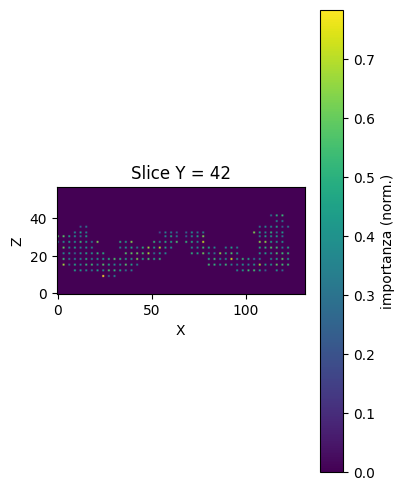

In [168]:
import matplotlib.pyplot as plt

# scegli un asse e una slice
X, Y, Z = importance_3d_norm.shape
print(X, Y, Z)

# ad es. taglio a metà lungo l'asse Y
y_slice = Y // 2

plt.figure(figsize=(4, 6))
plt.imshow(importance_3d_norm[:, y_slice, :].T, origin="lower")
plt.title(f"Slice Y = {y_slice}")
plt.colorbar(label="importanza (norm.)")
plt.xlabel("X")
plt.ylabel("Z")
plt.show()


Quando guardi il cervello con la mappa sopra:
i voxel più caldi (giallo/rosso) =
voxels dove il modello è molto sensibile: se il BOLD lì cambiasse, il logit cambierebbe tanto → il modello li considera importanti per la decisione.
i voxel freddi / neri =
il modello quasi non li usa (per il task e le classi che hai considerato).
È quindi una mappa di:
“quali zone il modello sta usando per risolvere il task fMRI che gli hai dato”,
non “quali zone sono in assoluto importanti nel cervello”.

# To make the video

In [ ]:
import nibabel as nib
affine = np.eye(4)

img = nib.Nifti1Image(importance_3d_norm, affine)
out_nii = os.path.join(DATA_DIR, "grad_importance_3d.nii.gz")
nib.save(img, out_nii)
print("Salvato:", out_nii)


Salvato: /content/drive/My Drive/Colab Notebooks/NEURO/ProjectMaterials/grad_importance_3d.nii.gz


In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# 1) brain mask: voxel dove IMPORTANZA > 0 (o dove c'è una ROI)
brain_mask_3d = (importance_3d > 0)   # shape: (X, Y, Z)

X, Y, Z = brain_mask_3d.shape
print("brain_mask_3d shape:", brain_mask_3d.shape)




brain_mask_3d shape: (132, 85, 57)


In [ ]:
import os
import nibabel as nib
import numpy as np

t1_path = os.path.join(DATA_DIR, "FMRIB58_FA_1mm.nii")
imp_path = os.path.join(DATA_DIR, "grad_importance_3d.nii.gz")

# carico le due immagini
t1_img  = nib.load(t1_path)
imp_img = nib.load(imp_path)

print("T1 shape:", t1_img.shape)
print("importance shape:", imp_img.shape)   # dovrebbe essere (132, 85, 57)


T1 shape: (182, 218, 182)
importance shape: (132, 85, 57)


In [ ]:
import os
import nibabel as nib
from nibabel.processing import resample_from_to

# Percorsi
t1_path  = os.path.join(DATA_DIR, "data", "Subject1_T1wAligned.nii")  # il tuo T1
imp_path = os.path.join(DATA_DIR, "grad_importance_3d.nii.gz")        # la mappa di importanza

# Carico le immagini
t1_img  = nib.load(t1_path)
imp_img = nib.load(imp_path)

print("T1 shape:", t1_img.shape)
print("Importance shape:", imp_img.shape)   # dovrebbe essere (132, 85, 57)

# Ricampiono il T1 sullo spazio (shape + affine) della mappa di importanza
t1_resampled = resample_from_to(t1_img, imp_img, order=1)  # order=1 = interpolazione lineare

print("T1 resampled shape:", t1_resampled.shape)  # ora dovrebbe essere (132, 85, 57)

# Salvo il nuovo T1 "allineato"
t1_resampled_path = os.path.join(DATA_DIR, "Subject1_T1w_resampled_to_importance.nii.gz")
nib.save(t1_resampled, t1_resampled_path)
print("Salvato:", t1_resampled_path)


T1 shape: (192, 256, 256)
Importance shape: (132, 85, 57)
T1 resampled shape: (132, 85, 57)
Salvato: /content/drive/My Drive/Colab Notebooks/NEURO/ProjectMaterials/Subject1_T1w_resampled_to_importance.nii.gz


In [ ]:
import os
import nibabel as nib
from nibabel.processing import resample_from_to

t1_path  = os.path.join(DATA_DIR, "data", "Subject1_T1wAligned.nii")
imp_path = os.path.join(DATA_DIR, "grad_importance_3d.nii.gz")

t1_img  = nib.load(t1_path)
imp_img = nib.load(imp_path)

print("T1 shape:", t1_img.shape)   # es. (182, 218, 182)
print("IMP shape:", imp_img.shape) # (132, 85, 57)

# ricampiono l’importance sullo spazio del T1
# order=1 -> lineare (ok per mappe continue), order=0 se vuoi proprio nearest-neighbor
imp_resampled = resample_from_to(imp_img, t1_img, order=1)

print("IMP resampled shape:", imp_resampled.shape)  # ora (182, 218, 182)

imp_resampled_path = os.path.join(DATA_DIR, "grad_importance_in_Subject1_space.nii.gz")
nib.save(imp_resampled, imp_resampled_path)
print("salvato:", imp_resampled_path)


T1 shape: (192, 256, 256)
IMP shape: (132, 85, 57)
IMP resampled shape: (192, 256, 256)
salvato: /content/drive/My Drive/Colab Notebooks/NEURO/ProjectMaterials/grad_importance_in_Subject1_space.nii.gz


In [ ]:
import os, nibabel as nib

t1_path  = os.path.join(DATA_DIR, "data", "Subject1_T1wAligned.nii")
imp_path = os.path.join(DATA_DIR, "grad_importance_3d.nii.gz")

t1_img  = nib.load(t1_path)
imp_img = nib.load(imp_path)

print("T1 shape:", t1_img.shape)
print("T1 affine:\n", t1_img.affine)

print("IMP shape:", imp_img.shape)
print("IMP affine:\n", imp_img.affine)


T1 shape: (192, 256, 256)
T1 affine:
 [[  -1.     0.     0.    95.5]
 [   0.     1.     0.  -127.5]
 [   0.     0.     1.  -127.5]
 [   0.     0.     0.     1. ]]
IMP shape: (132, 85, 57)
IMP affine:
 [[1. 0. 0. 0.]
 [0. 1. 0. 0.]
 [0. 0. 1. 0.]
 [0. 0. 0. 1.]]


In [ ]:
import os
import nibabel as nib
import numpy as np

t1_path = os.path.join(DATA_DIR, "data", "Subject1_T1wAligned.nii")
t1_img  = nib.load(t1_path)
t1_affine = t1_img.affine
print("T1 shape:", t1_img.shape)
print("T1 affine:\n", t1_affine)

A_inv = np.linalg.inv(t1_affine)


T1 shape: (192, 256, 256)
T1 affine:
 [[  -1.     0.     0.    95.5]
 [   0.     1.     0.  -127.5]
 [   0.     0.     1.  -127.5]
 [   0.     0.     0.     1. ]]


In [ ]:
coords_path = os.path.join(DATA_DIR, "data", "voxel_coords.npz")
coords = np.load(coords_path)

x = coords["x"]  # attenzione: NON quelli shiftati col min, proprio gli originali
y = coords["y"]
z = coords["z"]

num_vox = x.shape[0]
print("num_vox:", num_vox)


num_vox: 4466


In [ ]:
# costruiamo una matrice 4×N di coordinate in mm
world_coords = np.vstack([x, y, z, np.ones_like(x)])  # shape (4, num_vox)

# otteniamo indici (i,j,k) nello spazio del T1
ijk = A_inv @ world_coords  # shape (4, num_vox)
i = np.round(ijk[0]).astype(int)
j = np.round(ijk[1]).astype(int)
k = np.round(ijk[2]).astype(int)


In [ ]:
importance_T1 = np.zeros(t1_img.shape, dtype=np.float32)

for n in range(num_vox):
    ii, jj, kk = i[n], j[n], k[n]
    if 0 <= ii < t1_img.shape[0] and 0 <= jj < t1_img.shape[1] and 0 <= kk < t1_img.shape[2]:
        importance_T1[ii, jj, kk] += voxel_importance_flat[n]


In [ ]:
# normalizza per visualizzare meglio
max_val = importance_T1.max()
if max_val > 0:
    importance_T1_norm = importance_T1 / max_val
else:
    importance_T1_norm = importance_T1

imp_T1_img = nib.Nifti1Image(importance_T1_norm, t1_affine)
out_path = os.path.join(DATA_DIR, "grad_importance_in_Subject1_index_space.nii.gz")
nib.save(imp_T1_img, out_path)
print("Salvato:", out_path)


Salvato: /content/drive/My Drive/Colab Notebooks/NEURO/ProjectMaterials/grad_importance_in_Subject1_index_space.nii.gz


In [ ]:
import os
import numpy as np
import nibabel as nib

# 1) Carico T1 e affine/inversa
t1_path = os.path.join(DATA_DIR, "data", "Subject1_T1wAligned.nii")
t1_img  = nib.load(t1_path)
t1_affine = t1_img.affine
A_inv = np.linalg.inv(t1_affine)

print("T1 shape:", t1_img.shape)

# 2) Carico coordinate voxel (mondo, mm)
coords_path = os.path.join(DATA_DIR, "data", "voxel_coords.npz")
coords = np.load(coords_path)
x = coords["x"]
y = coords["y"]
z = coords["z"]
num_vox = x.shape[0]
print("num_vox:", num_vox)

# 3) Carico le ROI (dict: nome -> mask 1D di len 4466)
roi_mask_path = os.path.join(DATA_DIR, "data", "roi_masks.npz")  # metti il path giusto

masks_npz = np.load(roi_mask_path, allow_pickle=True)
print("Chiavi trovate in roi_masks.npz:", masks_npz.files)

# costruisco un dict {nome_roi: mask_4466}
rois = {name: masks_npz[name] for name in masks_npz.files}

ROI_NAMES = list(rois.keys())
ROI_NAMES.sort()  # opzionale, solo per avere un ordine stabile
print("ROI_NAMES:", ROI_NAMES)


# 4) Converto le coordinate mondo -> indici del T1
world_coords = np.vstack([x, y, z, np.ones_like(x)])  # (4, num_vox)
ijk = A_inv @ world_coords
i = np.round(ijk[0]).astype(int)
j = np.round(ijk[1]).astype(int)
k = np.round(ijk[2]).astype(int)

# 5) Creo volume etichette
roi_labels_T1 = np.zeros(t1_img.shape, dtype=np.int16)

# Se un voxel è in più ROI, verrà semplicemente sovrascritto dall'ultima (va bene per visualizzare la forma)
for roi_id, name in enumerate(ROI_NAMES, start=1):
    mask = rois[name].astype(bool)            # (4466,)
    idxs = np.where(mask)[0]                  # indici dei voxel di questa ROI
    print(name, "->", len(idxs), "voxel")

    for n in idxs:
        ii, jj, kk = i[n], j[n], k[n]
        if 0 <= ii < t1_img.shape[0] and 0 <= jj < t1_img.shape[1] and 0 <= kk < t1_img.shape[2]:
            roi_labels_T1[ii, jj, kk] = roi_id

# 6) Salvo la parcellazione
roi_parc_img = nib.Nifti1Image(roi_labels_T1, t1_affine)
out_path = os.path.join(DATA_DIR, "ROI_parcellation_in_Subject1.nii.gz")
nib.save(roi_parc_img, out_path)
print("Salvato:", out_path)


T1 shape: (192, 256, 256)
num_vox: 4466
Chiavi trovate in roi_masks.npz: ['V1', 'V2', 'V3', 'V4', 'FFA', 'PPA', 'LOC', 'LVC', 'HVC', 'VC']
ROI_NAMES: ['FFA', 'HVC', 'LOC', 'LVC', 'PPA', 'V1', 'V2', 'V3', 'V4', 'VC']
FFA -> 568 voxel
HVC -> 2049 voxel
LOC -> 540 voxel
LVC -> 2281 voxel
PPA -> 356 voxel
V1 -> 1004 voxel
V2 -> 1018 voxel
V3 -> 759 voxel
V4 -> 740 voxel
VC -> 4466 voxel
Salvato: /content/drive/My Drive/Colab Notebooks/NEURO/ProjectMaterials/ROI_parcellation_in_Subject1.nii.gz


In [ ]:
roi_labels_T1 = np.zeros(t1_img.shape, dtype=np.int16)

for roi_id, name in enumerate(ROI_NAMES, start=1):
    mask = rois[name].astype(bool)            # (4466,)
    idxs = np.where(mask)[0]                  # indici dei voxel di questa ROI
    print(name, "->", len(idxs), "voxel")

    for n in idxs:
        ii, jj, kk = i[n], j[n], k[n]
        if 0 <= ii < t1_img.shape[0] and 0 <= jj < t1_img.shape[1] and 0 <= kk < t1_img.shape[2]:
            roi_labels_T1[ii, jj, kk] = roi_id


FFA -> 568 voxel
HVC -> 2049 voxel
LOC -> 540 voxel
LVC -> 2281 voxel
PPA -> 356 voxel
V1 -> 1004 voxel
V2 -> 1018 voxel
V3 -> 759 voxel
V4 -> 740 voxel
VC -> 4466 voxel


In [ ]:
import os
import numpy as np
import nibabel as nib

# 1) carico coordinate voxel
coords_path = os.path.join(DATA_DIR, "data", "voxel_coords.npz")
coords = np.load(coords_path)
x = coords["x"].astype(int)
y = coords["y"].astype(int)
z = coords["z"].astype(int)
num_vox = x.shape[0]
print("num_vox:", num_vox)

# 2) bounding box come avevamo fatto per importance_3d
x_min, x_max = x.min(), x.max()
y_min, y_max = y.min(), y.max()
z_min, z_max = z.min(), z.max()

x0 = x - x_min
y0 = y - y_min
z0 = z - z_min

brain_shape = (
    int(x0.max() + 1),
    int(y0.max() + 1),
    int(z0.max() + 1),
)
print("brain_shape (funzionale):", brain_shape)

# 3) carico le ROI dal .npz
roi_mask_path = os.path.join(DATA_DIR, "data", "roi_masks.npz")
masks_npz = np.load(roi_mask_path, allow_pickle=True)
print("chiavi in roi_masks:", masks_npz.files)

rois = {name: masks_npz[name] for name in masks_npz.files}
ROI_NAMES = list(rois.keys())
ROI_NAMES.sort()
print("ROI_NAMES:", ROI_NAMES)

# opzionale: escludo macro-ROI tipo VC / LVC / HVC
EXCLUDE = ["VC", "LVC", "HVC"]
ATOMIC_ROI_NAMES = [name for name in ROI_NAMES if name not in EXCLUDE]
print("Userò queste ROI:", ATOMIC_ROI_NAMES)

# 4) creo volume etichette nello spazio funzionale
roi_labels_box = np.zeros(brain_shape, dtype=np.int16)

for roi_id, name in enumerate(ATOMIC_ROI_NAMES, start=1):
    mask = rois[name].astype(bool)
    assert mask.shape[0] == num_vox, f"Mask {name} ha shape {mask.shape}, mi aspettavo {num_vox}"
    idxs = np.where(mask)[0]
    print(name, "->", len(idxs), "voxel")

    for n in idxs:
        xi, yi, zi = x0[n], y0[n], z0[n]
        roi_labels_box[xi, yi, zi] = roi_id

# controllo valori
vals = np.unique(roi_labels_box)
print("Valori unici nella parcellazione funzionale:", vals)

# 5) salvo come NIfTI con affine identità
affine_box = np.eye(4)
roi_parc_img = nib.Nifti1Image(roi_labels_box.astype(np.int16), affine_box)
out_path = os.path.join(DATA_DIR, "ROI_parcellation_box_ATOMIC.nii.gz")
nib.save(roi_parc_img, out_path)
print("Salvato:", out_path)


num_vox: 4466
brain_shape (funzionale): (132, 85, 57)
chiavi in roi_masks: ['V1', 'V2', 'V3', 'V4', 'FFA', 'PPA', 'LOC', 'LVC', 'HVC', 'VC']
ROI_NAMES: ['FFA', 'HVC', 'LOC', 'LVC', 'PPA', 'V1', 'V2', 'V3', 'V4', 'VC']
Userò queste ROI: ['FFA', 'LOC', 'PPA', 'V1', 'V2', 'V3', 'V4']
FFA -> 568 voxel
LOC -> 540 voxel
PPA -> 356 voxel
V1 -> 1004 voxel
V2 -> 1018 voxel
V3 -> 759 voxel
V4 -> 740 voxel
Valori unici nella parcellazione funzionale: [0 1 2 3 4 5 6 7]
Salvato: /content/drive/My Drive/Colab Notebooks/NEURO/ProjectMaterials/ROI_parcellation_box_ATOMIC.nii.gz


roi_labels_box shape: (132, 85, 57)


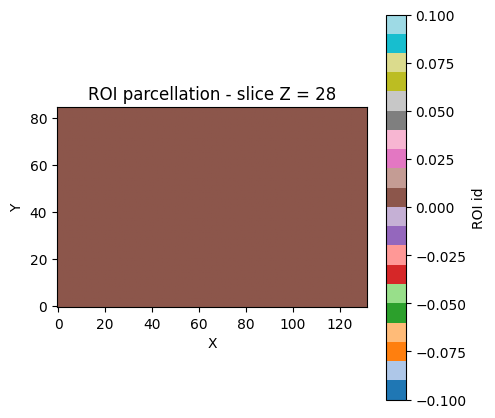

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

print("roi_labels_box shape:", roi_labels_box.shape)
X, Y, Z = roi_labels_box.shape

z_slice = Z // 2  # fetta a metà, puoi cambiare numero

slice_roi = roi_labels_box[:, :, z_slice]

plt.figure(figsize=(5, 5))
plt.imshow(slice_roi.T, origin="lower", cmap="tab20")  # .T solo per girarla come in ITK-SNAP
plt.title(f"ROI parcellation - slice Z = {z_slice}")
plt.colorbar(label="ROI id")
plt.xlabel("X")
plt.ylabel("Y")
plt.show()


In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# stessa slice
X, Y, Z = importance_3d_norm.shape
z_slice = Z // 2

slice_imp = importance_3d_norm[:, :, z_slice]
slice_roi = roi_labels_box[:, :, z_slice]

# mask: solo dove c'è una ROI (label > 0)
roi_mask = slice_roi > 0
roi_ids  = np.ma.masked_where(~roi_mask, slice_roi)  # maschera lo sfondo

plt.figure(figsize=(5, 5))
plt.imshow(slice_imp.T, origin="lower", cmap="gray")              # mappa importanza in grigio
plt.imshow(roi_ids.T, origin="lower", alpha=0.5, cmap="tab20")    # ROI sopra, semi-trasparenti
plt.title(f"Importanza + ROI - slice Z = {z_slice}")
plt.xlabel("X")
plt.ylabel("Y")
plt.colorbar(label="ROI id")
plt.show()


In [ ]:
import numpy as np

print("shape:", roi_labels_box.shape)
print("valori unici:", np.unique(roi_labels_box))
print("n. voxel > 0:", (roi_labels_box > 0).sum())


shape: (132, 85, 57)
valori unici: [0 1 2 3 4 5 6 7]
n. voxel > 0: 3706


In [ ]:
X, Y, Z = roi_labels_box.shape

non_empty_slices = [
    z for z in range(Z)
    if (roi_labels_box[:, :, z] > 0).any()
]

print("Slice con almeno una ROI:", non_empty_slices[:50])
print("Totale slice non vuote:", len(non_empty_slices))


Slice con almeno una ROI: [0, 3, 6, 9, 12, 15, 18, 21, 24, 27, 30, 32, 35, 38, 41, 44, 47, 50, 53, 56]
Totale slice non vuote: 20


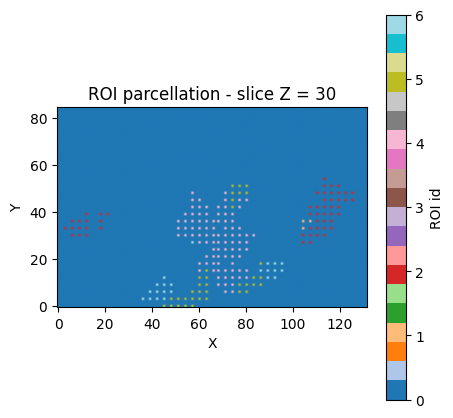

In [ ]:
import matplotlib.pyplot as plt

z_slice = non_empty_slices[len(non_empty_slices)//2]  # una slice "tipica" tra quelle non vuote

slice_roi = roi_labels_box[:, :, z_slice]

plt.figure(figsize=(5, 5))
plt.imshow(slice_roi.T, origin="lower", cmap="tab20")
plt.title(f"ROI parcellation - slice Z = {z_slice}")
plt.colorbar(label="ROI id")
plt.xlabel("X")
plt.ylabel("Y")
plt.show()


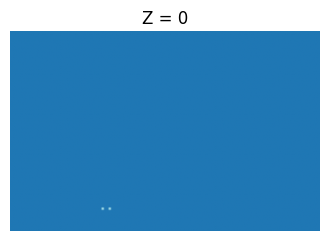

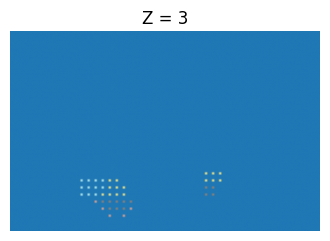

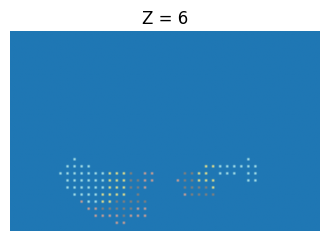

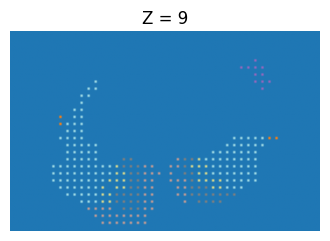

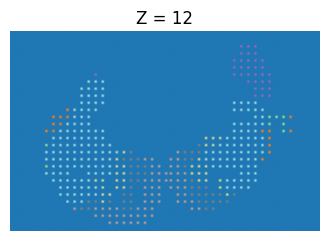

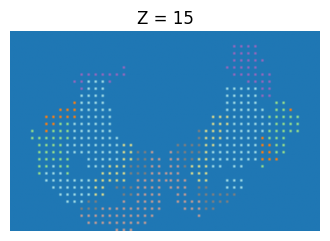

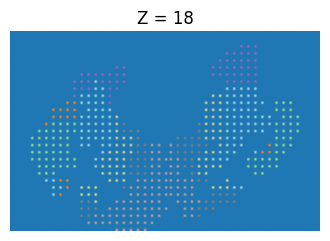

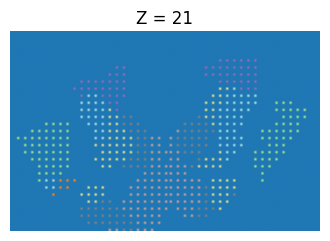

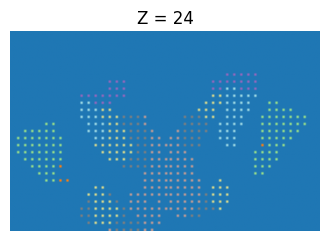

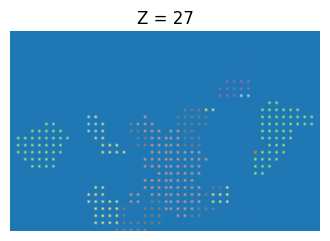

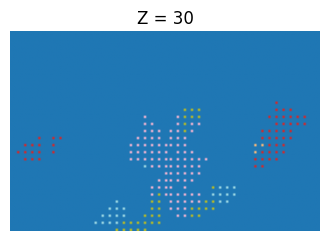

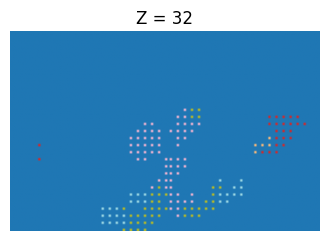

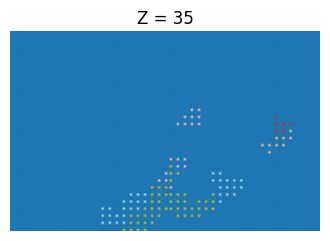

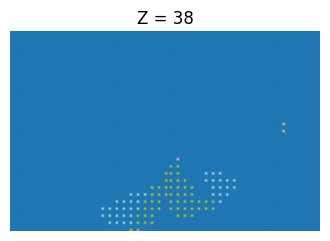

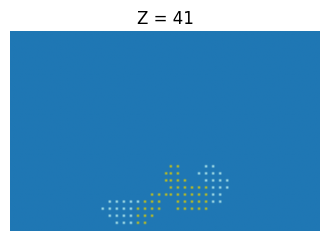

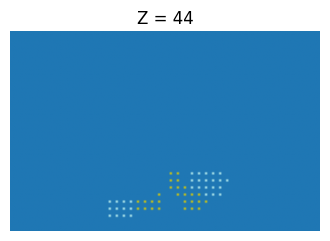

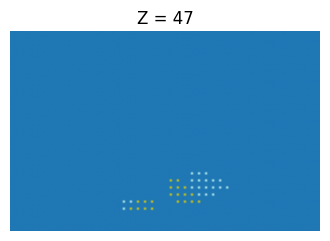

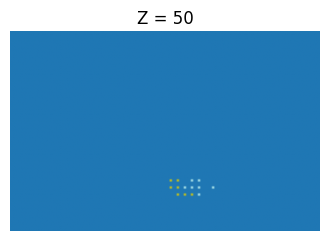

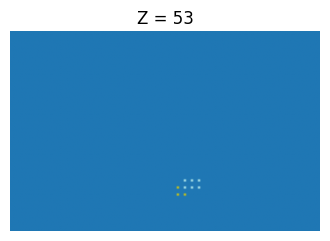

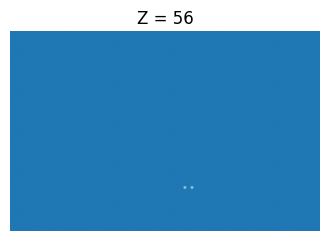

In [ ]:
for z in non_empty_slices:
    plt.figure(figsize=(4,4))
    plt.imshow(roi_labels_box[:, :, z].T, origin="lower", cmap="tab20")
    plt.title(f"Z = {z}")
    plt.axis("off")
    plt.show()


Slice con ROI: [0, 3, 6, 9, 12, 15, 18, 21, 24, 27, 30, 32, 35, 38, 41, 44, 47, 50, 53, 56]
ROI presenti in questa slice: [1 2 4 5 6]


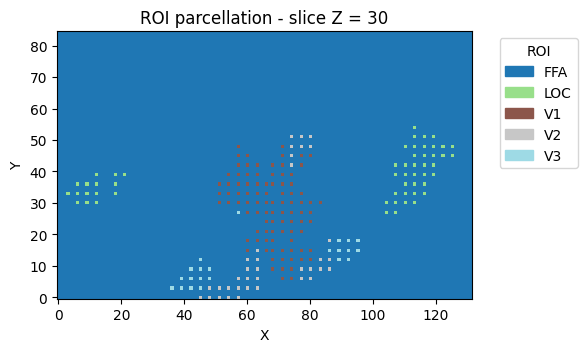

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap, BoundaryNorm
import matplotlib.patches as mpatches

# scegli una slice che non sia vuota
X, Y, Z = roi_labels_box.shape
non_empty_slices = [z for z in range(Z) if (roi_labels_box[:, :, z] > 0).any()]
print("Slice con ROI:", non_empty_slices)

z_slice = non_empty_slices[len(non_empty_slices)//2]  # una “tipica”
slice_roi = roi_labels_box[:, :, z_slice]

# id presenti (escludo lo 0 = sfondo)
roi_ids = np.unique(slice_roi)
roi_ids = roi_ids[roi_ids > 0]
print("ROI presenti in questa slice:", roi_ids)

# prendo un colore per ogni ROI
n_roi = len(roi_ids)
colors = plt.cm.tab20(np.linspace(0, 1, n_roi))  # tab20 ha 20 colori

# mappa discreta id -> colore
cmap = ListedColormap(colors)
norm = BoundaryNorm(np.arange(n_roi + 1) + 0.5, cmap.N)

# mappa gli id compressi 1..n_roi (per la colormap)
id_to_idx = {rid: i for i, rid in enumerate(roi_ids)}
slice_compact = np.zeros_like(slice_roi, dtype=int)
for rid in roi_ids:
    slice_compact[slice_roi == rid] = id_to_idx[rid] + 1  # da 1 a n_roi

plt.figure(figsize=(6, 6))
plt.imshow(slice_compact.T, origin="lower", cmap=cmap, norm=norm)
plt.title(f"ROI parcellation - slice Z = {z_slice}")
plt.xlabel("X")
plt.ylabel("Y")

# legenda con nomi delle ROI
patches = []
for rid in roi_ids:
    idx = id_to_idx[rid]
    roi_name = ATOMIC_ROI_NAMES[rid - 1]  # perché abbiamo usato start=1 nel loop
    patches.append(mpatches.Patch(color=colors[idx], label=roi_name))

plt.legend(handles=patches, bbox_to_anchor=(1.05, 1), loc="upper left", title="ROI")
plt.tight_layout()
plt.show()


In [ ]:
import numpy as np

X, Y, Z = roi_labels_box.shape
print("shape:", roi_labels_box.shape)

# slice dove c'è almeno una ROI
non_empty_slices = [z for z in range(Z) if (roi_labels_box[:, :, z] > 0).any()]
print("slice con qualche ROI:", non_empty_slices)

# mapping id -> nome
id_to_name = {rid: ATOMIC_ROI_NAMES[rid - 1] for rid in range(1, len(ATOMIC_ROI_NAMES) + 1)}


shape: (132, 85, 57)
slice con qualche ROI: [0, 3, 6, 9, 12, 15, 18, 21, 24, 27, 30, 32, 35, 38, 41, 44, 47, 50, 53, 56]


In [ ]:
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap, BoundaryNorm
import matplotlib.patches as mpatches

def plot_roi_slice(z, save_path=None):
    slice_roi = roi_labels_box[:, :, z]
    mask = slice_roi > 0

    if not mask.any():
        print(f"Slice Z={z}: vuota, niente ROI.")
        return

    # ROI presenti in questa slice
    roi_ids = np.unique(slice_roi[mask])
    print(f"Z={z}, ROI presenti:", [id_to_name[r] for r in roi_ids])

    n_roi = len(roi_ids)

    # colori belli e ben separati
    base_colors = plt.cm.tab20(np.linspace(0, 1, max(n_roi, 3)))
    colors = base_colors[:n_roi]
    cmap = ListedColormap(colors)
    norm = BoundaryNorm(np.arange(n_roi + 1) + 0.5, cmap.N)

    # comprimo gli id (es. [3,7,9] -> [1,2,3]) solo per la colormap
    id_to_idx = {rid: i for i, rid in enumerate(roi_ids)}
    compact = np.zeros_like(slice_roi, dtype=int)
    for rid in roi_ids:
        compact[slice_roi == rid] = id_to_idx[rid] + 1

    # sfondo nero
    bg = np.zeros_like(slice_roi, dtype=float)

    plt.figure(figsize=(6, 6))
    # sfondo grigio scuro
    plt.imshow(bg.T, origin="lower", cmap="gray", vmin=0, vmax=1)
    # ROI sopra, solo dove mask è True
    plt.imshow(
        np.ma.masked_where(~mask, compact).T,
        origin="lower",
        cmap=cmap,
        norm=norm,
        alpha=0.7,
    )

    plt.title(f"ROI parcellation – slice Z = {z}")
    plt.xlabel("X")
    plt.ylabel("Y")

    # legenda con nomi ROI
    patches = []
    for rid in roi_ids:
        idx = id_to_idx[rid]
        roi_name = id_to_name.get(rid, f"ROI {rid}")
        patches.append(mpatches.Patch(color=colors[idx], label=roi_name))

    plt.legend(
        handles=patches,
        bbox_to_anchor=(1.05, 1),
        loc="upper left",
        title="ROI",
    )
    plt.tight_layout()

    if save_path is not None:
        plt.savefig(save_path, dpi=150)
        plt.close()
    else:
        plt.show()


In [ ]:
for z in non_empty_slices:
    plot_roi_slice(z)


Z=0, ROI presenti: ['V1']


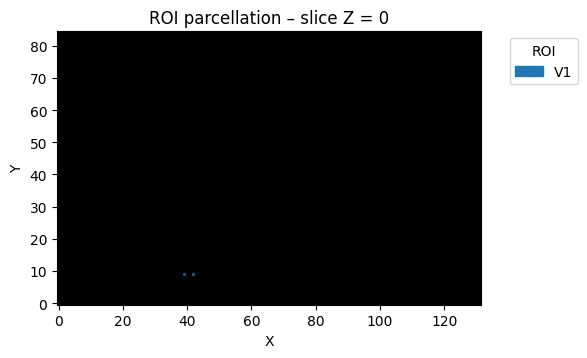

Z=3, ROI presenti: ['V1', 'V2', 'V3', 'V4']


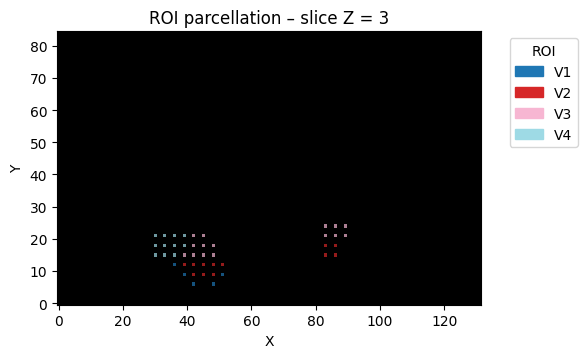

Z=6, ROI presenti: ['V1', 'V2', 'V3', 'V4']


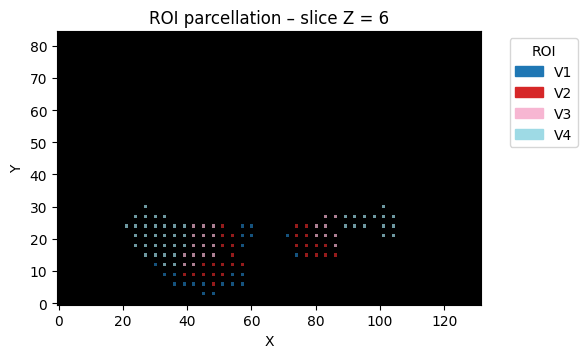

Z=9, ROI presenti: ['FFA', 'PPA', 'V1', 'V2', 'V3', 'V4']


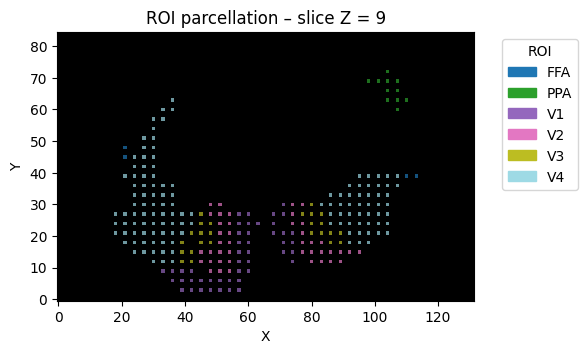

Z=12, ROI presenti: ['FFA', 'LOC', 'PPA', 'V1', 'V2', 'V3', 'V4']


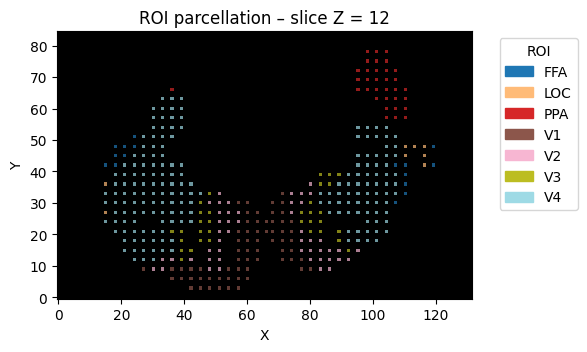

Z=15, ROI presenti: ['FFA', 'LOC', 'PPA', 'V1', 'V2', 'V3', 'V4']


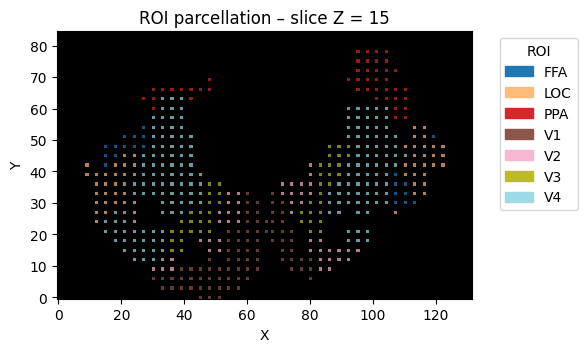

Z=18, ROI presenti: ['FFA', 'LOC', 'PPA', 'V1', 'V2', 'V3', 'V4']


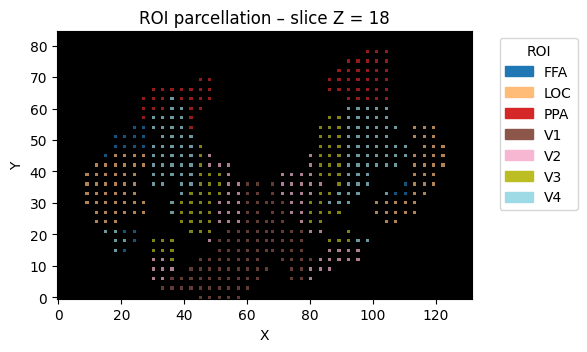

Z=21, ROI presenti: ['FFA', 'LOC', 'PPA', 'V1', 'V2', 'V3', 'V4']


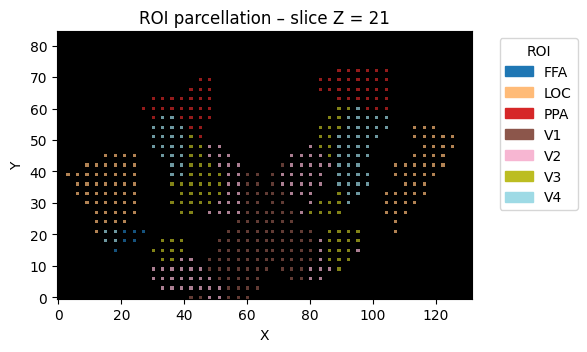

Z=24, ROI presenti: ['FFA', 'LOC', 'PPA', 'V1', 'V2', 'V3', 'V4']


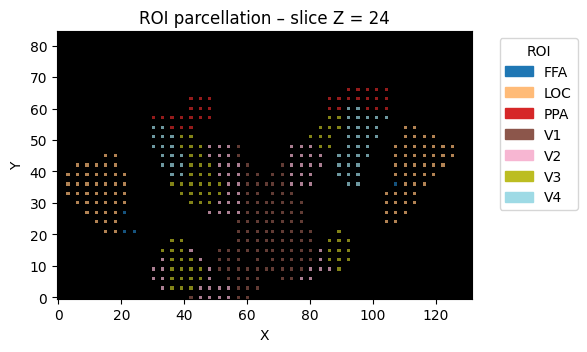

Z=27, ROI presenti: ['FFA', 'LOC', 'PPA', 'V1', 'V2', 'V3', 'V4']


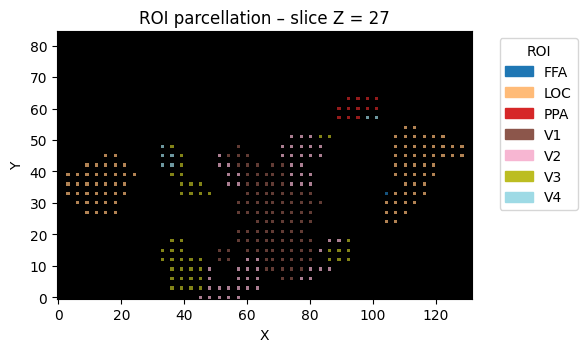

Z=30, ROI presenti: ['FFA', 'LOC', 'V1', 'V2', 'V3']


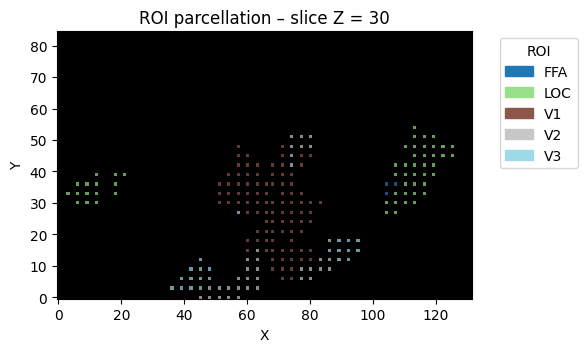

Z=32, ROI presenti: ['FFA', 'LOC', 'V1', 'V2', 'V3']


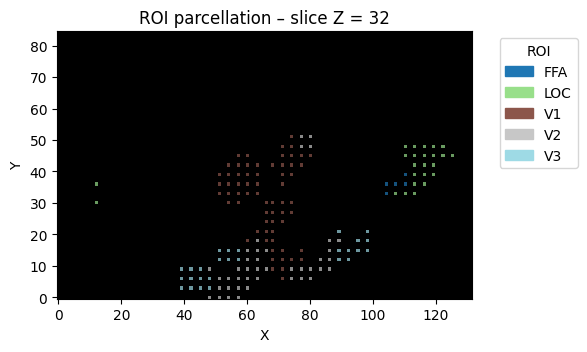

Z=35, ROI presenti: ['FFA', 'LOC', 'V1', 'V2', 'V3']


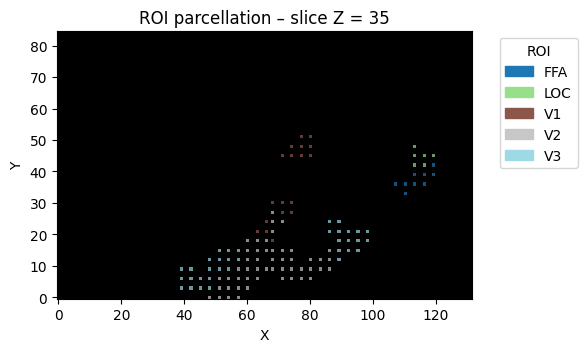

Z=38, ROI presenti: ['FFA', 'V1', 'V2', 'V3']


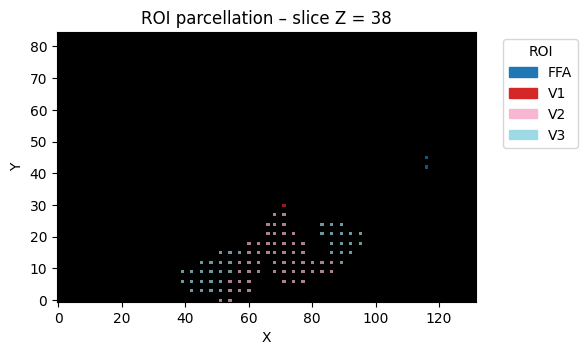

Z=41, ROI presenti: ['V2', 'V3']


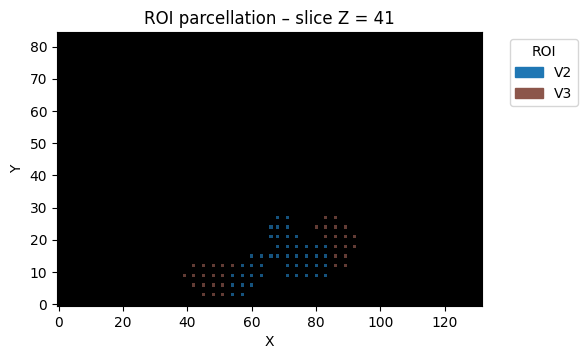

Z=44, ROI presenti: ['V2', 'V3']


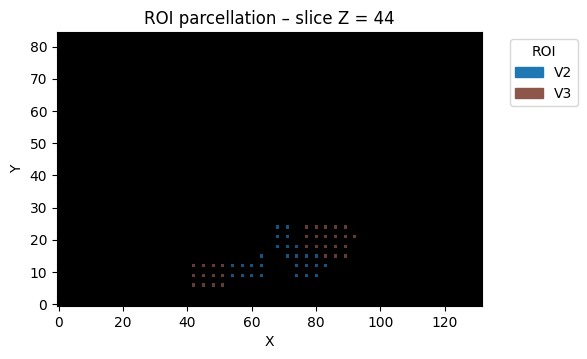

Z=47, ROI presenti: ['V2', 'V3']


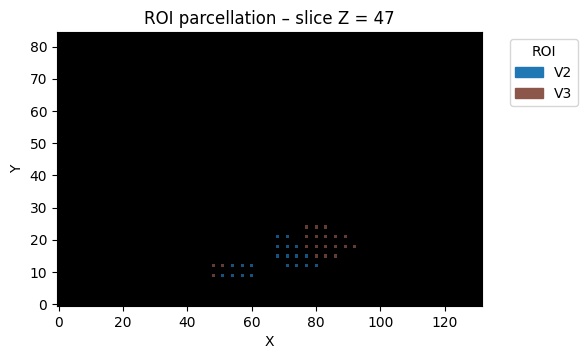

Z=50, ROI presenti: ['V2', 'V3']


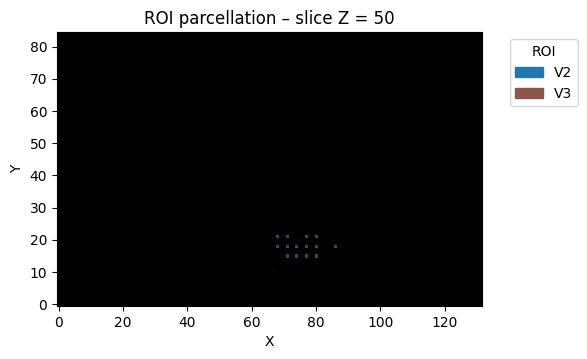

Z=53, ROI presenti: ['V2', 'V3']


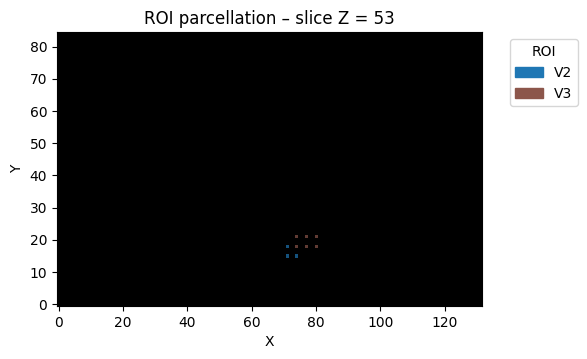

Z=56, ROI presenti: ['V3']


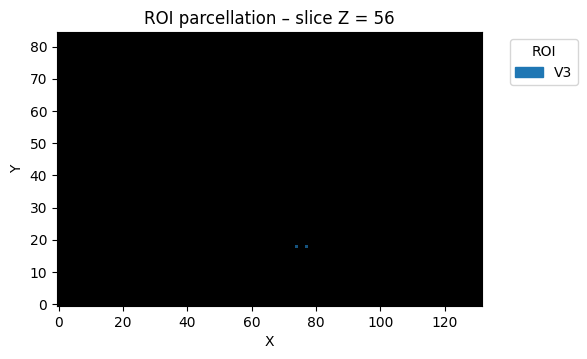

In [ ]:
for z in non_empty_slices:
    plot_roi_slice(z)


# Embeddings

In [169]:
model_super.eval()
all_Z = []
all_y = []

with torch.no_grad():
    for batch_x, batch_y in test_loader_super_excl:
        batch_x = batch_x.to(device)
        batch_y = batch_y.to(device)

        logits, emb = model_super(batch_x, return_embedding=True)  # <- qui
        all_Z.append(emb.cpu().numpy())
        all_y.append(batch_y.cpu().numpy())

Z = np.vstack(all_Z)      # (N, hidden_size)
y = np.concatenate(all_y) # (N,)

In [170]:
y_super = y_super_all[test_idx]    # oppure test_indices, quello che usi per X_test


In [171]:
superclass_names = list(super_encoder.classes_)

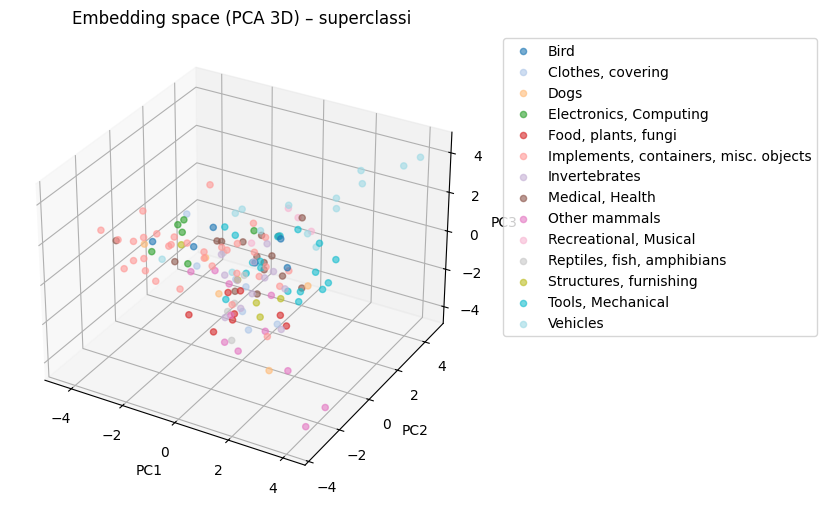

In [ ]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D  # solo per attivare il 3D
import numpy as np

pca = PCA(n_components=3)
Z_3d = pca.fit_transform(Z)  # (N, 3)

fig = plt.figure(figsize=(8, 7))
ax = fig.add_subplot(111, projection="3d")

colors = plt.cm.tab20(np.linspace(0, 1, len(superclass_names)))

for c, name in enumerate(superclass_names):
    mask = (y_super == c)
    if not np.any(mask):
        continue
    ax.scatter(
        Z_3d[mask, 0],
        Z_3d[mask, 1],
        Z_3d[mask, 2],
        s=20,
        alpha=0.6,
        color=colors[c],
        label=name,
    )

ax.set_xlabel("PC1")
ax.set_ylabel("PC2")
ax.set_zlabel("PC3")
ax.set_title("Embedding space (PCA 3D) – superclassi")
ax.legend(bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.show()


In [ ]:
superclass_names = list(super_encoder.classes_)
n_super = len(superclass_names)

centroids = []
for c in range(n_super):
    centroids.append(Z[y_super == c].mean(axis=0))
centroids = np.vstack(centroids)  # (n_super, D)


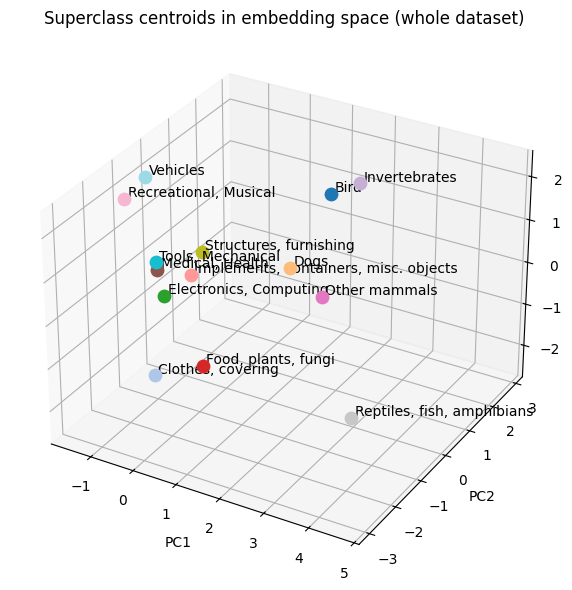

In [ ]:


pca = PCA(n_components=3)
C_3d = pca.fit_transform(centroids)  # (14, 3)

fig = plt.figure(figsize=(7, 6))
ax = fig.add_subplot(111, projection="3d")

colors = plt.cm.tab20(np.linspace(0, 1, n_super))

for c, name in enumerate(superclass_names):
    ax.scatter(C_3d[c, 0], C_3d[c, 1], C_3d[c, 2],
               s=80, color=colors[c])
    ax.text(C_3d[c, 0] + 0.05, C_3d[c, 1] + 0.05, C_3d[c, 2] + 0.05,
            name)

ax.set_xlabel("PC1")
ax.set_ylabel("PC2")
ax.set_zlabel("PC3")
ax.set_title("Superclass centroids in embedding space (whole dataset)")
plt.tight_layout()
plt.show()


In [177]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Collect true / predicted superclass labels on the test set
all_preds_super = []
all_targets_super = []

model_super.eval()
with torch.no_grad():
    for xb, yb in test_loader_super_excl:
        xb = xb.to(device)
        yb = yb.to(device)

        logits = model_super(xb)
        preds = logits.argmax(dim=1)

        all_preds_super.append(preds.cpu().numpy())
        all_targets_super.append(yb.cpu().numpy())

y_true_super = np.concatenate(all_targets_super)
y_pred_super = np.concatenate(all_preds_super)

# Confusion matrix (rows = true superclass, cols = predicted superclass)
cm_super = confusion_matrix(y_true_super, y_pred_super, labels=np.arange(n_super))

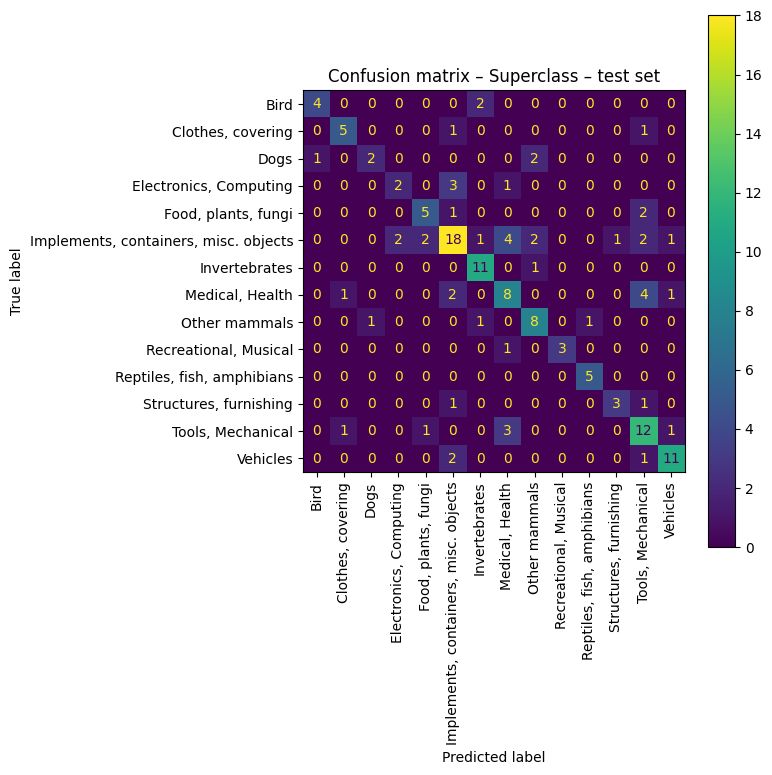

In [ ]:
fig, ax = plt.subplots(figsize=(8, 8))
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_super,
    display_labels=super_encoder.classes_   # <- qui
)
disp.plot(ax=ax, xticks_rotation='vertical', colorbar=True)
plt.title("Confusion matrix – Superclass – test set")
plt.tight_layout()
plt.show()


In [ ]:
import numpy as np

# SUPER IMPORTANT: adatta questa lista al TUO dataset
# Metti qui le superclassi che consideri "animate"
animate_superclasses = {
    "Dogs",
    "Bird",
    "Other mammals",
    "Reptiles, fish, amphibians",
}

# vettore per classe: 1 = animato, 0 = inanimato
is_animate_class = np.array([
    1 if name in animate_superclasses else 0
    for name in superclass_names
], dtype=int)

print(list(zip(superclass_names, is_animate_class)))


[('Bird', np.int64(1)), ('Clothes, covering', np.int64(0)), ('Dogs', np.int64(1)), ('Electronics, Computing', np.int64(0)), ('Food, plants, fungi', np.int64(0)), ('Implements, containers, misc. objects', np.int64(0)), ('Invertebrates', np.int64(0)), ('Medical, Health', np.int64(0)), ('Other mammals', np.int64(1)), ('Recreational, Musical', np.int64(0)), ('Reptiles, fish, amphibians', np.int64(1)), ('Structures, furnishing', np.int64(0)), ('Tools, Mechanical', np.int64(0)), ('Vehicles', np.int64(0))]


In [ ]:
# attributo per ogni sample del test set
is_animate_sample = is_animate_class[y_super]   # (N,)


In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

X = Z_3d              # (N, 3)
y_attr = is_animate_sample  # (N,)

clf = LogisticRegression(max_iter=1000)
clf.fit(X, y_attr)

y_pred = clf.predict(X)
acc = accuracy_score(y_attr, y_pred)
print("Accuracy animato vs inanimato nello spazio PCA-3D:", acc)

w = clf.coef_[0]       # (3,)
b = clf.intercept_[0]  # scalare

print("Peso w (direzione asse animato-inanimato):", w)
print("Intercetta b:", b)


Accuracy animato vs inanimato nello spazio PCA-3D: 0.9066666666666666
Peso w (direzione asse animato-inanimato): [ 1.44528074  0.14000418 -0.27048517]
Intercetta b: -2.885865191505819


In [ ]:
# centroidi delle superclassi nello spazio 3D
num_classes = len(superclass_names)
centroids_3d = []
for c in range(num_classes):
    mask = (y_super == c)
    if not np.any(mask):
        centroids_3d.append(None)
    else:
        centroids_3d.append(Z_3d[mask].mean(axis=0))

centroids_3d = np.array([
    c for c in centroids_3d if c is not None
])

# attenzione: per sicurezza rigenero l'indice delle classi effettivamente presenti
present_classes = [i for i in range(num_classes) if np.any(y_super == i)]

# normalizzo w per avere una direzione unitaria
w_norm = w / (np.linalg.norm(w) + 1e-12)

# proiezione di ogni superclasse lungo l'asse w
proj_scores = []
for cls_idx, centroid in zip(present_classes, centroids_3d):
    score = np.dot(centroid, w_norm)
    proj_scores.append((superclass_names[cls_idx],
                        is_animate_class[cls_idx],
                        score))

# ordina le superclassi lungo l'asse animato-inanimato
proj_scores_sorted = sorted(proj_scores, key=lambda x: x[2])

print("\nSuperclassi ordinate lungo l'asse 'animato ↔ inanimato':")
for name, is_anim, score in proj_scores_sorted:
    tag = "ANIMATO" if is_anim == 1 else "INANIMATO"
    print(f"{name:20s}  {tag:9s}  score = {score:.3f}")



Superclassi ordinate lungo l'asse 'animato ↔ inanimato':
Vehicles              INANIMATO  score = -2.137
Recreational, Musical  INANIMATO  score = -1.962
Tools, Mechanical     INANIMATO  score = -1.219
Implements, containers, misc. objects  INANIMATO  score = -0.733
Medical, Health       INANIMATO  score = -0.608
Structures, furnishing  INANIMATO  score = -0.218
Electronics, Computing  INANIMATO  score = -0.090
Clothes, covering     INANIMATO  score = 0.076
Food, plants, fungi   INANIMATO  score = 0.850
Bird                  ANIMATO    score = 1.026
Invertebrates         INANIMATO  score = 1.353
Dogs                  ANIMATO    score = 2.406
Reptiles, fish, amphibians  ANIMATO    score = 3.187
Other mammals         ANIMATO    score = 3.414


In [ ]:
is_animate = np.array([
    1 if name in animate_superclasses else 0
    for name in superclass_names
], dtype=int)

print(list(zip(superclass_names, is_animate)))

[('Bird', np.int64(1)), ('Clothes, covering', np.int64(0)), ('Dogs', np.int64(1)), ('Electronics, Computing', np.int64(0)), ('Food, plants, fungi', np.int64(0)), ('Implements, containers, misc. objects', np.int64(0)), ('Invertebrates', np.int64(0)), ('Medical, Health', np.int64(0)), ('Other mammals', np.int64(1)), ('Recreational, Musical', np.int64(0)), ('Reptiles, fish, amphibians', np.int64(1)), ('Structures, furnishing', np.int64(0)), ('Tools, Mechanical', np.int64(0)), ('Vehicles', np.int64(0))]


In [ ]:
# centroidi delle classi animate / inanimate
C_anim = C_3d[is_animate == 1]
C_inanim = C_3d[is_animate == 0]

mu_anim = C_anim.mean(axis=0)      # (3,)
mu_inanim = C_inanim.mean(axis=0)  # (3,)

# direzione dell'asse animato-inanimato
w_dir = mu_anim - mu_inanim
w_dir = w_dir / (np.linalg.norm(w_dir) + 1e-12)  # normalizza

# punto centrale dell'asse (a metà tra le due medie)
center = 0.5 * (mu_anim + mu_inanim)



In [ ]:
# centroidi delle classi animate / inanimate
C_anim = C_3d[is_animate == 1]
C_inanim = C_3d[is_animate == 0]

mu_anim = C_anim.mean(axis=0)      # (3,)
mu_inanim = C_inanim.mean(axis=0)  # (3,)

# direzione dell'asse animato-inanimato
w_dir = mu_anim - mu_inanim
w_dir = w_dir / (np.linalg.norm(w_dir) + 1e-12)  # normalizza

# punto centrale dell'asse (a metà tra le due medie)
center = 0.5 * (mu_anim + mu_inanim)


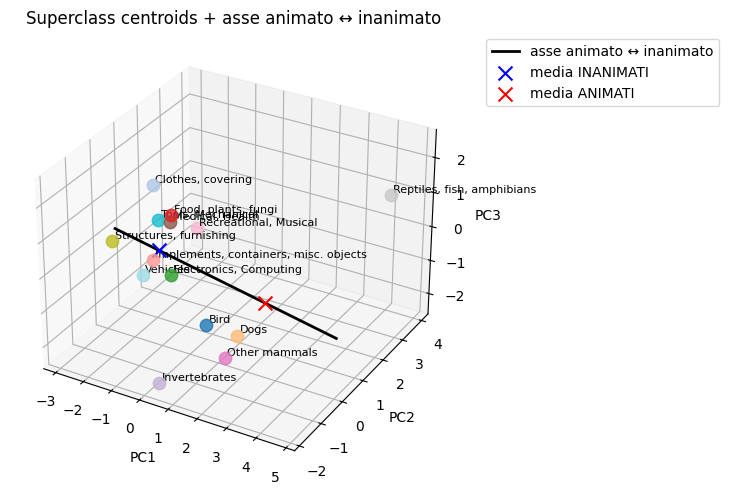

In [ ]:
from mpl_toolkits.mplot3d import Axes3D
import matplotlib.pyplot as plt

fig = plt.figure(figsize=(7, 6))
ax = fig.add_subplot(111, projection="3d")

colors = plt.cm.tab20(np.linspace(0, 1, n_super))

# scatter dei centroidi, colorati come vuoi (qui come prima)
for c, name in enumerate(superclass_names):
    ax.scatter(C_3d[c, 0], C_3d[c, 1], C_3d[c, 2],
               s=80,
               color=colors[c],
               alpha=0.8)
    ax.text(C_3d[c, 0] + 0.05,
            C_3d[c, 1] + 0.05,
            C_3d[c, 2] + 0.05,
            name,
            fontsize=8)

# ---- 🔹 linea animato ↔ inanimato 🔹 ----

# proiezione dei centroidi lungo la direzione w_dir
proj = (C_3d - center) @ w_dir  # (n_super,)

# scegliamo un range un po' più largo dei centroidi
t_min = proj.min() - 0.5
t_max = proj.max() + 0.5

t_vals = np.linspace(t_min, t_max, 50)
line_points = center[None, :] + np.outer(t_vals, w_dir)  # (50, 3)

ax.plot(
    line_points[:, 0],
    line_points[:, 1],
    line_points[:, 2],
    color="black",
    linewidth=2,
    label="asse animato ↔ inanimato"
)

# opzionale: evidenzia i due "poli"
ax.scatter(*mu_inanim, color="blue", s=100, marker="x", label="media INANIMATI")
ax.scatter(*mu_anim,   color="red",  s=100, marker="x", label="media ANIMATI")

ax.set_xlabel("PC1")
ax.set_ylabel("PC2")
ax.set_zlabel("PC3")
ax.set_title("Superclass centroids + asse animato ↔ inanimato")
ax.legend(bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.show()


In [ ]:
scores = proj  # già calcolato sopra
order = np.argsort(scores)

print("Superclassi ordinate lungo l'asse inanimato ↔ animato:")
for idx in order:
    tag = "ANIMATO" if is_animate[idx] == 1 else "INANIMATO"
    print(f"{superclass_names[idx]:20s} {tag:9s} score = {scores[idx]:.3f}")


Superclassi ordinate lungo l'asse inanimato ↔ animato:
Recreational, Musical INANIMATO score = -2.776
Structures, furnishing INANIMATO score = -2.593
Tools, Mechanical    INANIMATO score = -2.339
Vehicles             INANIMATO score = -2.189
Clothes, covering    INANIMATO score = -2.078
Medical, Health      INANIMATO score = -1.960
Implements, containers, misc. objects INANIMATO score = -1.704
Food, plants, fungi  INANIMATO score = -1.102
Electronics, Computing INANIMATO score = -1.043
Invertebrates        INANIMATO score = -0.033
Bird                 ANIMATO   score = 0.475
Other mammals        ANIMATO   score = 1.508
Dogs                 ANIMATO   score = 1.510
Reptiles, fish, amphibians ANIMATO   score = 3.634


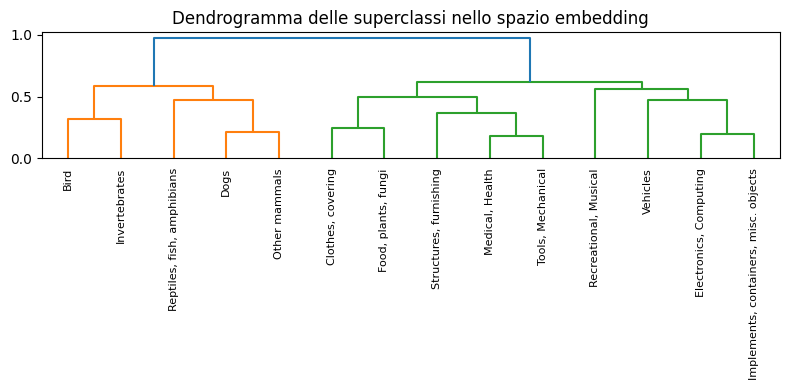

In [ ]:
from scipy.spatial.distance import pdist, squareform
from scipy.cluster.hierarchy import linkage, dendrogram
import matplotlib.pyplot as plt
import numpy as np

# centroids: (n_super, hidden_size)
# superclass_names: lista nomi superclassi

# matrice delle distanze tra centroidi (cosine)
dist_centroids = pdist(centroids, metric="cosine")       # vettore condensato
Z_link = linkage(dist_centroids, method="ward")

plt.figure(figsize=(8, 4))
dendrogram(
    Z_link,
    labels=superclass_names,
    leaf_rotation=90,
    leaf_font_size=8,
)
plt.title("Dendrogramma delle superclassi nello spazio embedding")
plt.tight_layout()
plt.show()


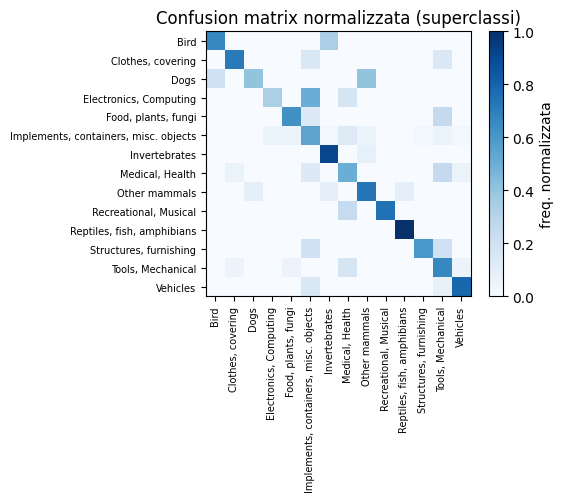

In [ ]:


model_super.eval()
all_y_true = []
all_y_pred = []

with torch.no_grad():
    for batch_x, batch_y in test_loader_super_excl:
        batch_x = batch_x.to(device)
        batch_y = batch_y.to(device)

        logits = model_super(batch_x)  # forward normale
        preds = logits.argmax(dim=1)

        all_y_true.append(batch_y.cpu().numpy())
        all_y_pred.append(preds.cpu().numpy())

y_true = np.concatenate(all_y_true)   # (N_test,)
y_pred = np.concatenate(all_y_pred)   # (N_test,)

cm = confusion_matrix(y_true, y_pred, labels=np.arange(len(superclass_names)))
cm = cm.astype(float)

# normalizzazione per riga → percentuale di esempi di classe i predetti come j
cm_norm = cm / (cm.sum(axis=1, keepdims=True) + 1e-12)

plt.figure(figsize=(6, 5))
plt.imshow(cm_norm, cmap="Blues")
plt.colorbar(label="freq. normalizzata")
plt.xticks(range(len(superclass_names)), superclass_names, rotation=90, fontsize=7)
plt.yticks(range(len(superclass_names)), superclass_names, fontsize=7)
plt.title("Confusion matrix normalizzata (superclassi)")
plt.tight_layout()
plt.show()


In [ ]:
from scipy.stats import spearmanr

n_super = len(superclass_names)

# distanza tra centroidi (usiamo già dist_centroids calcolata prima)
dist_matrix = squareform(dist_centroids)  # (n_super, n_super)

pairs = []
dist_list = []
conf_list = []

for i in range(n_super):
    for j in range(i+1, n_super):
        # distanza tra centroidi
        d = dist_matrix[i, j]

        # confusion media tra i e j (simmetrica)
        conf_ij = 0.5 * (cm_norm[i, j] + cm_norm[j, i])

        pairs.append((i, j))
        dist_list.append(d)
        conf_list.append(conf_ij)

dist_arr = np.array(dist_list)
conf_arr = np.array(conf_list)

rho, pval = spearmanr(dist_arr, conf_arr)
print("Correlazione distanza ↔ confusione (Spearman): rho = %.3f, p = %.3g" % (rho, pval))

# opzionale: vedere le coppie più confuse & vicine
sorted_pairs = sorted(
    zip(pairs, dist_arr, conf_arr),
    key=lambda x: -x[2]  # ordina per confusione decrescente
)

print("\nCoppie più confuse (top 10):")
for (i, j), d, c in sorted_pairs[:10]:
    print(f"{superclass_names[i]:25s} - {superclass_names[j]:25s}  conf={c:.3f}  dist={d:.3f}")


Correlazione distanza ↔ confusione (Spearman): rho = -0.642, p = 6.77e-12

Coppie più confuse (top 10):
Electronics, Computing    - Implements, containers, misc. objects  conf=0.280  dist=0.201
Dogs                      - Other mammals              conf=0.245  dist=0.214
Medical, Health           - Tools, Mechanical          conf=0.208  dist=0.178
Bird                      - Invertebrates              conf=0.167  dist=0.316
Food, plants, fungi       - Tools, Mechanical          conf=0.153  dist=0.387
Medical, Health           - Recreational, Musical      conf=0.125  dist=0.344
Implements, containers, misc. objects - Medical, Health            conf=0.123  dist=0.221
Implements, containers, misc. objects - Structures, furnishing     conf=0.115  dist=0.405
Bird                      - Dogs                       conf=0.100  dist=0.247
Structures, furnishing    - Tools, Mechanical          conf=0.100  dist=0.337


In [ ]:

# pca = PCA(n_components=3)
# C_3d = pca.fit_transform(centroids)

# C_3d: (n_super, 3)
pc_scores = C_3d  # alias

for k in range(3):
    scores_k = pc_scores[:, k]
    order = np.argsort(scores_k)

    print(f"\nPC{k+1}:")
    print("  Valori più BASSI:")
    for idx in order[:5]:
        print(f"    {superclass_names[idx]:25s} score={scores_k[idx]:.3f}")
    print("  Valori più ALTI:")
    for idx in order[-5:][::-1]:
        print(f"    {superclass_names[idx]:25s} score={scores_k[idx]:.3f}")



PC1:
  Valori più BASSI:
    Recreational, Musical     score=-2.883
    Vehicles                  score=-1.633
    Tools, Mechanical         score=-1.521
    Structures, furnishing    score=-1.472
    Medical, Health           score=-1.124
  Valori più ALTI:
    Reptiles, fish, amphibians score=4.603
    Dogs                      score=2.119
    Other mammals             score=2.062
    Bird                      score=1.052
    Invertebrates             score=0.354

PC2:
  Valori più BASSI:
    Invertebrates             score=-1.791
    Structures, furnishing    score=-1.449
    Other mammals             score=-1.060
    Food, plants, fungi       score=-1.048
    Clothes, covering         score=-0.658
  Valori più ALTI:
    Recreational, Musical     score=3.929
    Reptiles, fish, amphibians score=3.160
    Medical, Health           score=0.579
    Tools, Mechanical         score=0.543
    Vehicles                  score=-0.047

PC3:
  Valori più BASSI:
    Invertebrates             s

embedding del pattern fMRI di quel trial così come il modello lo “vede”, in uno spazio di dimensione hidden_size (tipo 128).

num_vox: 4466
x_min, x_max: -67 64
y_min, y_max: -85 -1
z_min, z_max: -31 25
brain_shape: (132, 85, 57)
voxel_importance_flat.shape: (4466,)
importance_3d shape finale: (132, 85, 57)
importanza max: 0.0063942512 min: 0.0
Soglia per top 1%: 0.00430
Num voxel top: 45


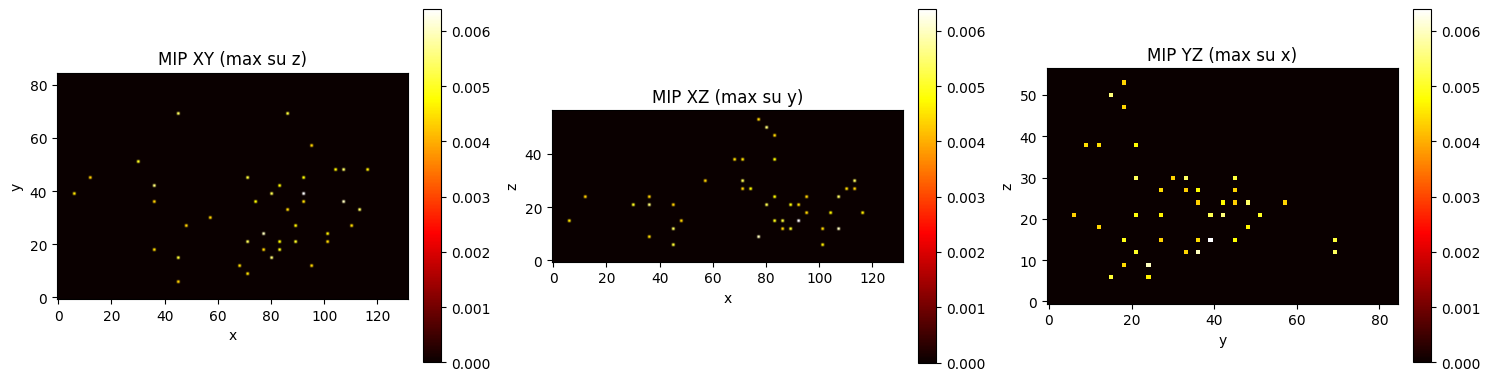

Prime 10 coordinate dei voxel top:
[[-10 -55  -1]
 [  4 -64  -1]
 [  4 -40  -4]
 [  4 -40  -1]
 [  7 -49  -4]
 [-22 -79 -10]
 [-22 -70 -25]
 [-19 -58 -16]
 [  1 -73   7]
 [  4 -76   7]
 [ 10 -67  22]
 [ 10 -61 -22]
 [ 13 -70  19]
 [ 13 -46 -10]
 [ 16 -67 -16]
 [ 16 -67  16]
 [ 16 -43  -7]
 [ 28 -73 -13]
 [-31 -67 -22]
 [-31 -49  -7]]


In [ ]:


# ==============
# 1) Ricarico coords e ricostruisco il volume 3D di importanza
# ==============

coords_path = os.path.join(DATA_DIR, "data/voxel_coords.npz")
coords = np.load(coords_path)

x = coords["x"].astype(int)
y = coords["y"].astype(int)
z = coords["z"].astype(int)

num_vox = x.shape[0]
print("num_vox:", num_vox)
assert num_vox > 0, "Nessun voxel trovato!"

# bounding box 0-based
x_min, x_max = x.min(), x.max()
y_min, y_max = y.min(), y.max()
z_min, z_max = z.min(), z.max()

print("x_min, x_max:", x_min, x_max)
print("y_min, y_max:", y_min, y_max)
print("z_min, z_max:", z_min, z_max)

brain_shape = (
    int(x_max - x_min + 1),
    int(y_max - y_min + 1),
    int(z_max - z_min + 1),
)

print("brain_shape:", brain_shape)
assert all(d > 0 for d in brain_shape), f"Dimensione zero in brain_shape: {brain_shape}"

# volume di importanza completo
importance_3d = np.zeros(brain_shape, dtype=np.float32)

# voxel_importance_flat deve avere length = num_vox
print("voxel_importance_flat.shape:", voxel_importance_flat.shape)
assert voxel_importance_flat.shape[0] == num_vox

# riempiamo la griglia traslando le coordinate
for j in range(num_vox):
    xi = int(x[j] - x_min)
    yi = int(y[j] - y_min)
    zi = int(z[j] - z_min)
    importance_3d[xi, yi, zi] = voxel_importance_flat[j]

print("importance_3d shape finale:", importance_3d.shape)
print("importanza max:", importance_3d.max(), "min:", importance_3d.min())

# ==============
# 2) Teniamo SOLO i voxel più importanti
#    (ad es. top 1% per valore di importanza)
# ==============

# Consideriamo solo voxel non nulli per stimare il percentile
nonzero_vals = importance_3d[importance_3d > 0]
assert nonzero_vals.size > 0, "Tutti i voxel hanno importanza zero?"

# Cambia questo percentile se vuoi più/meno voxel accesi
top_percentile = 99  # top 1%
threshold = np.percentile(nonzero_vals, top_percentile)
print(f"Soglia per top {100 - top_percentile}%: {threshold:.5f}")

# volume con solo i voxel sopra soglia
importance_3d_top = np.where(importance_3d >= threshold, importance_3d, 0)

print("Num voxel top:", (importance_3d_top > 0).sum())

# ==============
# 3) Visualizzazione: proiezioni massime (MIP)
#    lungo i tre assi (XY, XZ, YZ) per vedere dove si accendono
# ==============

# Max projection su ciascun asse
# attenzione: axis=0 -> comprime x, etc.
mip_xy = importance_3d_top.max(axis=2)  # proiezione lungo z → piano XY
mip_xz = importance_3d_top.max(axis=1)  # proiezione lungo y → piano XZ
mip_yz = importance_3d_top.max(axis=0)  # proiezione lungo x → piano YZ

fig, axs = plt.subplots(1, 3, figsize=(15, 4))

# Piano XY (come una "vista dall'alto" sull'asse z)
im0 = axs[0].imshow(mip_xy.T, origin="lower", cmap="hot")
axs[0].set_title("MIP XY (max su z)")
axs[0].set_xlabel("x")
axs[0].set_ylabel("y")
plt.colorbar(im0, ax=axs[0], fraction=0.046, pad=0.04)

# Piano XZ
im1 = axs[1].imshow(mip_xz.T, origin="lower", cmap="hot")
axs[1].set_title("MIP XZ (max su y)")
axs[1].set_xlabel("x")
axs[1].set_ylabel("z")
plt.colorbar(im1, ax=axs[1], fraction=0.046, pad=0.04)

# Piano YZ
im2 = axs[2].imshow(mip_yz.T, origin="lower", cmap="hot")
axs[2].set_title("MIP YZ (max su x)")
axs[2].set_xlabel("y")
axs[2].set_ylabel("z")
plt.colorbar(im2, ax=axs[2], fraction=0.046, pad=0.04)

plt.tight_layout()
plt.show()

# ==============
# 4) (OPZIONALE) Stampare le coordinate dei voxel top
#    se vuoi "vedere" anche quali sono
# ==============

top_coords = np.column_stack([x, y, z])[voxel_importance_flat >= threshold]
print("Prime 10 coordinate dei voxel top:")
print(top_coords[:20])


n_roi: 10    n_voxel: 4466
idx_frog: 42  idx_tomato: 137
Calcolo voxel_importance_flat_frog ...
Calcolo voxel_importance_flat_tomato ...
frog   shape: (4466,)
tomato shape: (4466,)
num_vox: 4466
brain_shape: (132, 85, 57)
vol_diff max: 0.6754101  min: -0.8087753


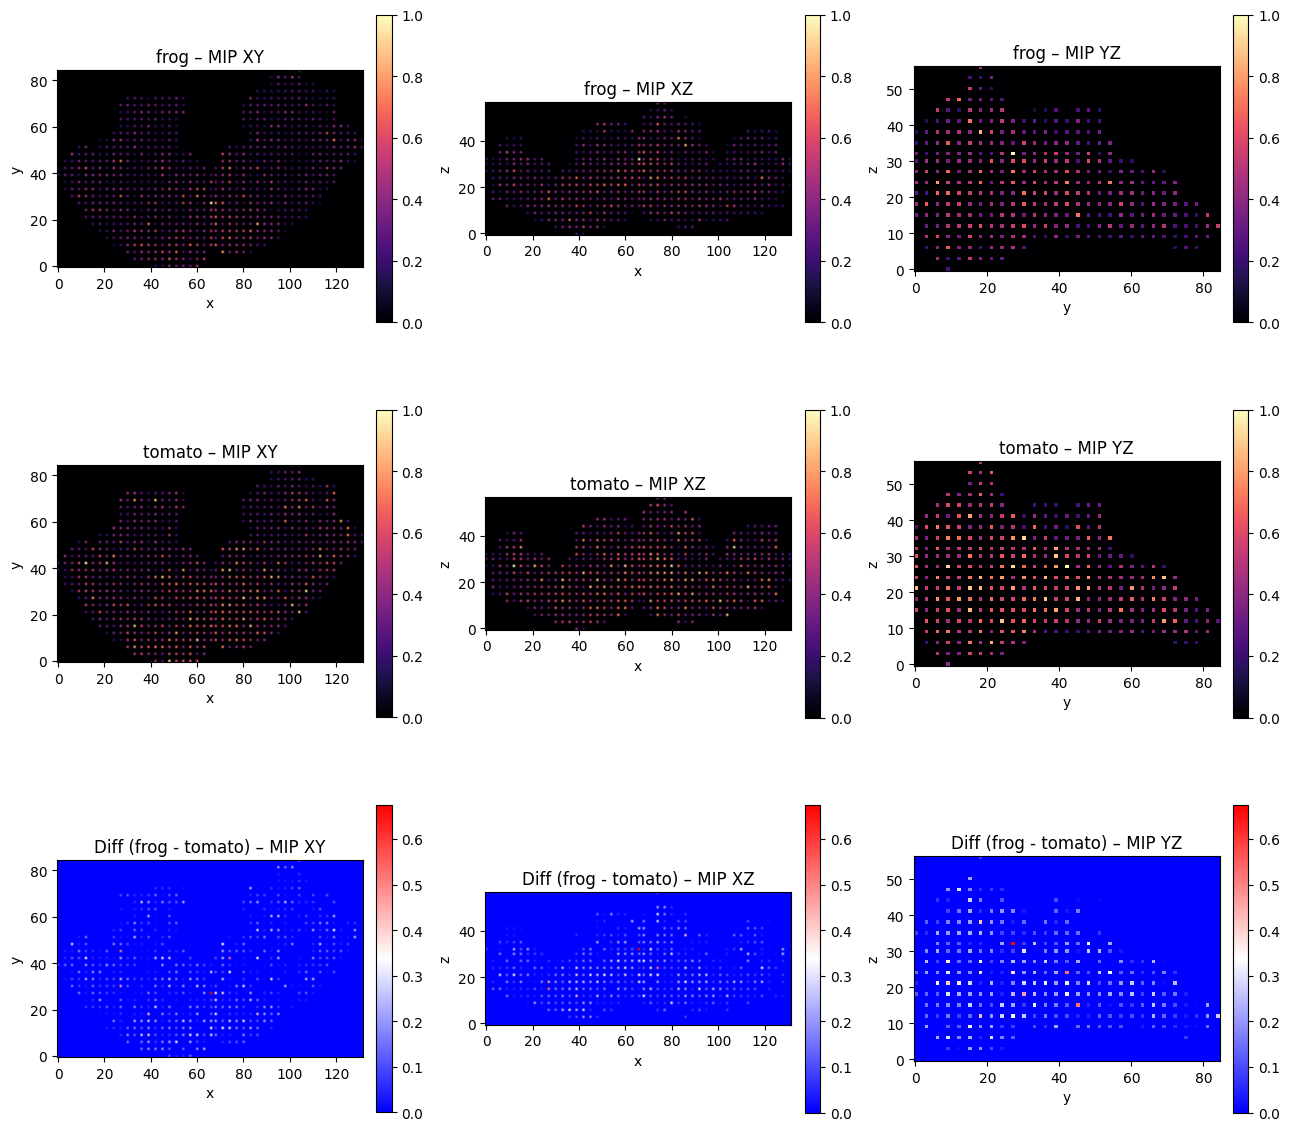

In [ ]:


device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# ============================
# 0) Setup base: modello, encoder, classi frog/tomato
# ============================

model = model_fine_direct.to(device)   # modello per le fine class
model.eval()

# prendo le dimensioni dai dati (fMRI ROI x voxel)
n_roi   = X_train_excl_norm.shape[1]
n_voxel = X_train_excl_norm.shape[2]
print("n_roi:", n_roi, "   n_voxel:", n_voxel)

# nomi EXACT delle classi (come in label_encoder.classes_)
cls_frog   = "frog"
cls_tomato = "tomato"

# indici interni delle classi
idx_frog   = fine_encoder.transform([cls_frog])[0]
idx_tomato = fine_encoder.transform([cls_tomato])[0]
print("idx_frog:", idx_frog, " idx_tomato:", idx_tomato)

# dataloader che usiamo per stimare le mappe
data_loader = train_loader_fine_direct_excl


# ============================
# 1) Funzione: importanza voxel per UNA classe
# ============================

def compute_class_voxel_importance(model, data_loader, class_idx):
    """
    Calcola una mappa di importanza voxel per una singola classe,
    usando il gradiente del logit della classe rispetto all'input.

    Ritorna: voxel_importance_flat shape (n_voxel,)
    """
    model.eval()
    voxel_sum = torch.zeros(n_voxel, device=device)
    count = 0

    for X_batch, y_batch in data_loader:
        X_batch = X_batch.to(device)      # (B, n_roi, n_voxel)
        y_batch = y_batch.to(device)      # (B,)

        # tieni solo i sample della classe class_idx
        mask = (y_batch == class_idx)
        if mask.sum() == 0:
            continue

        X = X_batch[mask]                 # (B_cls, n_roi, n_voxel)
        if X.size(0) == 0:
            continue

        X.requires_grad_(True)

        # forward
        logits = model(X)                 # (B_cls, num_classi)
        logit_c = logits[:, class_idx].sum()  # scalare

        model.zero_grad()
        if X.grad is not None:
            X.grad.zero_()

        # backward w.r.t. input
        logit_c.backward()
        grad = X.grad.detach()            # (B_cls, n_roi, n_voxel)

        # importanza = media su ROI dell'ampiezza del gradiente
        grad_abs = grad.abs().mean(dim=1) # (B_cls, n_voxel)

        # somma su batch
        voxel_sum += grad_abs.sum(dim=0)  # (n_voxel,)
        count += X.size(0)

    if count == 0:
        print(f"ATTENZIONE: nessun campione per class_idx={class_idx}")
        return torch.zeros(n_voxel)

    voxel_importance = voxel_sum / count
    return voxel_importance.cpu().numpy()   # (n_voxel,)


# ============================
# 2) Calcolo le mappe voxel per frog e tomato
# ============================

print("Calcolo voxel_importance_flat_frog ...")
voxel_importance_flat_frog = compute_class_voxel_importance(
    model, data_loader, class_idx=idx_frog
)

print("Calcolo voxel_importance_flat_tomato ...")
voxel_importance_flat_tomato = compute_class_voxel_importance(
    model, data_loader, class_idx=idx_tomato
)

print("frog   shape:", voxel_importance_flat_frog.shape)
print("tomato shape:", voxel_importance_flat_tomato.shape)


# ============================
# 3) Ricostruisco i volumi 3D a partire da voxel_coords
# ============================

coords_path = os.path.join(DATA_DIR, "data/voxel_coords.npz")
coords = np.load(coords_path)

x = coords["x"].astype(int)
y = coords["y"].astype(int)
z = coords["z"].astype(int)

num_vox = x.shape[0]
print("num_vox:", num_vox)

# bounding box 0-based
x_min, x_max = x.min(), x.max()
y_min, y_max = y.min(), y.max()
z_min, z_max = z.min(), z.max()

brain_shape = (
    int(x_max - x_min + 1),
    int(y_max - y_min + 1),
    int(z_max - z_min + 1),
)
print("brain_shape:", brain_shape)

def build_importance_volume(voxel_importance_flat):
    vol = np.zeros(brain_shape, dtype=np.float32)
    assert voxel_importance_flat.shape[0] == num_vox
    for j in range(num_vox):
        xi = int(x[j] - x_min)
        yi = int(y[j] - y_min)
        zi = int(z[j] - z_min)
        vol[xi, yi, zi] = voxel_importance_flat[j]
    return vol

vol_frog   = build_importance_volume(voxel_importance_flat_frog)
vol_tomato = build_importance_volume(voxel_importance_flat_tomato)


# ============================
# 4) Normalizzazione + DIFFERENZA frog - tomato
# ============================

def normalize_volume(v):
    vmax = v.max()
    if vmax <= 0:
        return np.zeros_like(v)
    return v / vmax

vol_frog_norm   = normalize_volume(vol_frog)
vol_tomato_norm = normalize_volume(vol_tomato)

# positivo = più informativo per frog, negativo = più per tomato
vol_diff = vol_frog_norm - vol_tomato_norm
print("vol_diff max:", vol_diff.max(), " min:", vol_diff.min())


# ============================
# 5) MIP (proiezioni massime) e plot
# ============================

def compute_mips(volume):
    mip_xy = volume.max(axis=2)  # proiezione lungo z → piano XY
    mip_xz = volume.max(axis=1)  # proiezione lungo y → piano XZ
    mip_yz = volume.max(axis=0)  # proiezione lungo x → piano YZ
    return mip_xy, mip_xz, mip_yz

mip_xy_frog, mip_xz_frog, mip_yz_frog       = compute_mips(vol_frog_norm)
mip_xy_tomato, mip_xz_tomato, mip_yz_tomato = compute_mips(vol_tomato_norm)
mip_xy_diff, mip_xz_diff, mip_yz_diff       = compute_mips(vol_diff)

fig, axs = plt.subplots(3, 3, figsize=(13, 12))

# --- frog ---
im0 = axs[0, 0].imshow(mip_xy_frog.T, origin="lower", cmap="magma")
axs[0, 0].set_title("frog – MIP XY"); axs[0, 0].set_xlabel("x"); axs[0, 0].set_ylabel("y")
plt.colorbar(im0, ax=axs[0, 0], fraction=0.046, pad=0.04)

im1 = axs[0, 1].imshow(mip_xz_frog.T, origin="lower", cmap="magma")
axs[0, 1].set_title("frog – MIP XZ"); axs[0, 1].set_xlabel("x"); axs[0, 1].set_ylabel("z")
plt.colorbar(im1, ax=axs[0, 1], fraction=0.046, pad=0.04)

im2 = axs[0, 2].imshow(mip_yz_frog.T, origin="lower", cmap="magma")
axs[0, 2].set_title("frog – MIP YZ"); axs[0, 2].set_xlabel("y"); axs[0, 2].set_ylabel("z")
plt.colorbar(im2, ax=axs[0, 2], fraction=0.046, pad=0.04)

# --- tomato ---
im3 = axs[1, 0].imshow(mip_xy_tomato.T, origin="lower", cmap="magma")
axs[1, 0].set_title("tomato – MIP XY"); axs[1, 0].set_xlabel("x"); axs[1, 0].set_ylabel("y")
plt.colorbar(im3, ax=axs[1, 0], fraction=0.046, pad=0.04)

im4 = axs[1, 1].imshow(mip_xz_tomato.T, origin="lower", cmap="magma")
axs[1, 1].set_title("tomato – MIP XZ"); axs[1, 1].set_xlabel("x"); axs[1, 1].set_ylabel("z")
plt.colorbar(im4, ax=axs[1, 1], fraction=0.046, pad=0.04)

im5 = axs[1, 2].imshow(mip_yz_tomato.T, origin="lower", cmap="magma")
axs[1, 2].set_title("tomato – MIP YZ"); axs[1, 2].set_xlabel("y"); axs[1, 2].set_ylabel("z")
plt.colorbar(im5, ax=axs[1, 2], fraction=0.046, pad=0.04)

# --- differenza frog - tomato ---
# rosso = voxel più importanti per frog, blu = più importanti per tomato
im6 = axs[2, 0].imshow(mip_xy_diff.T, origin="lower", cmap="bwr")
axs[2, 0].set_title("Diff (frog - tomato) – MIP XY"); axs[2, 0].set_xlabel("x"); axs[2, 0].set_ylabel("y")
plt.colorbar(im6, ax=axs[2, 0], fraction=0.046, pad=0.04)

im7 = axs[2, 1].imshow(mip_xz_diff.T, origin="lower", cmap="bwr")
axs[2, 1].set_title("Diff (frog - tomato) – MIP XZ"); axs[2, 1].set_xlabel("x"); axs[2, 1].set_ylabel("z")
plt.colorbar(im7, ax=axs[2, 1], fraction=0.046, pad=0.04)

im8 = axs[2, 2].imshow(mip_yz_diff.T, origin="lower", cmap="bwr")
axs[2, 2].set_title("Diff (frog - tomato) – MIP YZ"); axs[2, 2].set_xlabel("y"); axs[2, 2].set_ylabel("z")
plt.colorbar(im8, ax=axs[2, 2], fraction=0.046, pad=0.04)

plt.tight_layout()
plt.show()


n_roi: 10    n_voxel: 4466
idx_sup_bird: 0  idx_sup_dog: 2
Calcolo voxel_importance_flat_bird_super ...
Calcolo voxel_importance_flat_dog_super ...
num_vox: 4466
brain_shape: (132, 85, 57)


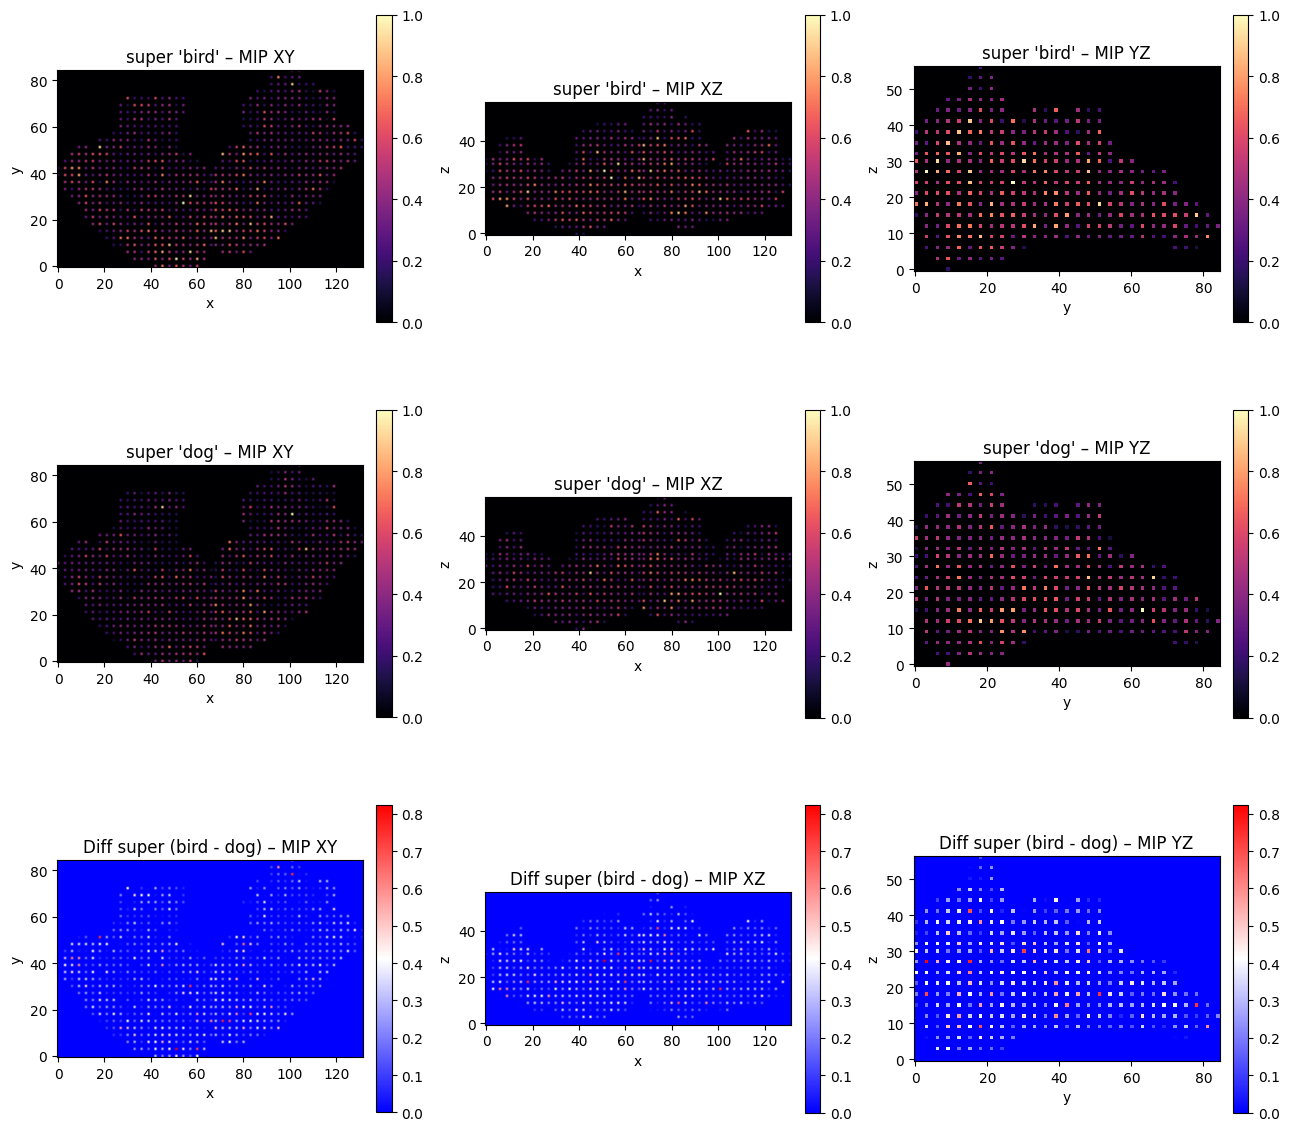

In [ ]:


device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# ============================
# 0) Setup base: modello, encoder superclassi, dog/bird
# ============================

model_sup = model_super.to(device)   # modello per le superclassi
model_sup.eval()

n_roi   = X_train_excl_norm.shape[1]
n_voxel = X_train_excl_norm.shape[2]
print("n_roi:", n_roi, "   n_voxel:", n_voxel)

# nomi EXACT delle superclassi nel super_encoder (controlla super_encoder.classes_)
sup_bird = "Bird"
sup_dog  = "Dogs"

idx_sup_bird = super_encoder.transform([sup_bird])[0]
idx_sup_dog  = super_encoder.transform([sup_dog])[0]
print("idx_sup_bird:", idx_sup_bird, " idx_sup_dog:", idx_sup_dog)

sup_loader = train_loader_super_excl


# ============================
# 1) Funzione riusata: importanza voxel per UNA superclass
# ============================

def compute_superclass_voxel_importance(model, data_loader, class_idx):
    model.eval()
    voxel_sum = torch.zeros(n_voxel, device=device)
    count = 0

    for X_batch, y_batch in data_loader:
        X_batch = X_batch.to(device)   # (B, n_roi, n_voxel)
        y_batch = y_batch.to(device)   # (B,)

        mask = (y_batch == class_idx)
        if mask.sum() == 0:
            continue

        X = X_batch[mask]
        if X.size(0) == 0:
            continue

        X.requires_grad_(True)

        logits = model(X)                 # (B_cls, num_superclassi)
        logit_c = logits[:, class_idx].sum()

        model.zero_grad()
        if X.grad is not None:
            X.grad.zero_()

        logit_c.backward()
        grad = X.grad.detach()            # (B_cls, n_roi, n_voxel)
        grad_abs = grad.abs().mean(dim=1) # (B_cls, n_voxel)

        voxel_sum += grad_abs.sum(dim=0)
        count += X.size(0)

    if count == 0:
        print(f"ATTENZIONE: nessun campione per superclass_idx={class_idx}")
        return torch.zeros(n_voxel)

    return (voxel_sum / count).cpu().numpy()


# ============================
# 2) Calcolo mappe per superclass bird e dog
# ============================

print("Calcolo voxel_importance_flat_bird_super ...")
voxel_importance_flat_bird_super = compute_superclass_voxel_importance(
    model_sup, sup_loader, class_idx=idx_sup_bird
)

print("Calcolo voxel_importance_flat_dog_super ...")
voxel_importance_flat_dog_super = compute_superclass_voxel_importance(
    model_sup, sup_loader, class_idx=idx_sup_dog
)


# ============================
# 3) Volume 3D e confronto bird vs dog (superclass)
# ============================

coords_path = os.path.join(DATA_DIR, "data/voxel_coords.npz")
coords = np.load(coords_path)

x = coords["x"].astype(int)
y = coords["y"].astype(int)
z = coords["z"].astype(int)

num_vox = x.shape[0]
print("num_vox:", num_vox)

x_min, x_max = x.min(), x.max()
y_min, y_max = y.min(), y.max()
z_min, z_max = z.min(), z.max()

brain_shape = (
    int(x_max - x_min + 1),
    int(y_max - y_min + 1),
    int(z_max - z_min + 1),
)
print("brain_shape:", brain_shape)

def build_importance_volume(voxel_importance_flat):
    vol = np.zeros(brain_shape, dtype=np.float32)
    assert voxel_importance_flat.shape[0] == num_vox
    for j in range(num_vox):
        xi = int(x[j] - x_min)
        yi = int(y[j] - y_min)
        zi = int(z[j] - z_min)
        vol[xi, yi, zi] = voxel_importance_flat[j]
    return vol

vol_bird_super = build_importance_volume(voxel_importance_flat_bird_super)
vol_dog_super  = build_importance_volume(voxel_importance_flat_dog_super)

def normalize_volume(v):
    vmax = v.max()
    if vmax <= 0:
        return np.zeros_like(v)
    return v / vmax

vol_bird_super_norm = normalize_volume(vol_bird_super)
vol_dog_super_norm  = normalize_volume(vol_dog_super)

vol_diff_super = vol_bird_super_norm - vol_dog_super_norm   # >0 bird, <0 dog

def compute_mips(volume):
    mip_xy = volume.max(axis=2)
    mip_xz = volume.max(axis=1)
    mip_yz = volume.max(axis=0)
    return mip_xy, mip_xz, mip_yz

mip_xy_bird_s, mip_xz_bird_s, mip_yz_bird_s = compute_mips(vol_bird_super_norm)
mip_xy_dog_s,  mip_xz_dog_s,  mip_yz_dog_s  = compute_mips(vol_dog_super_norm)
mip_xy_diff_s, mip_xz_diff_s, mip_yz_diff_s = compute_mips(vol_diff_super)

fig, axs = plt.subplots(3, 3, figsize=(13, 12))

# bird (superclass)
im0 = axs[0, 0].imshow(mip_xy_bird_s.T, origin="lower", cmap="magma")
axs[0, 0].set_title("super 'bird' – MIP XY"); axs[0, 0].set_xlabel("x"); axs[0, 0].set_ylabel("y")
plt.colorbar(im0, ax=axs[0, 0], fraction=0.046, pad=0.04)

im1 = axs[0, 1].imshow(mip_xz_bird_s.T, origin="lower", cmap="magma")
axs[0, 1].set_title("super 'bird' – MIP XZ"); axs[0, 1].set_xlabel("x"); axs[0, 1].set_ylabel("z")
plt.colorbar(im1, ax=axs[0, 1], fraction=0.046, pad=0.04)

im2 = axs[0, 2].imshow(mip_yz_bird_s.T, origin="lower", cmap="magma")
axs[0, 2].set_title("super 'bird' – MIP YZ"); axs[0, 2].set_xlabel("y"); axs[0, 2].set_ylabel("z")
plt.colorbar(im2, ax=axs[0, 2], fraction=0.046, pad=0.04)

# dog (superclass)
im3 = axs[1, 0].imshow(mip_xy_dog_s.T, origin="lower", cmap="magma")
axs[1, 0].set_title("super 'dog' – MIP XY"); axs[1, 0].set_xlabel("x"); axs[1, 0].set_ylabel("y")
plt.colorbar(im3, ax=axs[1, 0], fraction=0.046, pad=0.04)

im4 = axs[1, 1].imshow(mip_xz_dog_s.T, origin="lower", cmap="magma")
axs[1, 1].set_title("super 'dog' – MIP XZ"); axs[1, 1].set_xlabel("x"); axs[1, 1].set_ylabel("z")
plt.colorbar(im4, ax=axs[1, 1], fraction=0.046, pad=0.04)

im5 = axs[1, 2].imshow(mip_yz_dog_s.T, origin="lower", cmap="magma")
axs[1, 2].set_title("super 'dog' – MIP YZ"); axs[1, 2].set_xlabel("y"); axs[1, 2].set_ylabel("z")
plt.colorbar(im5, ax=axs[1, 2], fraction=0.046, pad=0.04)

# differenza bird - dog (superclass)
im6 = axs[2, 0].imshow(mip_xy_diff_s.T, origin="lower", cmap="bwr")
axs[2, 0].set_title("Diff super (bird - dog) – MIP XY"); axs[2, 0].set_xlabel("x"); axs[2, 0].set_ylabel("y")
plt.colorbar(im6, ax=axs[2, 0], fraction=0.046, pad=0.04)

im7 = axs[2, 1].imshow(mip_xz_diff_s.T, origin="lower", cmap="bwr")
axs[2, 1].set_title("Diff super (bird - dog) – MIP XZ"); axs[2, 1].set_xlabel("x"); axs[2, 1].set_ylabel("z")
plt.colorbar(im7, ax=axs[2, 1], fraction=0.046, pad=0.04)

im8 = axs[2, 2].imshow(mip_yz_diff_s.T, origin="lower", cmap="bwr")
axs[2, 2].set_title("Diff super (bird - dog) – MIP YZ"); axs[2, 2].set_xlabel("y"); axs[2, 2].set_ylabel("z")
plt.colorbar(im8, ax=axs[2, 2], fraction=0.046, pad=0.04)

plt.tight_layout()
plt.show()
